In [7]:
!find /content/drive -name "*.ipynb"

/content/drive/MyDrive/Colab Notebooks/Untitled0.ipynb
/content/drive/MyDrive/Colab Notebooks/PreprocessInspect (4).ipynb
/content/drive/MyDrive/Colab Notebooks/PreprocessInspect (3).ipynb
/content/drive/MyDrive/Colab Notebooks/PreprocessInspect (2).ipynb
/content/drive/MyDrive/Colab Notebooks/PreprocessInspect (1).ipynb
/content/drive/MyDrive/Colab Notebooks/PreprocessInspect.ipynb
/content/drive/MyDrive/Colab Notebooks/BC_PSO_ANN_Colab_Notebook (3).ipynb
/content/drive/MyDrive/Colab Notebooks/JHK-ZAW-MITHILPATEL-OCT-026-025 - Code (1).ipynb
/content/drive/MyDrive/Colab Notebooks/BC_PSO_ANN_Colab_Notebook (2).ipynb
/content/drive/MyDrive/Colab Notebooks/BC_PSO_ANN_Colab_Notebook (1).ipynb
/content/drive/MyDrive/Colab Notebooks/JHK-ZAW-MITHILPATEL-OCT-026-025 - Code.ipynb
/content/drive/MyDrive/Colab Notebooks/BC_PSO_ANN_Colab_Notebook.ipynb
/content/drive/MyDrive/Colab Notebooks/BC_PSO_ANN_FIXED.ipynb
/content/drive/MyDrive/Colab Notebooks/Untitled1.ipynb
/content/drive/MyDrive/Colab 

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer

# Task 1: Data Exploration and Visualization:

## Read the Data

In [ ]:
train_data = pd.read_csv("/content/drive/MyDrive/train/train.csv")

## Distribution of Ratings

Class Imbalance: 1 star reviews and 4 star reviews heavily outnumbered 2, 3 and 5 star reviews which basically shows that the dataset is imbalance. We can deduce that users most likely leave a review when they are either happy (4) or very angry (1)


--- Basic Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 288000 entries, 0 to 287999
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    288000 non-null  object
 1   rating  288000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 4.4+ MB
None

--- First 5 Rows ---


,text,rating
0,This place is TERRIBLE; the people in charge a...,2
1,Terrible Service! And they are saying that I n...,1
2,Absolutely terrible company. They sent me to ...,1
3,"To find it, either park in front of the Tuesda...",4
4,Mall location. Used their services for sedan. ...,4



--- Missing Values ---
text      0
rating    0
dtype: int64


/tmp/ipykernel_9255/1002601497.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_data, x='rating', palette='viridis')


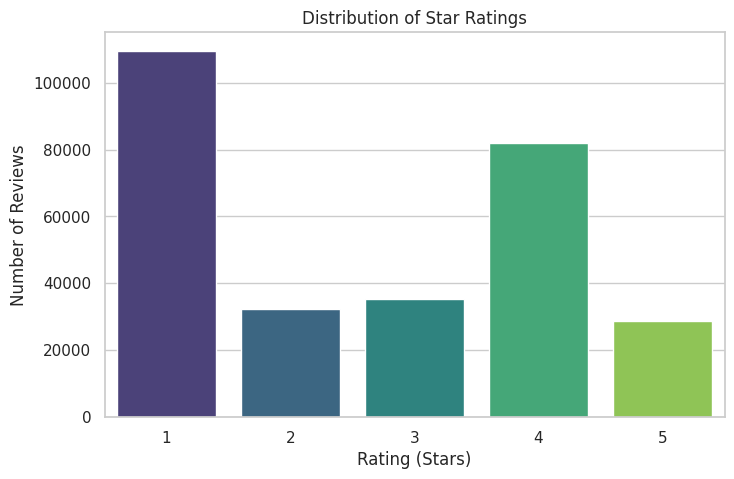

Counts for each star rating:
rating
1    109583
2     32218
3     35326
4     82073
5     28800
Name: count, dtype: int64


In [ ]:
# A count of how many 1-star, 2-star, 3-star, 4-star, and 5-star reviews exist in the dataset.

sns.set_theme(style="whitegrid")
print("\n--- Basic Information ---")
print(train_data.info())

print("\n--- First 5 Rows ---")
display(train_data.head())

print("\n--- Missing Values ---")
print(train_data.isnull().sum())

plt.figure(figsize=(8, 5))
sns.countplot(data=train_data, x='rating', palette='viridis')
plt.title('Distribution of Star Ratings')
plt.xlabel('Rating (Stars)')
plt.ylabel('Number of Reviews')
plt.show()

rating_counts = train_data['rating'].value_counts().sort_index()
print("Counts for each star rating:")
print(rating_counts)

## Review Length Distribution

It tells us how verbose users are. Most reviews are probably quite short (e.g., 10 to 50 words), but there is a long tail of very lengthy reviews. The histogram shows a strong right-skewed distribution. This means the vast majority of users leave quick, short feedback (between 10 and 50 words), but there is a small minority of very verbose users who write incredibly detailed reviews (up to 1,500+ words).

>> 75% of the reviews are 72 words or shorter.

>> The absolute longest review in the dataset is a massive 1,533 words

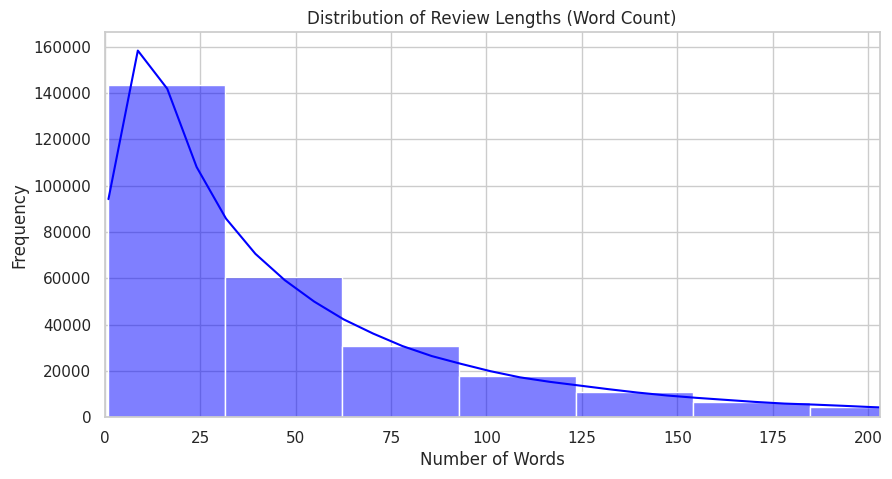


--- Summary Statistics of Review Lengths ---
count    288000.000000
mean         58.695444
std          80.353889
min           1.000000
25%          12.000000
50%          32.000000
75%          72.000000
max        1533.000000
Name: review_length, dtype: float64


In [ ]:
# A graph showing the frequency of different word counts.
# Create a new feature: 'review_length' which is basically number of words in a review
train_data['review_length'] = train_data['text'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 5))
sns.histplot(train_data['review_length'], bins=50, kde=True, color='blue')
plt.title('Distribution of Review Lengths (Word Count)')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
# Limit x-axis to 95th percentile to ignore extreme outliers for a cleaner plot
plt.xlim(0, train_data['review_length'].quantile(0.95))
plt.show()

# Summary Statistics for Report
print("\n--- Summary Statistics of Review Lengths ---")
print(train_data['review_length'].describe())


## Review Length vs. Rating

1. Look at the green box for 1-star reviews. It has the highest median line and  the tallest box whichbasically shows that unhappy customers write significantly longer and more detailed reviews. When people have a terrible experience, they want to vent, explain exactly what went wrong, and justify their bad rating.

2. Look at the purple (4-star) and orange (5-star) boxes. They are squished down low with very short medians which shows that happy customers keep it short and sweet. If someone has a standard good experience, they are more likely to just drop a quick "Great service, loved the food!" and move on. Notice that 4-star reviews are actually the shortest overall.

/tmp/ipykernel_9255/1588702269.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_data, x='rating', y='review_length', palette='Set2')


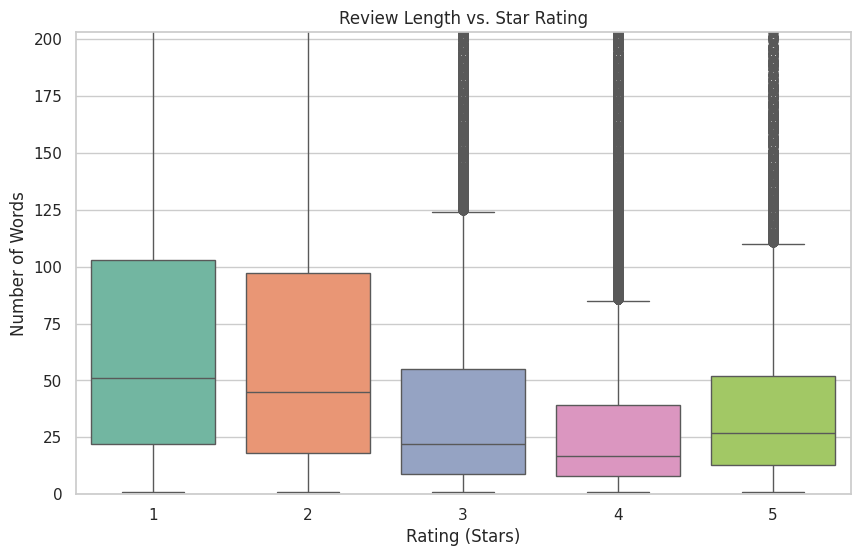

In [ ]:
# Compares the median and spread of word counts across each of the 5 rating categories.

plt.figure(figsize=(10, 6))
sns.boxplot(data=train_data, x='rating', y='review_length', palette='Set2')
plt.title('Review Length vs. Star Rating')
plt.xlabel('Rating (Stars)')
plt.ylabel('Number of Words')
# Limit y-axis to see the boxes clearly
plt.ylim(0, train_data['review_length'].quantile(0.95))
plt.show()

##  Lexical Intensity

The style of writing changes depending on the user's rating.
> The first graph shows that 1-star reviews average over 1.5 ALL CAPS words per review, while 3, 4, and 5-star reviews barely use them at all (averaging around 0.2 to 0.3).

Insight -> People use ALL CAPS to simulate shouting. This visual proves that intense negative emotion (1-star) drives people to shout their complaints. If a user is leaving a 4 or 5-star review, they are generally satisfied and do not feel the need to use capitalized emphasis.

> The second graph shows that the usage of exclamation marks peaks at the two extremes: 1-star reviews (0.95 marks per review) and 5-star reviews (0.90 marks per review). The 3-star reviews sit at the very bottm(0.2).

Insight -> Exclamation marks represent high emotional intensity, but unlike ALL CAPS, they are not all negative. 1 star is anger, 5 star is happiness/excitement.

/tmp/ipykernel_9255/4036468541.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=train_data, x='rating', y='caps_count', ax=ax[0], palette='Reds')
/tmp/ipykernel_9255/4036468541.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=train_data, x='rating', y='exclamation_count', ax=ax[1], palette='Blues')


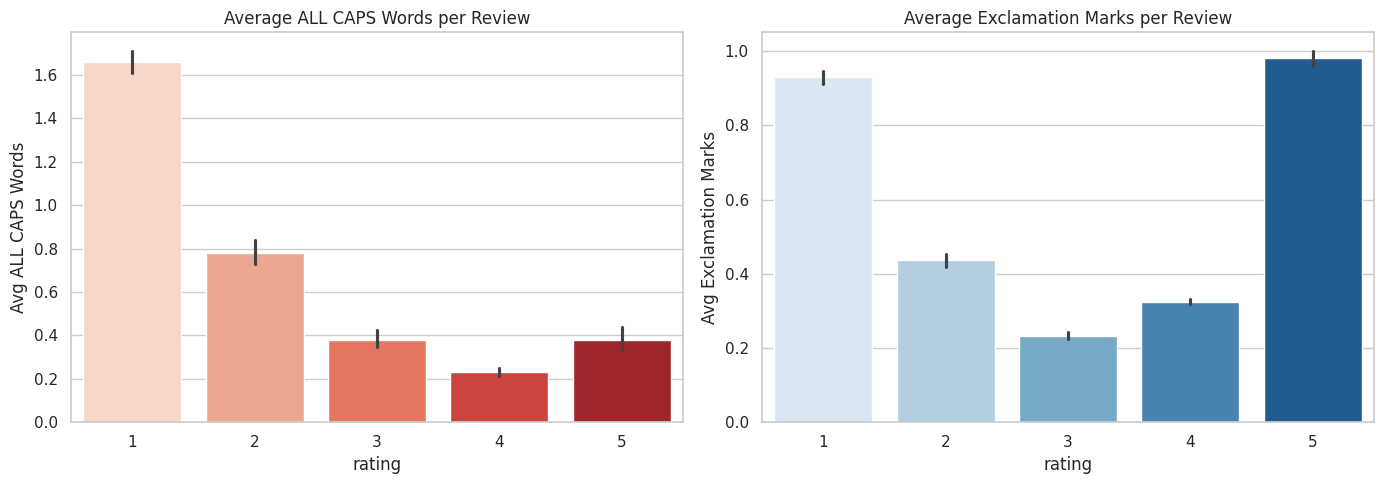

In [ ]:
# Count exclamation marks
train_data['exclamation_count'] = train_data['text'].apply(lambda x: str(x).count('!'))

# Count ALL CAPS words (longer than 1 character to avoid 'I' or 'A')
def count_all_caps(text):
    words = str(text).split()
    return sum(1 for w in words if w.isupper() and len(w) > 1)

train_data['caps_count'] = train_data['text'].apply(count_all_caps)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=train_data, x='rating', y='caps_count', ax=ax[0], palette='Reds')
ax[0].set_title('Average ALL CAPS Words per Review')
ax[0].set_ylabel('Avg ALL CAPS Words')

sns.barplot(data=train_data, x='rating', y='exclamation_count', ax=ax[1], palette='Blues')
ax[1].set_title('Average Exclamation Marks per Review')
ax[1].set_ylabel('Avg Exclamation Marks')

plt.tight_layout()
plt.show()

The below two visualisations are almost same. The second one is better as it is a comparison of bigrams and unigrams.

## Top Bigrams (1-star vs 5-star)

HOW TO READ:
A bigram is simply a sequence of two consecutive words. Standard stop words (like "the", "and", "is") have been filtered out, leaving only the most meaningful pairs.

The X-Axis (Count): This represents the absolute frequency of how many times that specific two-word phrase appeared in the sampled reviews.

INSIGHTS:
1. Look at the most prominent bigram across both charts: **customer service**. It is the number one phrase in 1-star reviews and the number two phrase in 5-star reviews. On its own, the phrase "customer service" contains zero sentiment. Whether it is positive or negative depends entirely on the surrounding context (notice the surrounding bigrams like "worst customer", "terrible customer", vs. "great customer", "excellent customer").

> **This perfectly dshows why a simple unigram (single word) Bag-of-Words model might struggle. If a model only looks at individual words, the word "service" won't help it decide between a 1 or a 5. This is our statistical proof for why we must experiment with n-gram features in Step 3 and sequence models in Step 5 that understand word order.**

2. 5-star reviews are dominated by strong words ("highly recommend", "great job", "definitely recommend") whereas, 1-star reviews are dominated by literal warnings ("waste time", "stay away", "save money").

> These polarized bigrams will be the strongest predictive features for our machine learning models. A TF-IDF vectorizer will naturally assign high weights to these specific phrases because they are highly distinctive to their respective classes.

3. Notice the bigram **translated google** sitting awkwardly in the top 5 for both graphs. Because this dataset is derived from real-world Google Maps user reviews, it includes auto-generated system text like "(Translated by Google)". This phrase has absolutely nothing to do with the user's actual sentiment.

> This is a huge for Step 2 (Text Processing and Normalization). We can state in our report that our EDA uncovered platform-specific noise, prompting you to add **"translated" and "google" to a custom stop-word list** to prevent the model from learning irrelevant patterns

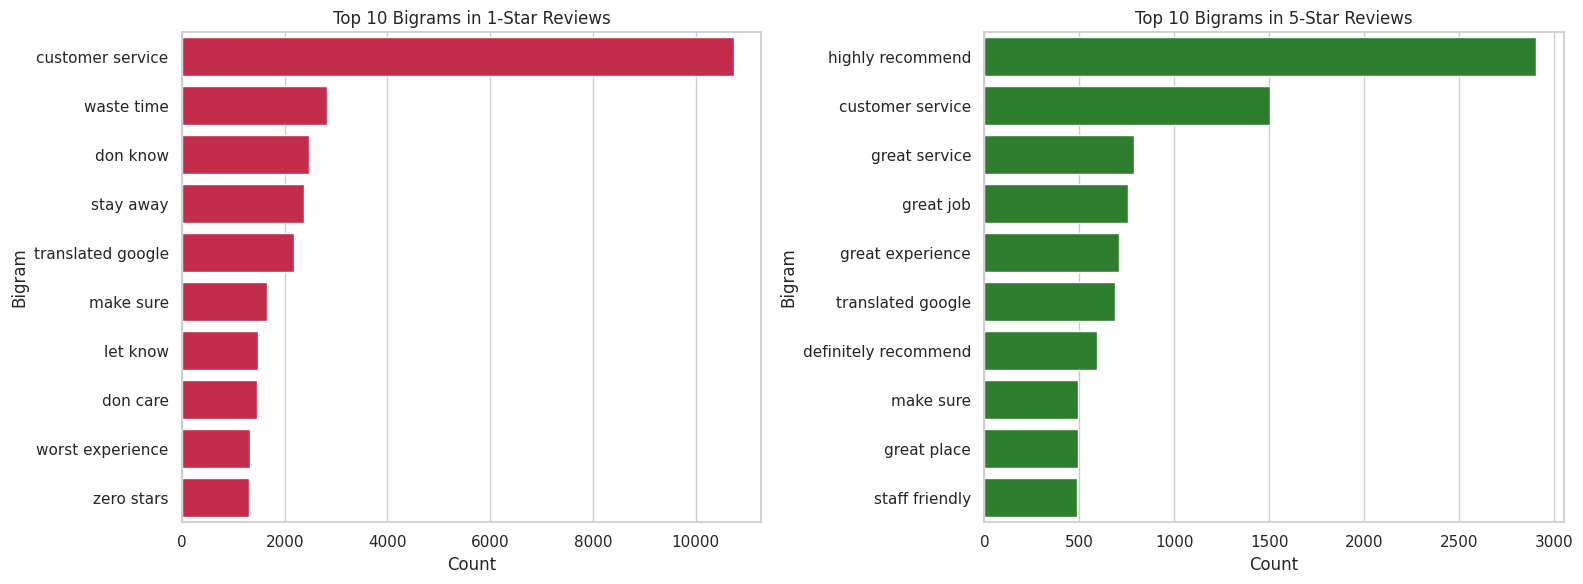

In [ ]:
def plot_top_ngrams(text_series, title, ax, color):
    # Use CountVectorizer to extract bigrams, removing english stopwords
    vec = CountVectorizer(ngram_range=(2, 2), stop_words='english', max_features=10).fit(text_series.dropna())
    bag_of_words = vec.transform(text_series.dropna())
    sum_words = bag_of_words.sum(axis=0)

    # Sort and grab top 10
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)

    df_ngram = pd.DataFrame(words_freq, columns=['Bigram', 'Count'])
    sns.barplot(x='Count', y='Bigram', data=df_ngram, ax=ax, color=color)
    ax.set_title(title)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Plot for 1-star reviews
plot_top_ngrams(train_data[train_data['rating'] == 1]['text'], 'Top 10 Bigrams in 1-Star Reviews', ax[0], 'crimson')

# Plot for 5-star reviews
plot_top_ngrams(train_data[train_data['rating'] == 5]['text'], 'Top 10 Bigrams in 5-Star Reviews', ax[1], 'forestgreen')

plt.tight_layout()
plt.show()

## Unigram Vs. Bigram Comparison


1. Look at the unigram charts. The words "time", "service", and "place" appear in the top 10 for both 1-star and 5-star reviews

> Insight: Unigrams often capture the topic of the review but completely lose the sentiment. If a basic Bag-of-Words model sees the word "place," it has no mathematical way to know if the user liked the place or hated it.

This is our justification for Step 3. Visualizing unigrams revealed that key terms like 'service' and 'time' are shared across extreme polarities. This proves that unigram frequency alone is ambiguous, strongly justifying our decision to experiment with n-gram representations to capture necessary context.

2. In the 1-star unigram chart, you see isolated helper verbs like "don" (from don't) and "didn" (from didn't).

> Insight: A unigram model splits "didn't even" into "didn" and "even." This destroys the negation. When you look at the 1-star bigram chart, those words are reconnected into meaningful phrases like "don know", "didn even", and "don waste". Bigrams preserve the negative context that unigrams destroy.

3. Compare the most frequent bigrams in both categories.

> 5-star reviews are characterized by strong, multi-word endorsements ("highly recommend", "great job", "definitely recommend"). Conversely, 1-star reviews are characterized by explicit warnings ("waste time", "stay away", "save money").

4. The bigram "translated google" appears in the top 5 for both 1-star and 5-star reviews.

> Insight: Because this dataset is derived from Google Maps user reviews, it includes automated system text like "(Translated by Google)". This phrase has zero predictive value for the star rating. **This insight directly informed our text normalization strategy, prompting us to add these terms to a custom stop-word list to prevent the model from learning irrelevant noise**

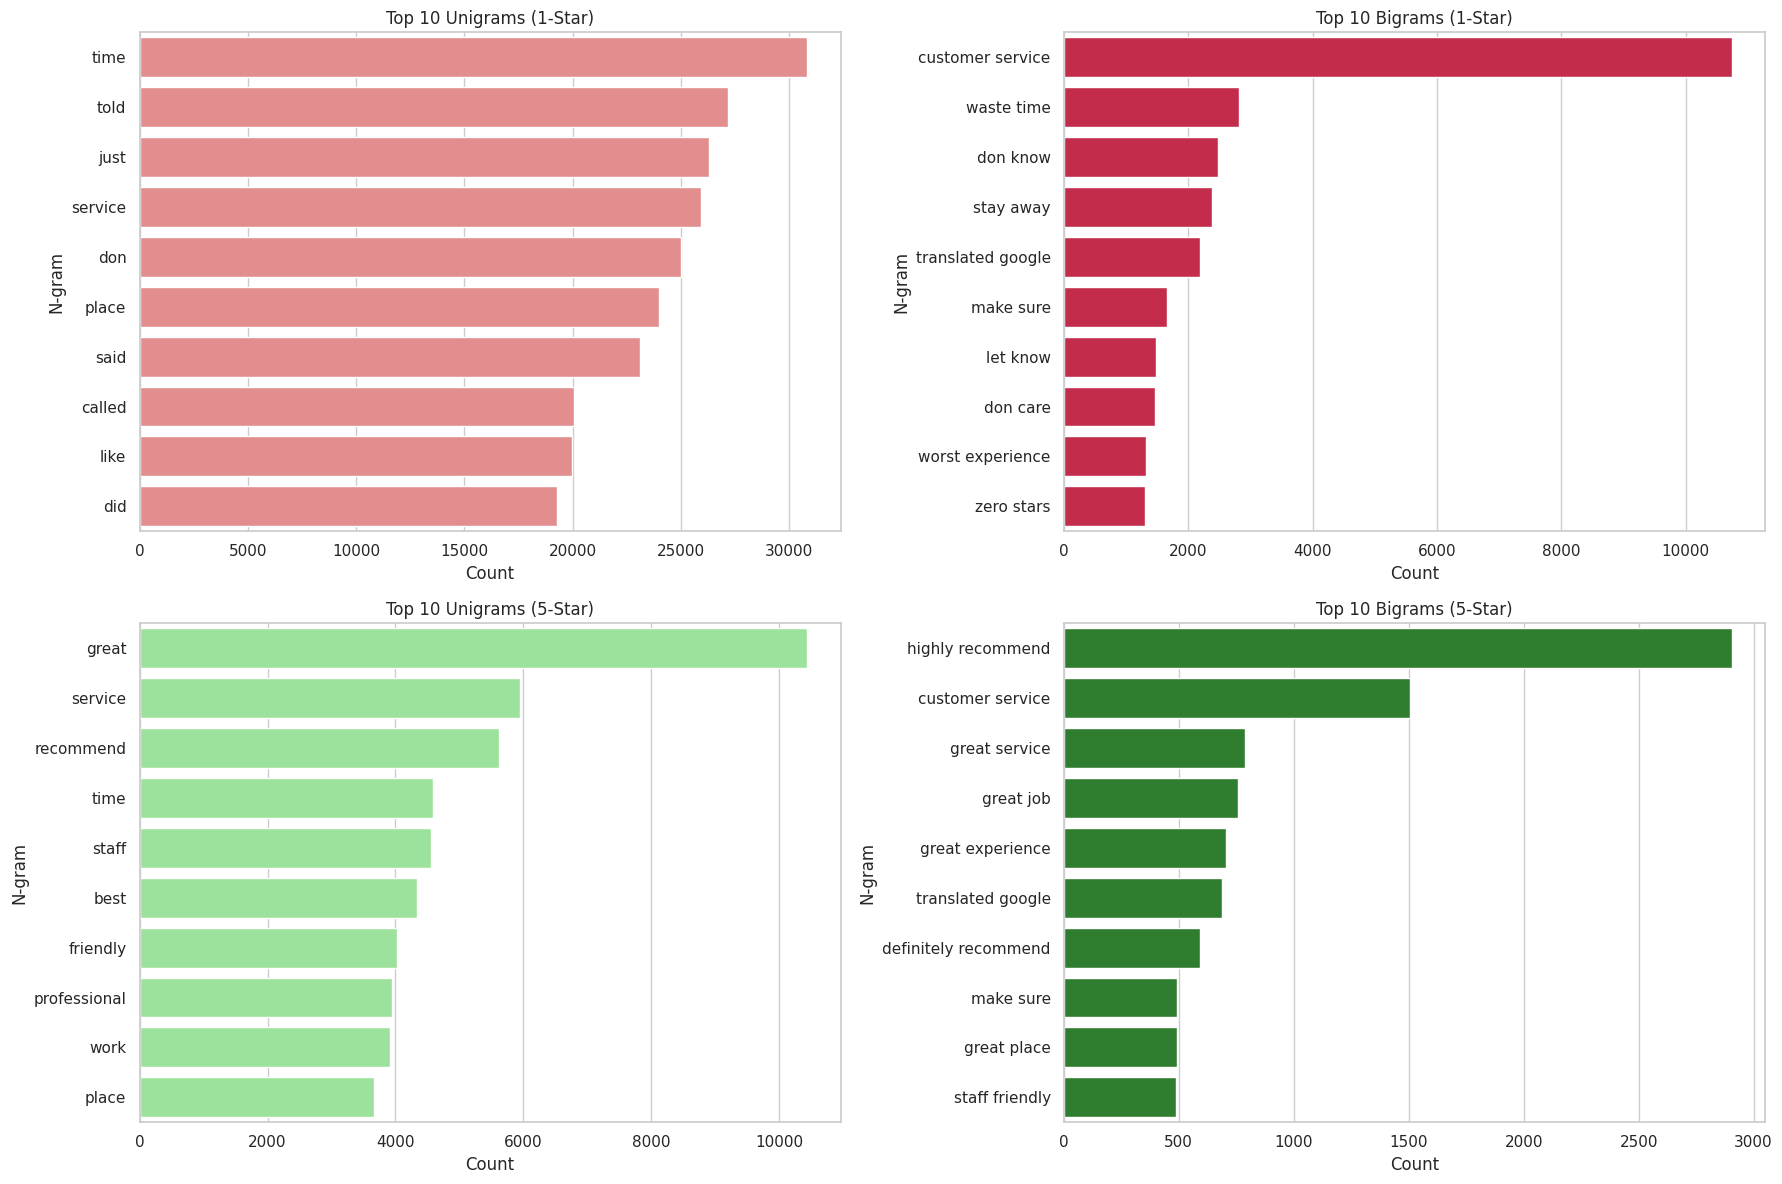

In [ ]:
def plot_top_ngrams(text_series, n, title, ax, color):
    # Extract n-grams, removing english stopwords
    vec = CountVectorizer(ngram_range=(n, n), stop_words='english', max_features=10).fit(text_series.dropna())
    bag_of_words = vec.transform(text_series.dropna())
    sum_words = bag_of_words.sum(axis=0)

    # Sort and grab top 10
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)

    df_ngram = pd.DataFrame(words_freq, columns=['N-gram', 'Count'])
    sns.barplot(x='Count', y='N-gram', data=df_ngram, ax=ax, color=color)
    ax.set_title(title)

# Set up a 2x2 grid
fig, ax = plt.subplots(2, 2, figsize=(18, 12))

# --- Row 1: 1-Star Reviews ---
# Unigrams
plot_top_ngrams(train_data[train_data['rating'] == 1]['text'], 1, 'Top 10 Unigrams (1-Star)', ax[0, 0], 'lightcoral')
# Bigrams
plot_top_ngrams(train_data[train_data['rating'] == 1]['text'], 2, 'Top 10 Bigrams (1-Star)', ax[0, 1], 'crimson')

# --- Row 2: 5-Star Reviews ---
# Unigrams
plot_top_ngrams(train_data[train_data['rating'] == 5]['text'], 1, 'Top 10 Unigrams (5-Star)', ax[1, 0], 'lightgreen')
# Bigrams
plot_top_ngrams(train_data[train_data['rating'] == 5]['text'], 2, 'Top 10 Bigrams (5-Star)', ax[1, 1], 'forestgreen')

plt.tight_layout()
plt.show()

In [ ]:
import re
import string
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.base import BaseEstimator, TransformerMixin

import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer

nltk.download("punkt")
nltk.download("wordnet")


# Task 2: Text Processing and Normalization
Many text processing techniques were evaluated to determine their effect on the performance.

- Lowercasing reduces vocabulary size but removes emphasis like with all caps. It showed minimal improvement

- Noise removal (words like “translated" and "google") eliminates irrelevant platform text. It had little direct impact but improves data quality

- Stopword removal reduced performance, as it removes important context and weakens sentiment expressions, even when negation is preserved

- Stemming reduces word forms but produces unnatural tokens, offering only minor improvement

- Lemmatization gave the best results by reducing vocabulary while preserving meaning

- Bigrams increased performance by capturing sentiment phrases (like- “highly recommend”, “waste time”)

- Style features (like all caps and exclamations) had small impact compared to others


Finally, lemmatization with unigram + bigram features provides the best balance between normalization and information preservation.

In [ ]:
train_df = pd.read_csv("train.csv")


train_df = train_df[["text", "rating"]].dropna()
train_df["text"] = train_df["text"].astype(str)

X = train_df["text"]
y = train_df["rating"]

print("Train shape:", train_df.shape)


CUSTOM_STOPWORDS = set(ENGLISH_STOP_WORDS) - {
    "no", "not", "nor", "never"
}



def remove_noise(text):
    text = re.sub(r"\(translated by google\)", " ", text, flags=re.I)
    text = re.sub(r"translated by google", " ", text, flags=re.I)
    text = re.sub(r"\bgoogle\b", " ", text, flags=re.I)
    text = re.sub(r"\btranslated\b", " ", text, flags=re.I)
    return text



stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

class TextPreprocessor(BaseEstimator, TransformerMixin):

    def __init__(self,lowercase=False,remove_noise=False,remove_punct=False,stopwords=False,stemming=False,lemmatize=False):

        self.lowercase = lowercase
        self.remove_noise = remove_noise
        self.remove_punct = remove_punct
        self.stopwords = stopwords
        self.stemming = stemming
        self.lemmatize = lemmatize

    def fit(self, X, y=None):
        return self

    def transform(self, X):

        processed = []

        for text in X:

            if self.remove_noise:
                text = remove_noise(text)

            if self.lowercase:
                text = text.lower()

            if self.remove_punct:
                text = text.translate(str.maketrans('', '', string.punctuation))

            tokens = word_tokenize(text)

            if self.stopwords:
                tokens = [t for t in tokens if t not in CUSTOM_STOPWORDS]

            if self.stemming:
                tokens = [stemmer.stem(t) for t in tokens]

            if self.lemmatize:
                tokens = [lemmatizer.lemmatize(t) for t in tokens]

            processed.append(" ".join(tokens))

        return processed


class StyleFeatures(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        return self

    def transform(self, X):

        features = []

        for text in X:

            words = re.findall(r"\b\w+\b", text)

            review_len = len(words)
            exclamations = text.count("!")
            caps = sum(1 for w in words if w.isupper() and len(w) > 1)

            features.append([review_len, exclamations, caps])

        return np.array(features)


def pipeline(preprocessor, ngram=(1,1), style_features=False):

    tfidf = Pipeline([
        ("prep", preprocessor),
        ("tfidf", TfidfVectorizer(
            ngram_range=ngram,
            min_df=3,
            max_features=40000,
            sublinear_tf=True
        ))
    ])

    if style_features:

        features = FeatureUnion([
            ("text", tfidf),
            ("style", StyleFeatures())
        ])

    else:
        features = tfidf

    model = Pipeline([
        ("features", features),
        ("clf", LogisticRegression(max_iter=2000, multi_class="multinomial"))
    ])

    return model



text_processing_experiments = {

    "Minimal_Unigram":
        pipeline(TextPreprocessor(), (1,1)),

    "Lowercase_Unigram":
        pipeline(TextPreprocessor(lowercase=True), (1,1)),

    "NoiseRemoval_Unigram":
        pipeline(TextPreprocessor(lowercase=True, remove_noise=True), (1,1)),

    "Unigram_Bigram":
        pipeline(TextPreprocessor(lowercase=True, remove_noise=True), (1,2)),

    "Stopword_Removal":
        pipeline(TextPreprocessor(lowercase=True, remove_noise=True, stopwords=True), (1,2)),

    "Stemming":
        pipeline(TextPreprocessor(lowercase=True, remove_noise=True, stemming=True), (1,2)),

    "Lemmatization":
        pipeline(TextPreprocessor(lowercase=True, remove_noise=True, lemmatize=True), (1,2)),

    "With_Style_Features":
        pipeline(TextPreprocessor(remove_noise=True), (1,2), style_features=True)
}


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

r = []

for name, pipe in text_processing_experiments.items():

    print("Running:", name)

    scores = cross_val_score(
        pipe,
        X,
        y,
        cv=cv,
        scoring="f1_macro",
        n_jobs=-1
    )

    r.append({
        "pipeline": name,
        "mean_f1": scores.mean(),
        "std": scores.std()
    })

r_df = pd.DataFrame(r).sort_values("mean_f1", ascending=False)

print("\nPreprocessing Experiment Results:")
print(r_df)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Shaji\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Shaji\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Train shape: (288000, 2)
Running: Minimal_Unigram
Running: Lowercase_Unigram
Running: NoiseRemoval_Unigram
Running: Unigram_Bigram
Running: Stopword_Removal
Running: Stemming
Running: Lemmatization
Running: With_Style_Features

=== PREPROCESSING RESULTS ===
               pipeline   mean_f1       std
6         Lemmatization  0.533110  0.000898
5              Stemming  0.532881  0.001113
3        Unigram_Bigram  0.532795  0.001299
0       Minimal_Unigram  0.512213  0.001747
2  NoiseRemoval_Unigram  0.511812  0.002246
1     Lowercase_Unigram  0.511732  0.001897
4      Stopword_Removal  0.506204  0.001637
7   With_Style_Features  0.500745  0.020521


Below is the pipline based on the best performing methods from the above testing.
It consisits of:
- noise removal
- lowercasing and normalization
- tokenization
- lemmatization
- negation preservation
- TF-IDF with unigrams and bigrams

In [ ]:
nltk.download("omw-1.4")

train_df = pd.read_csv("train.csv")



train_df = train_df[["text", "rating"]].dropna().copy()
train_df["text"] = train_df["text"].astype(str)
train_df = train_df[train_df["text"].str.strip() != ""].reset_index(drop=True)

X = train_df["text"]
y = train_df["rating"]

print("Train shape:", train_df.shape)


lemmatizer = WordNetLemmatizer()

def remove_noise(text: str) -> str:
    noise_patterns = [
        r"\(translated by google\)",
        r"translated by google",
        r"\(original\)",
        r"\boriginal\b",
        r"\btranslated\b",
        r"\bgoogle\b"
    ]
    for pattern in noise_patterns:
        text = re.sub(pattern, " ", text, flags=re.IGNORECASE)
    return text

def normalization(text: str) -> str:
    text = remove_noise(text)


    text = text.lower()


    text = re.sub(r"[^a-z0-9'\s]", " ", text)


    text = re.sub(r"\s+", " ", text).strip()

    return text

class FinalTextPreprocessor(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        return self

    def transform(self, X):

        processed = []

        for text in X:

            text = normalization(str(text))

            tokens = word_tokenize(text)

            clean_tokens = []

            for word in tokens:


                if word in ["'", "''", "``"]:
                    continue


                lemma = lemmatizer.lemmatize(word, pos="v")

                clean_tokens.append(lemma)

            processed.append(" ".join(clean_tokens))

        return processed


final_pipeline = Pipeline([
    ("preprocess", FinalTextPreprocessor()),
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=3,
        max_features=50000,
        sublinear_tf=True
    ))
])


X_processed = final_pipeline.fit_transform(X, y)

print("TF-IDF feature matrix shape:", X_processed.shape)



example_reviews = X.sample(5, random_state=42).tolist()
preprocessed_reviews = final_pipeline.named_steps["preprocess"].transform(example_reviews)

for i, (orig, proc) in enumerate(zip(example_reviews, preprocessed_reviews), start=1):
    print(f"\nReview {i}: Original")
    print(orig[:500])

    print(f"\nReview {i}: Processed")
    print(proc[:500])



train_df["processed_text"] = final_pipeline.named_steps["preprocess"].transform(X)
train_df.to_csv("train_preprocessed_step2.csv", index=False)

print("\nSaved preprocessed file as: train_preprocessed_step2.csv")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Shaji\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Shaji\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Shaji\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Train shape: (288000, 2)
TF-IDF feature matrix shape: (288000, 50000)

--- Review 1: ORIGINAL ---
Cheap haircut, friendly service

--- Review 1: PROCESSED ---
cheap haircut friendly service

--- Review 2: ORIGINAL ---
Dont Call she is one rude woman store has no time

--- Review 2: PROCESSED ---
dont call she be one rude woman store have no time

--- Review 3: ORIGINAL ---
There's a discount for disabled passengers, but only if you point to the sign saying so (driver point-blank denied its existence until then), and only if you hold a Californian disability card. If you're from outside California and you don't have one, you're SOL; the fact that you're hobbling along with a walker counts for absolutely nothing apparently.

--- Review 3: PROCESSED ---
there 's a discount for disable passengers but only if you point to the sign say so driver point blank deny its existence until then and only if you hold a californian disability card if you 're from outside california and you do n't have 

#Task 3: Vector space Model and feature representation:n

## Overview
In Step 3, we evaluate different feature representations to find the optimal way to convert text into numerical vectors for machine learning. The goal is to identify which vectorization method (Binary Count, TF-IDF, Character N-grams, Word Embeddings) best captures the sentiment information in product reviews.

## Methodology
We systematically evaluate:
- **Word-based representations**: Binary indicators, count-based, and TF-IDF with unigrams and bigrams
- **Character-level representations**: Character n-grams to capture spelling patterns and typos
- **Word embeddings**: Word2Vec to capture semantic relationships
- **Evaluation metric**: All Step 3 experiments were assessed with cross-validated Accuracy and Macro F1, and both metrics produced broadly consistent model rankings

#### 3.1 Word-Based Feature Representations

We evaluate 8 word representation settings, including:
- **Binary representations**: Simple presence/absence of words
- **Count-based**: Raw term frequencies
- **TF-IDF (basic)**: Standard TF-IDF without filtering
- **TF-IDF (filtered)**: With min_df and max_df filtering to remove rare/common terms
- **N-grams**: Testing unigrams vs. unigrams+bigrams/trigrams for capturing phrase sentiment

**Conclusion After experiment**: The best word representation was filtered word TF-IDF, with the 1-2 gram setting giving the strongest Macro F1 (0.5474) in the base comparison, while filtered 1-3 gram gave very similar performance.


In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline

# Load preprocessed training dataset
train_df = pd.read_csv("train_preprocessed_step2.csv")
train_df = train_df.dropna(subset=["processed_text", "rating"]).copy()
train_df["processed_text"] = train_df["processed_text"].astype(str)

X = train_df["processed_text"]
y = train_df["rating"]

print("Shape:", train_df.shape)

# Core word-based representations
representations = {
    "Binary Unigram": CountVectorizer(
        binary=True,
        max_features=20000
    ),

    "Binary Uni+Bi": CountVectorizer(
        binary=True,
        ngram_range=(1, 2),
        max_features=25000
    ),

    "Count Unigram": CountVectorizer(
        max_features=20000
    ),

    "Count Uni+Bi": CountVectorizer(
        ngram_range=(1, 2),
        max_features=25000
    ),

    "TFIDF Unigram": TfidfVectorizer(
        max_features=20000
    ),

    "TFIDF Uni+Bi": TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=25000
    ),

    "TFIDF Uni+Bi (Filtered)": TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=5,
        max_df=0.85,
        max_features=25000,
        sublinear_tf=True
    ),

    "TFIDF 1-3gram (Filtered)": TfidfVectorizer(
        ngram_range=(1, 3),
        min_df=5,
        max_df=0.85,
        max_features=30000,
        sublinear_tf=True
    )
}
# Cross validation setup
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Evaluate each representation
results = []

for name, vectorizer in representations.items():
    print(f"Running: {name}")

    pipeline = Pipeline([
        ("vectorizer", vectorizer),
        ("clf", LogisticRegression(
            max_iter=3000,
            C=1.5,
            class_weight="balanced",
            solver="lbfgs"
        ))
    ])

    scores = cross_validate(
        pipeline,
        X,
        y,
        cv=cv,
        scoring=["accuracy", "f1_macro"],
        n_jobs=-1
    )

    results.append({
        "Representation": name,
        "Mean_Accuracy": scores["test_accuracy"].mean(),
        "Std_Accuracy": scores["test_accuracy"].std(),
        "Mean_F1_Macro": scores["test_f1_macro"].mean(),
        "Std_F1": scores["test_f1_macro"].std()
    })

results_df = pd.DataFrame(results).sort_values(
    by="Mean_F1_Macro",
    ascending=False
)

print("\n=== Core Word-Based Representation Results ===")
print(results_df)

Shape: (287968, 3)
Running: Binary Unigram
Running: Binary Uni+Bi
Running: Count Unigram
Running: Count Uni+Bi
Running: TFIDF Unigram
Running: TFIDF Uni+Bi
Running: TFIDF Uni+Bi (Filtered)
Running: TFIDF 1-3gram (Filtered)

=== Core Word-Based Representation Results ===
             Representation  Mean_Accuracy  Std_Accuracy  Mean_F1_Macro  \
6   TFIDF Uni+Bi (Filtered)       0.606102      0.001521       0.547448   
7  TFIDF 1-3gram (Filtered)       0.606543      0.001544       0.547233   
5              TFIDF Uni+Bi       0.605668      0.001506       0.547197   
4             TFIDF Unigram       0.590389      0.001735       0.534179   
0            Binary Unigram       0.576574      0.001411       0.518620   
2             Count Unigram       0.575887      0.000771       0.517820   
1             Binary Uni+Bi       0.575724      0.001011       0.515147   
3              Count Uni+Bi       0.573678      0.000775       0.513025   

     Std_F1  
6  0.001820  
7  0.001566  
5  0.001482

#### 3.2 Character-Level TF-IDF Representation

Character n-grams capture spelling patterns, typos, and stylistic features that word-level features might miss. This is particularly useful for product reviews that may contain misspellings or informal language.

**Configuration**:
- Analyzer: word boundaries with character 3-5 grams
- Min document frequency: 5 (to avoid rare character patterns)
- Max features: 15,000 (max_features was kept at 15,000 for char TF-IDF because character n-grams create a much larger feature space than word features.)

**Conclusion after experiment**: Char TF-IDF performed competitively with Accuracy = 0.5949 and Macro F1 = 0.5404, so it captured useful local spelling/style patterns, but it still remained slightly below the best word-based TF-IDF models.


In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline

train_df = pd.read_csv("train_preprocessed_step2.csv")
train_df = train_df.dropna(subset=["processed_text", "rating"]).copy()
train_df["processed_text"] = train_df["processed_text"].astype(str)

X = train_df["processed_text"]
y = train_df["rating"]

char_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        analyzer="char_wb",
        ngram_range=(3, 5),
        min_df=5,
        max_features=15000,
        sublinear_tf=True
    )),
    ("clf", LogisticRegression(
        max_iter=3000,
        C=1.5,
        class_weight="balanced",
        solver="lbfgs"
    ))
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_validate(
    char_pipeline,
    X,
    y,
    cv=cv,
    scoring=["accuracy", "f1_macro"],
    n_jobs=-1
)

print("Mean Accuracy:", scores["test_accuracy"].mean())
print("Std Accuracy:", scores["test_accuracy"].std())
print("Mean F1 Macro:", scores["test_f1_macro"].mean())
print("Std F1:", scores["test_f1_macro"].std())

Mean Accuracy: 0.5949098525846962
Std Accuracy: 0.0019006490887666443
Mean F1 Macro: 0.5403879204341644
Std F1: 0.001464732684467134


#### 3.3 Parameter Tuning for Filtered TF-IDF

**Objective**: Fine-tune the number of features and n-gram range to optimize performance while controlling model complexity.

**Tested Configurations**:
- N-gram ranges: (1,2) and (1,3) to evaluate unigrams+bigrams vs. unigrams+bigrams+trigrams
- Feature counts: 25,000 to 35,000 to find the sweet spot between expressiveness and overfitting
- Fixed parameters: min_df=5, max_df=0.85

**Conclusion after experiment**:
Results from max-feature tuning indicate that increasing the feature limit from 25k to 30k-35k produced only small gains, showing that the representation was already near optimal and that additional features had limited impact.






In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline

train_df = pd.read_csv("train_preprocessed_step2.csv")
train_df = train_df.dropna(subset=["processed_text", "rating"]).copy()
train_df["processed_text"] = train_df["processed_text"].astype(str)

X = train_df["processed_text"]
y = train_df["rating"]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

vectorizer_settings = [
    {"label": "1-2gram_35k", "ngram_range": (1, 2), "min_df": 5, "max_df": 0.85, "max_features": 35000},
    {"label": "1-2gram_30k", "ngram_range": (1, 2), "min_df": 5, "max_df": 0.85, "max_features": 30000},
    {"label": "1-2gram_25k", "ngram_range": (1, 2), "min_df": 5, "max_df": 0.85, "max_features": 25000},
    {"label": "1-3gram_25k", "ngram_range": (1, 3), "min_df": 5, "max_df": 0.85, "max_features": 25000},
    {"label": "1-3gram_30k", "ngram_range": (1, 3), "min_df": 5, "max_df": 0.85, "max_features": 30000},
    {"label": "1-3gram_35k", "ngram_range": (1, 3), "min_df": 5, "max_df": 0.85, "max_features": 35000},
]

results = []

for s in vectorizer_settings:
    print("Running:", s["label"])

    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(
            ngram_range=s["ngram_range"],
            min_df=s["min_df"],
            max_df=s["max_df"],
            max_features=s["max_features"],
            sublinear_tf=True
        )),
        ("clf", LogisticRegression(
            max_iter=3000,
            C=1.5,
            class_weight="balanced",
            solver="lbfgs"
        ))
    ])

    scores = cross_validate(
        pipeline,
        X,
        y,
        cv=cv,
        scoring=["accuracy", "f1_macro"],
        n_jobs=-1
    )

    results.append({
        "Setting": s["label"],
        "Mean_Accuracy": scores["test_accuracy"].mean(),
        "Std_Accuracy": scores["test_accuracy"].std(),
        "Mean_F1_Macro": scores["test_f1_macro"].mean(),
        "Std_F1_Macro": scores["test_f1_macro"].std()
    })

results_df = pd.DataFrame(results).sort_values(
    by="Mean_F1_Macro",
    ascending=False
)

print("\n=== Corrected TF-IDF + Logistic Regression Results ===")
print(results_df.to_string(index=False))

Running: 1-2gram_35k
Running: 1-2gram_30k
Running: 1-2gram_25k
Running: 1-3gram_25k
Running: 1-3gram_30k
Running: 1-3gram_35k

=== Corrected TF-IDF + Logistic Regression Results ===
    Setting  Mean_Accuracy  Std_Accuracy  Mean_F1_Macro  Std_F1_Macro
1-2gram_30k       0.607502      0.001272       0.548244      0.000947
1-2gram_35k       0.607929      0.001101       0.548172      0.001161
1-3gram_35k       0.607904      0.001278       0.547977      0.001501
1-2gram_25k       0.606102      0.001521       0.547448      0.001820
1-3gram_25k       0.605831      0.001650       0.547423      0.001560
1-3gram_30k       0.606543      0.001544       0.547233      0.001566


#### 3.4 Word Embeddings (Word2Vec)

**Rationale**: Word embeddings capture semantic relationships between words. Unlike TF-IDF (which treats words independently), Word2Vec learns vector representations where similar words have similar embeddings. This is valuable for understanding sentiment phrases and their contextual meaning.

**Configuration 1: Average Word2Vec document vectors**
- Vector size: 100 dimensions (balance between expressiveness and computation)
- Window: 5 (context words on each side)
- Min count: 5 (ignore very rare words)
- Skip-gram model (sg=1): Better with rare words
- Document representation: Average pooling of word vectors

**Result after experiment**: Accuracy = 0.5646, Macro F1 = 0.5043

**Configuration 2: TF-IDF weighted Word2Vec document vectors**
- Same Word2Vec training setup as Configuration 1
- A TF-IDF weight was applied before averaging token vectors into each document vector
- Goal: give more importance to informative words in the final embedding

**Result after experiment**: Accuracy = 0.5440, Macro F1 = 0.4849

**Conclusion after experiments**: Both word embedding configurations performed below TF-IDF-based representations. The simple averaged Word2Vec setup worked better than the TF-IDF weighted Word2Vec version, but neither matched the stronger lexical signal captured by sparse TF-IDF features.


In [ ]:
!pip install gensim

In [ ]:
import pandas as pd
import numpy as np
from gensim.models import Word2Vec
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


# Load preprocessed dataset
train_df = pd.read_csv("train_preprocessed_step2.csv")
train_df = train_df.dropna(subset=["processed_text", "rating"]).copy()
train_df["processed_text"] = train_df["processed_text"].astype(str)

X = train_df["processed_text"]
y = train_df["rating"]

sentences = [text.split() for text in X]


# Train Word2Vec
w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4,
    sg=1
)

# Average word vectors per document
def document_vector(tokens, model, vector_size):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if len(vectors) == 0:
        return np.zeros(vector_size)
    return np.mean(vectors, axis=0)

X_emb = np.array([
    document_vector(text.split(), w2v_model, 100)
    for text in X
])

print("Embedding matrix shape:", X_emb.shape)

# Evaluate model on embeddings
model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=3000,
        C=1.5,
        class_weight="balanced",
        solver="lbfgs"
    ))
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_validate(
    model,
    X_emb,
    y,
    cv=cv,
    scoring=["accuracy", "f1_macro"],
    n_jobs=-1
)

print("Accuracy scores:", scores["test_accuracy"])
print("F1 Macro scores:", scores["test_f1_macro"])
print("Mean Accuracy:", scores["test_accuracy"].mean())
print("Std Accuracy:", scores["test_accuracy"].std())
print("Mean F1 Macro:", scores["test_f1_macro"].mean())
print("Std F1:", scores["test_f1_macro"].std())

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

Embedding matrix shape: (287968, 100)
Accuracy scores: [0.56155155 0.56448588 0.56622218 0.56407897 0.56678763]
F1 Macro scores: [0.50191303 0.50467805 0.50565563 0.50456858 0.50445896]
Mean Accuracy: 0.5646252417494821
Std Accuracy: 0.001843449870706772
Mean F1 Macro: 0.5042548494130527
Std F1: 0.0012462316260918546


In [ ]:
# Create summary comparison table for Word2Vec
w2v_results = {
    "Method": ["Word2Vec Embeddings"],
    "Mean_Accuracy": [scores["test_accuracy"].mean()],
    "Std_Accuracy": [scores["test_accuracy"].std()],
    "Mean_F1_Macro": [scores["test_f1_macro"].mean()],
    "Std_F1_Macro": [scores["test_f1_macro"].std()]
}

w2v_df = pd.DataFrame(w2v_results)
print("\n=== Word2Vec Embedding Results ===")
print(w2v_df.to_string(index=False))



=== Word2Vec Embedding Results ===
             Method  Mean_Accuracy  Std_Accuracy  Mean_F1_Macro  Std_F1_Macro
Word2Vec Embeddings       0.564625      0.001843       0.504255      0.001246


In [ ]:
import pandas as pd
import numpy as np
from gensim.models import Word2Vec
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Load preprocessed dataset
train_df = pd.read_csv("train_preprocessed_step2.csv")
train_df = train_df.dropna(subset=["processed_text", "rating"]).copy()
train_df["processed_text"] = train_df["processed_text"].astype(str)

X = train_df["processed_text"]
y = train_df["rating"]
sentences = [text.split() for text in X]

# Train Word2Vec from scratch for this standalone run
w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4,
    sg=1,
    seed=42
)

# Fit TF-IDF on the same tokenization used for Word2Vec
tfidf_vectorizer = TfidfVectorizer(
    tokenizer=str.split,
    token_pattern=None,
    preprocessor=None,
    lowercase=False,
    min_df=5
)
X_tfidf = tfidf_vectorizer.fit_transform(X)
vocab_index = tfidf_vectorizer.vocabulary_

def tfidf_weighted_document_vector(doc_index, tokens, model, tfidf_matrix, vocab_lookup, vector_size):
    weighted_sum = np.zeros(vector_size)
    total_weight = 0.0

    for word in tokens:
        if word in model.wv and word in vocab_lookup:
            weight = tfidf_matrix[doc_index, vocab_lookup[word]]
            if weight > 0:
                weighted_sum += model.wv[word] * weight
                total_weight += weight

    if total_weight == 0:
        return np.zeros(vector_size)

    return weighted_sum / total_weight

X_emb_tfidf_weighted = np.array([
    tfidf_weighted_document_vector(i, tokens, w2v_model, X_tfidf, vocab_index, 100)
    for i, tokens in enumerate(sentences)
])

print("TF-IDF weighted embedding matrix shape:", X_emb_tfidf_weighted.shape)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

weighted_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=3000,
        C=1.5,
        class_weight="balanced",
        solver="lbfgs"
    ))
])

weighted_scores = cross_validate(
    weighted_model,
    X_emb_tfidf_weighted,
    y,
    cv=cv,
    scoring=["accuracy", "f1_macro"],
    n_jobs=-1
)

weighted_results = pd.DataFrame({
    "Method": ["TF-IDF Weighted Word2Vec"],
    "Mean_Accuracy": [weighted_scores["test_accuracy"].mean()],
    "Std_Accuracy": [weighted_scores["test_accuracy"].std()],
    "Mean_F1_Macro": [weighted_scores["test_f1_macro"].mean()],
    "Std_F1_Macro": [weighted_scores["test_f1_macro"].std()]
})

print("\n=== TF-IDF Weighted Word2Vec Results ===")
print(weighted_results.to_string(index=False))


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

TF-IDF weighted embedding matrix shape: (287968, 100)

=== TF-IDF Weighted Word2Vec Results ===
                  Method  Mean_Accuracy  Std_Accuracy  Mean_F1_Macro  Std_F1_Macro
TF-IDF Weighted Word2Vec       0.543953      0.001898       0.484947      0.001299


### Step 3: Summary and Key Findings

**Summary of best representation**: Across Step 3, filtered word TF-IDF remained the strongest overall representation and the 1-3 gram variant performed very similarly after tuning. In the first comparison, filtered word TF-IDF (1,2) achieved Accuracy **0.6061** and Macro F1 **0.5474**.Char TF-IDF followed with Accuracy **0.5949** and Macro F1 **0.5404**. Average Word2Vec reached Accuracy **0.5646** and Macro F1 **0.5043**, and TF-IDF weighted Word2Vec was lower with Accuracy **0.5440** and Macro F1 **0.4849**.

**Max-features tuning summary**: Increasing max_features from 25k to 30k-35k produced only small gains. The best tuned settings reached about Accuracy **0.6075-0.6079** and Macro F1 **0.5480-0.5482**, so the impact was positive but marginal.


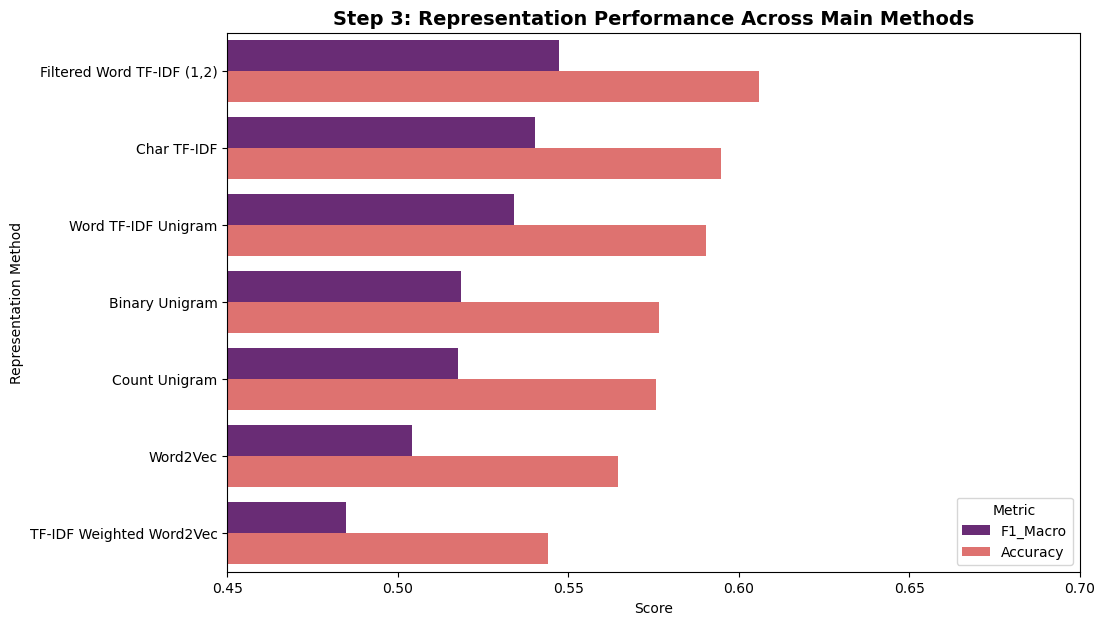

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Prepare Data based on Experiment Logs
rep_data = [
    {"Method": "Filtered Word TF-IDF (1,2)", "F1_Macro": 0.5474, "Accuracy": 0.6061},
    {"Method": "Char TF-IDF", "F1_Macro": 0.5404, "Accuracy": 0.5949},
    {"Method": "Word TF-IDF Unigram", "F1_Macro": 0.5342, "Accuracy": 0.5904},
    {"Method": "Binary Unigram", "F1_Macro": 0.5186, "Accuracy": 0.5766},
    {"Method": "Count Unigram", "F1_Macro": 0.5178, "Accuracy": 0.5759},
    {"Method": "Word2Vec", "F1_Macro": 0.5043, "Accuracy": 0.5646},
    {"Method": "TF-IDF Weighted Word2Vec", "F1_Macro": 0.4849, "Accuracy": 0.5440}
]
df_rep = pd.DataFrame(rep_data).sort_values(by="F1_Macro", ascending=False)

# 2. Reshape for Grouped Bar Chart
df_melted = df_rep.melt(id_vars="Method", var_name="Metric", value_name="Score")

# 3. Plotting
plt.figure(figsize=(11, 7))
sns.barplot(data=df_melted, y="Method", x="Score", hue="Metric", palette='magma')
plt.title("Step 3: Representation Performance Across Main Methods", fontsize=14, fontweight='bold')
plt.xlim(0.45, 0.7)  # Refined scale to highlight differences
plt.xlabel("Score")
plt.ylabel("Representation Method")
plt.legend(title="Metric", loc='lower right')
plt.show()


# Task 4: Model Training, Hyperparameter Tuning & Evaluation

## Overview
In Step 4, we compare three classification algorithms using the strongest text representations identified in Step 3. The aim is to determine which model gives the best balance between overall Accuracy and Macro F1 for this multi-class rating task.

## Models Evaluated
1. **Logistic Regression**
2. **Linear SVM (LinearSVC)**
3. **Naive Bayes (MultinomialNB)**

## Methodology
- **Validation strategy**: 3-fold Stratified K-Fold cross-validation
- **Main metrics**: Accuracy and Macro F1
- **Tuning approach**: Grid search or controlled model comparison, depending on the experiment
- **Goal**: identify the strongest model configuration before final test-set evaluation and Kaggle submission


#### 4.1 Logistic Regression: Initial Hyperparameter Tuning

Logistic Regression was used as a strong linear baseline because it handles sparse text features efficiently and gives a reliable benchmark for multi-class sentiment classification.

**Hyperparameters tuned**:
- **C**: controls regularization strength and model complexity
- **class_weight**: compares balanced weighting against the default unweighted setting
- Tested values for **C**: [0.75, 1.0, 1.5, 2.0, 3.0]

**Conclusion after experiment**: The best Logistic Regression setting was **C = 0.75** with **class_weight='balanced'**, reaching Macro F1 = **0.5522** and Accuracy = **0.6112**. This shows that class balancing helped the model handle uneven class frequencies more effectively.


In [ ]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, GridSearchCV

train_df = pd.read_csv("train_preprocessed_step2.csv")
train_df = train_df.dropna(subset=["processed_text", "rating"]).copy()
train_df["processed_text"] = train_df["processed_text"].astype(str)

X = train_df["processed_text"]
y = train_df["rating"]

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

logreg_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=5,
        max_df=0.85,
        max_features=35000,
        sublinear_tf=True
    )),
    ("clf", LogisticRegression(
        max_iter=3000,
        solver="lbfgs"
    ))
])

param_grid = {
    "clf__C": [0.75, 1.0, 1.5, 2.0, 3.0],
    "clf__class_weight": [None, "balanced"]
}

logreg_grid = GridSearchCV(
    estimator=logreg_pipeline,
    param_grid=param_grid,
    scoring=["accuracy", "f1_macro"],
    refit="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    return_train_score=False
)

logreg_grid.fit(X, y)

print("\n=== Best Logistic Regression ===")
print("Best Params:", logreg_grid.best_params_)
print("Best CV Macro-F1:", logreg_grid.best_score_)

results_df = pd.DataFrame(logreg_grid.cv_results_)
cols = [
    "param_clf__C",
    "param_clf__class_weight",
    "mean_test_accuracy",
    "std_test_accuracy",
    "mean_test_f1_macro",
    "std_test_f1_macro",
    "rank_test_f1_macro"
]
print(results_df[cols].sort_values("mean_test_f1_macro", ascending=False).to_string(index=False))

Fitting 3 folds for each of 10 candidates, totalling 30 fits

=== Best Logistic Regression ===
Best Params: {'clf__C': 0.75, 'clf__class_weight': 'balanced'}
Best CV Macro-F1: 0.5521884459211455
 param_clf__C param_clf__class_weight  mean_test_accuracy  std_test_accuracy  mean_test_f1_macro  std_test_f1_macro  rank_test_f1_macro
         0.75                balanced            0.611196           0.001054            0.552188           0.000967                   1
         1.00                balanced            0.610353           0.001320            0.550523           0.001019                   2
         1.50                balanced            0.607508           0.001164            0.546728           0.000836                   3
         2.00                balanced            0.604890           0.000895            0.543361           0.000570                   4
         3.00                balanced            0.600949           0.001355            0.538897           0.001153          

#### 4.2 Logistic Regression: TF-IDF Parameter Refinement

After selecting the best Logistic Regression classifier settings, we refined the TF-IDF representation to check whether small vocabulary filtering changes could produce additional gains.

**Parameters refined**:
- **min_df**: removes very rare terms
- **max_df**: removes overly common terms
- Tested values: **min_df** in [5, 10, 15], **max_df** in [0.80, 0.85]

**Conclusion after experiment**: Refining the TF-IDF thresholds produced only a very small improvement, with the best setting reaching Macro F1 = **0.5523**. This indicates the Logistic Regression pipeline was already close to its best performance, and extra feature filtering had limited impact.


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

logreg_refine_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1,2),
        max_features=35000,
        sublinear_tf=True
    )),
    ("clf", LogisticRegression(
        max_iter=3000,
        solver="lbfgs",
        C=0.75,
        class_weight="balanced"
    ))
])

logreg_refine_grid = {
    "tfidf__min_df": [5, 10, 15],
    "tfidf__max_df": [0.80, 0.85]
}

logreg_refine_search = GridSearchCV(
    logreg_refine_pipeline,
    logreg_refine_grid,
    scoring=["accuracy","f1_macro"],
    refit="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

logreg_refine_search.fit(X, y)

print("Best LR refine params:", logreg_refine_search.best_params_)
print("Best LR refine Macro-F1:", logreg_refine_search.best_score_)

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best LR refine params: {'tfidf__max_df': 0.8, 'tfidf__min_df': 15}
Best LR refine Macro-F1: 0.5523000400391849


In [ ]:
pd.DataFrame(logreg_refine_search.cv_results_)[[
    "param_tfidf__min_df",
    "param_tfidf__max_df",
    "mean_test_accuracy",
    "mean_test_f1_macro",
    "rank_test_f1_macro"
]].sort_values("mean_test_f1_macro", ascending=False)

,param_tfidf__min_df,param_tfidf__max_df,mean_test_accuracy,mean_test_f1_macro,rank_test_f1_macro
5,15,0.85,0.611290,0.552300,1
2,15,0.80,0.611290,0.552300,1
4,10,0.85,0.611259,0.552255,3
1,10,0.80,0.611259,0.552255,3
0,5,0.80,0.611196,0.552188,5
3,5,0.85,0.611196,0.552188,5


#### 4.3 Linear Support Vector Machine: Feature Representation Comparison

LinearSVC was evaluated because margin-based linear classifiers often perform strongly on high-dimensional sparse text data. Here, the main question was which representation works best for SVM.

**Representations compared**:
1. Character TF-IDF (3,5)
2. Filtered word TF-IDF (1,2)
3. Filtered word TF-IDF (1,3)

**Conclusion after experiment**: Character TF-IDF gave the strongest SVM performance with Accuracy = **0.6381** and Macro F1 = **0.5330**, outperforming both word-based TF-IDF variants. This suggests that the LinearSVC model benefited more from local subword patterns than from wider word n-gram features.


In [ ]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold, cross_validate

# Load dataset
train_df = pd.read_csv("train_preprocessed_step2.csv")
train_df = train_df.dropna(subset=["processed_text", "rating"]).copy()
train_df["processed_text"] = train_df["processed_text"].astype(str)

X = train_df["processed_text"]
y = train_df["rating"]

print("Shape:", train_df.shape)


# CV setup
cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

# Settings
svc_settings = [
    {
        "label": "Char TF-IDF",
        "vectorizer": TfidfVectorizer(
            analyzer="char_wb",
            ngram_range=(3, 5),
            min_df=5,
            max_features=15000,
            sublinear_tf=True
        )
    },
    {
        "label": "Filtered TF-IDF (1,2)",
        "vectorizer": TfidfVectorizer(
            ngram_range=(1, 2),
            min_df=15,
            max_df=0.85,
            max_features=35000,
            sublinear_tf=True
        )
    },
    {
        "label": "Filtered TF-IDF (1,3)",
        "vectorizer": TfidfVectorizer(
            ngram_range=(1, 3),
            min_df=15,
            max_df=0.85,
            max_features=35000,
            sublinear_tf=True
        )
    }
]

results = []

for s in svc_settings:
    print("Running:", s["label"])

    pipe = Pipeline([
        ("tfidf", s["vectorizer"]),
        ("clf", LinearSVC(
            C=1.0,
            class_weight="balanced"
        ))
    ])

    scores = cross_validate(
        pipe,
        X,
        y,
        cv=cv,
        scoring=["accuracy", "f1_macro"],
        n_jobs=-1
    )

    results.append({
        "Setting": s["label"],
        "Mean_Accuracy": scores["test_accuracy"].mean(),
        "Std_Accuracy": scores["test_accuracy"].std(),
        "Mean_F1_Macro": scores["test_f1_macro"].mean(),
        "Std_F1_Macro": scores["test_f1_macro"].std()
    })

results_df = pd.DataFrame(results).sort_values(
    by="Mean_F1_Macro",
    ascending=False
)

print("\n=== LinearSVC Representation Comparison ===")
print(results_df.to_string(index=False))

Shape: (287968, 3)
Running: Char TF-IDF
Running: Filtered TF-IDF (1,2)
Running: Filtered TF-IDF (1,3)

=== LinearSVC Representation Comparison ===
              Setting  Mean_Accuracy  Std_Accuracy  Mean_F1_Macro  Std_F1_Macro
          Char TF-IDF       0.638126      0.000994       0.533009      0.000663
Filtered TF-IDF (1,3)       0.621770      0.001093       0.528762      0.000831
Filtered TF-IDF (1,2)       0.621159      0.001339       0.527710      0.001006


#### 4.4 Linear SVM: C-Parameter Tuning

Once Character TF-IDF was identified as the best representation for LinearSVC, the regularization strength was tuned to find the strongest trade-off between generalization and fit.

**Parameter tuned**:
- **C**: controls the strength of regularization
- Tested values: [0.25, 0.5, 0.75, 1.0, 1.5]

**Conclusion after experiment**: The best LinearSVC setting was **C = 0.25**, which achieved Accuracy = **0.6422** and Macro F1 = **0.5348**. Lower regularization strength did not help here, so the more regularized setting gave the best overall generalization.


In [ ]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold, GridSearchCV


train_df = pd.read_csv("train_preprocessed_step2.csv")
train_df = train_df.dropna(subset=["processed_text", "rating"]).copy()
train_df["processed_text"] = train_df["processed_text"].astype(str)

X = train_df["processed_text"]
y = train_df["rating"]

print("Shape:", train_df.shape)

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)


svc_char_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        analyzer="char_wb",
        ngram_range=(3, 5),
        min_df=5,
        max_features=15000,
        sublinear_tf=True
    )),
    ("clf", LinearSVC(
        class_weight="balanced"
    ))
])


svc_char_param_grid = {
    "clf__C": [0.25, 0.5, 0.75, 1.0, 1.5]
}


svc_char_grid = GridSearchCV(
    estimator=svc_char_pipeline,
    param_grid=svc_char_param_grid,
    scoring=["accuracy", "f1_macro"],
    refit="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    return_train_score=False
)

svc_char_grid.fit(X, y)


print("\n=== Best LinearSVC + Char TF-IDF ===")
print("Best Params:", svc_char_grid.best_params_)
print("Best CV Macro-F1:", svc_char_grid.best_score_)


svc_char_results = pd.DataFrame(svc_char_grid.cv_results_)

cols_to_show = [
    "param_clf__C",
    "mean_test_accuracy",
    "std_test_accuracy",
    "mean_test_f1_macro",
    "std_test_f1_macro",
    "rank_test_f1_macro"
]

svc_char_results = svc_char_results[cols_to_show].sort_values(
    by="mean_test_f1_macro",
    ascending=False
)

print("\n=== LinearSVC Char TF-IDF C-Tuning Results ===")
print(svc_char_results.to_string(index=False))

Shape: (287968, 3)
Fitting 3 folds for each of 5 candidates, totalling 15 fits

=== Best LinearSVC + Char TF-IDF ===
Best Params: {'clf__C': 0.25}
Best CV Macro-F1: 0.5347739911420456

=== LinearSVC Char TF-IDF C-Tuning Results ===
 param_clf__C  mean_test_accuracy  std_test_accuracy  mean_test_f1_macro  std_test_f1_macro  rank_test_f1_macro
         0.25            0.642169           0.000687            0.534774           0.000230                   1
         0.50            0.640530           0.000952            0.534486           0.000532                   2
         0.75            0.639179           0.000985            0.533685           0.000691                   3
         1.00            0.638123           0.001005            0.533031           0.000664                   4
         1.50            0.636612           0.001027            0.532112           0.000950                   5


#### 4.5 Naive Bayes: TF-IDF Representation Comparison and Alpha Tuning

Multinomial Naive Bayes was included as a lightweight probabilistic baseline that is commonly used for text classification. We first compared TF-IDF representations and then tuned the smoothing parameter.

**Experiments performed**:
- TF-IDF (1,2) versus TF-IDF (1,3)
- Alpha values: [0.1, 0.25, 0.5, 0.75, 1.0, 2.0]

**Conclusion after experiment**: TF-IDF (1,3) was the better Naive Bayes representation, and tuning improved the best Macro F1 to **0.4960** with **alpha = 0.1**. Even after tuning, Naive Bayes remained clearly below Logistic Regression and LinearSVC on Macro F1.


In [ ]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import StratifiedKFold, cross_validate

# Load dataset
train_df = pd.read_csv("train_preprocessed_step2.csv")
train_df = train_df.dropna(subset=["processed_text", "rating"]).copy()
train_df["processed_text"] = train_df["processed_text"].astype(str)

X = train_df["processed_text"]
y = train_df["rating"]

print("Shape:", train_df.shape)

# CV setup
cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

# Naive Bayes settings
nb_settings = [
    {
        "label": "NB + TF-IDF (1,2)",
        "vectorizer": TfidfVectorizer(
            ngram_range=(1, 2),
            min_df=15,
            max_df=0.85,
            max_features=35000,
            sublinear_tf=True
        )
    },
    {
        "label": "NB + TF-IDF (1,3)",
        "vectorizer": TfidfVectorizer(
            ngram_range=(1, 3),
            min_df=15,
            max_df=0.85,
            max_features=35000,
            sublinear_tf=True
        )
    }
]

results = []

for s in nb_settings:
    print("Running:", s["label"])

    pipe = Pipeline([
        ("tfidf", s["vectorizer"]),
        ("clf", MultinomialNB())
    ])

    scores = cross_validate(
        pipe,
        X,
        y,
        cv=cv,
        scoring=["accuracy", "f1_macro"],
        n_jobs=-1
    )

    results.append({
        "Setting": s["label"],
        "Mean_Accuracy": scores["test_accuracy"].mean(),
        "Std_Accuracy": scores["test_accuracy"].std(),
        "Mean_F1_Macro": scores["test_f1_macro"].mean(),
        "Std_F1_Macro": scores["test_f1_macro"].std()
    })

results_df = pd.DataFrame(results).sort_values(
    by="Mean_F1_Macro",
    ascending=False
)

print("\n=== Naive Bayes Representation Comparison ===")
print(results_df.to_string(index=False))

Shape: (287968, 3)
Running: NB + TF-IDF (1,2)
Running: NB + TF-IDF (1,3)

=== Naive Bayes Representation Comparison ===
          Setting  Mean_Accuracy  Std_Accuracy  Mean_F1_Macro  Std_F1_Macro
NB + TF-IDF (1,3)       0.646839      0.001484       0.469284      0.002122
NB + TF-IDF (1,2)       0.643547      0.001273       0.453206      0.001911


In [ ]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import StratifiedKFold, GridSearchCV

# Load dataset
train_df = pd.read_csv("train_preprocessed_step2.csv")
train_df = train_df.dropna(subset=["processed_text", "rating"]).copy()
train_df["processed_text"] = train_df["processed_text"].astype(str)

X = train_df["processed_text"]
y = train_df["rating"]

print("Shape:", train_df.shape)

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

nb_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 3),
        min_df=15,
        max_df=0.85,
        max_features=35000,
        sublinear_tf=True
    )),
    ("clf", MultinomialNB())
])

param_grid = {
    "clf__alpha": [0.1, 0.25, 0.5, 0.75, 1.0, 2.0]
}

nb_grid = GridSearchCV(
    estimator=nb_pipeline,
    param_grid=param_grid,
    scoring=["accuracy", "f1_macro"],
    refit="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    return_train_score=False
)

nb_grid.fit(X, y)

print("\n=== Best Naive Bayes + TF-IDF (1,3) ===")
print("Best Params:", nb_grid.best_params_)
print("Best CV Macro-F1:", nb_grid.best_score_)

nb_results = pd.DataFrame(nb_grid.cv_results_)

cols_to_show = [
    "param_clf__alpha",
    "mean_test_accuracy",
    "std_test_accuracy",
    "mean_test_f1_macro",
    "std_test_f1_macro",
    "rank_test_f1_macro"
]

print("\n=== Naive Bayes Alpha-Tuning Results ===")
print(nb_results[cols_to_show].sort_values("rank_test_f1_macro").to_string(index=False))

Shape: (287968, 3)
Fitting 3 folds for each of 6 candidates, totalling 18 fits

=== Best Naive Bayes + TF-IDF (1,3) ===
Best Params: {'clf__alpha': 0.1}
Best CV Macro-F1: 0.4960109376183686

=== Naive Bayes Alpha-Tuning Results ===
 param_clf__alpha  mean_test_accuracy  std_test_accuracy  mean_test_f1_macro  std_test_f1_macro  rank_test_f1_macro
             0.10            0.647499           0.002005            0.496011           0.002883                   1
             0.25            0.647812           0.001945            0.492947           0.002860                   2
             0.50            0.647596           0.001631            0.485409           0.002265                   3
             0.75            0.647277           0.001613            0.477616           0.002458                   4
             1.00            0.646839           0.001484            0.469284           0.002122                   5
             2.00            0.640960           0.000703            0.43

#### 4.6 Naive Bayes: CountVectorizer Check

A separate CountVectorizer experiment was added to test whether Naive Bayes works better with raw term counts than with TF-IDF features. This is a useful check because MultinomialNB often aligns naturally with count-based inputs.

**Experiments performed**:
- CountVectorizer (1,2) versus CountVectorizer (1,3)
- Alpha values: [0.1, 0.25, 0.5, 0.75, 1.0, 2.0]

**Conclusion after experiment**: Count-based Naive Bayes improved substantially over TF-IDF Naive Bayes, with the best setup reaching Macro F1 = **0.5232** at **alpha = 0.1**. Alpha tuning had only a very small effect on the CountVectorizer pipeline, so the gain came mainly from using count-based features rather than from hyperparameter changes.


In [ ]:
# Standalone Naive Bayes + CountVectorizer comparison
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import StratifiedKFold, cross_validate

# Load dataset
train_df = pd.read_csv("train_preprocessed_step2.csv")
train_df = train_df.dropna(subset=["processed_text", "rating"]).copy()
train_df["processed_text"] = train_df["processed_text"].astype(str)

X = train_df["processed_text"]
y = train_df["rating"]

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

count_settings = [
    {
        "label": "NB + Count (1,2)",
        "vectorizer": CountVectorizer(
            ngram_range=(1, 2),
            min_df=15,
            max_df=0.85,
            max_features=35000
        )
    },
    {
        "label": "NB + Count (1,3)",
        "vectorizer": CountVectorizer(
            ngram_range=(1, 3),
            min_df=15,
            max_df=0.85,
            max_features=35000
        )
    }
]

results = []

for s in count_settings:
    print("Running:", s["label"])

    pipe = Pipeline([
        ("count", s["vectorizer"]),
        ("clf", MultinomialNB())
    ])

    scores = cross_validate(
        pipe,
        X,
        y,
        cv=cv,
        scoring=["accuracy", "f1_macro"],
        n_jobs=-1
    )

    results.append({
        "Setting": s["label"],
        "Mean_Accuracy": scores["test_accuracy"].mean(),
        "Std_Accuracy": scores["test_accuracy"].std(),
        "Mean_F1_Macro": scores["test_f1_macro"].mean(),
        "Std_F1_Macro": scores["test_f1_macro"].std()
    })

results_df = pd.DataFrame(results).sort_values(
    by="Mean_F1_Macro",
    ascending=False
)

print("\n=== Naive Bayes + CountVectorizer Comparison ===")
print(results_df.to_string(index=False))


Running: NB + Count (1,2)
Running: NB + Count (1,3)

=== Naive Bayes + CountVectorizer Comparison ===
         Setting  Mean_Accuracy  Std_Accuracy  Mean_F1_Macro  Std_F1_Macro
NB + Count (1,3)       0.611606      0.000992       0.522184       0.00027
NB + Count (1,2)       0.613474      0.000832       0.520851       0.00042


In [ ]:
# CountVectorizer + MultinomialNB alpha tuning
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import StratifiedKFold, GridSearchCV

# Load dataset
train_df = pd.read_csv("train_preprocessed_step2.csv")
train_df = train_df.dropna(subset=["processed_text", "rating"]).copy()
train_df["processed_text"] = train_df["processed_text"].astype(str)

X = train_df["processed_text"]
y = train_df["rating"]

print("Shape:", train_df.shape)

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

nb_count_pipeline = Pipeline([
    ("count", CountVectorizer(
        ngram_range=(1, 3),
        min_df=15,
        max_df=0.85,
        max_features=35000
    )),
    ("clf", MultinomialNB())
])

param_grid = {
    "clf__alpha": [0.1, 0.25, 0.5, 0.75, 1.0, 2.0]
}

nb_count_grid = GridSearchCV(
    estimator=nb_count_pipeline,
    param_grid=param_grid,
    scoring=["accuracy", "f1_macro"],
    refit="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    return_train_score=False
)

nb_count_grid.fit(X, y)

print("\n=== Best Naive Bayes + CountVectorizer (1,3) ===")
print("Best Params:", nb_count_grid.best_params_)
print("Best CV Macro-F1:", nb_count_grid.best_score_)

nb_count_results = pd.DataFrame(nb_count_grid.cv_results_)

cols_to_show = [
    "param_clf__alpha",
    "mean_test_accuracy",
    "std_test_accuracy",
    "mean_test_f1_macro",
    "std_test_f1_macro",
    "rank_test_f1_macro"
]

print("\n=== CountVectorizer + Naive Bayes Alpha-Tuning Results ===")
print(nb_count_results[cols_to_show].sort_values("rank_test_f1_macro").to_string(index=False))


Shape: (287968, 3)
Fitting 3 folds for each of 6 candidates, totalling 18 fits

=== Best Naive Bayes + CountVectorizer (1,3) ===
Best Params: {'clf__alpha': 0.1}
Best CV Macro-F1: 0.523191871280792

=== CountVectorizer + Naive Bayes Alpha-Tuning Results ===
 param_clf__alpha  mean_test_accuracy  std_test_accuracy  mean_test_f1_macro  std_test_f1_macro  rank_test_f1_macro
             0.10            0.611676           0.001119            0.523192           0.000554                   1
             0.25            0.611439           0.001137            0.522848           0.000416                   2
             0.50            0.611419           0.001061            0.522574           0.000328                   3
             0.75            0.611488           0.000908            0.522404           0.000073                   4
             1.00            0.611606           0.000992            0.522184           0.000270                   5
             2.00            0.612394         

### Step 4: Summary and Key Findings

**Summary of model performance**: Step 4 used **both Macro F1 and Accuracy** for model selection. Under the **best-F1 setup**, **Logistic Regression** was strongest with Macro F1 about **0.5523** and Accuracy about **0.6113**, followed by **LinearSVC** with Macro F1 about **0.5348** and Accuracy about **0.6422**. Under the **best-Accuracy setup**, the **unbalanced Logistic Regression** setting gave the strongest Accuracy, around **0.6721** in cross-validation, while **Naive Bayes** reached competitive Accuracy in some settings but remained clearly weaker on Macro F1.

**Tuning summary**: For Logistic Regression, classifier tuning selected **C = 0.75** with **class_weight='balanced'** for the best-F1 setup, while **C = 0.75** with **class_weight=None** gave the strongest Accuracy-oriented setup, and TF-IDF refinement added only a very small gain. LinearSVC benefited most from choosing Character TF-IDF with **C = 0.25**, which became its selected setup for both criteria. Naive Bayes improved more from switching to CountVectorizer than from alpha tuning itself, which had only a limited effect.

### Step 4: Visualization Summary

The following figures summarize the main Step 4 results, including tuning trends for each model family and the final optimized comparisons under best-F1 and best-Accuracy selection.


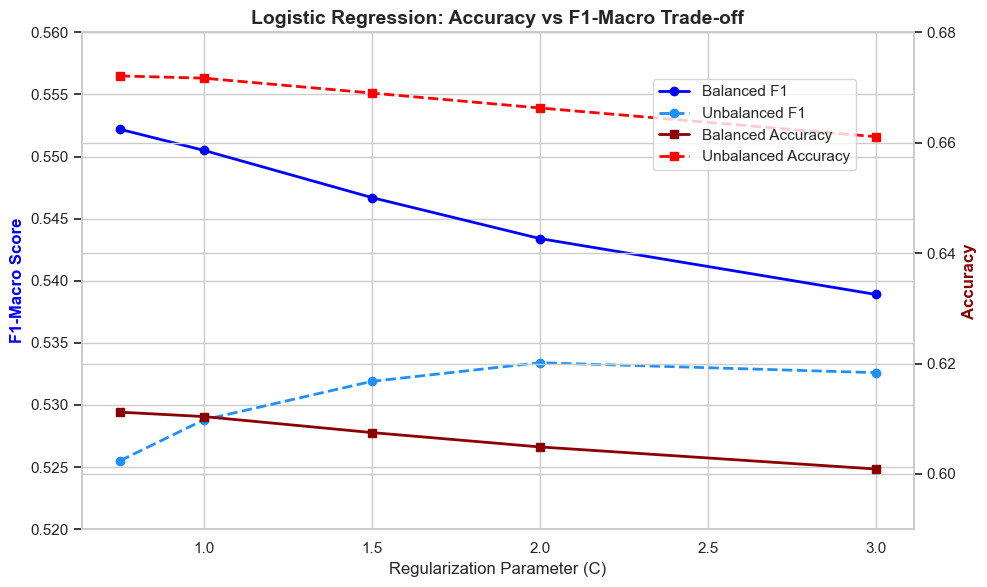

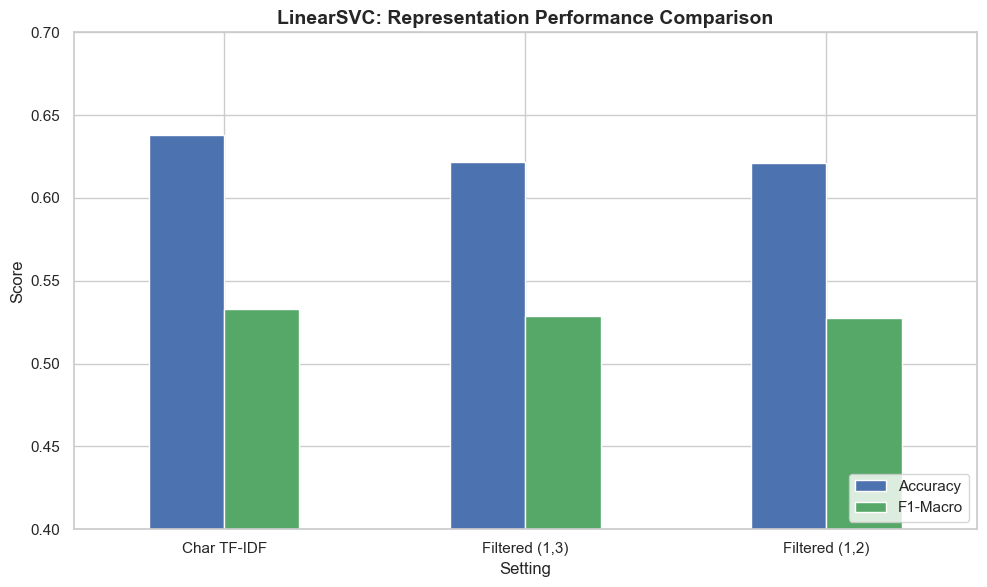

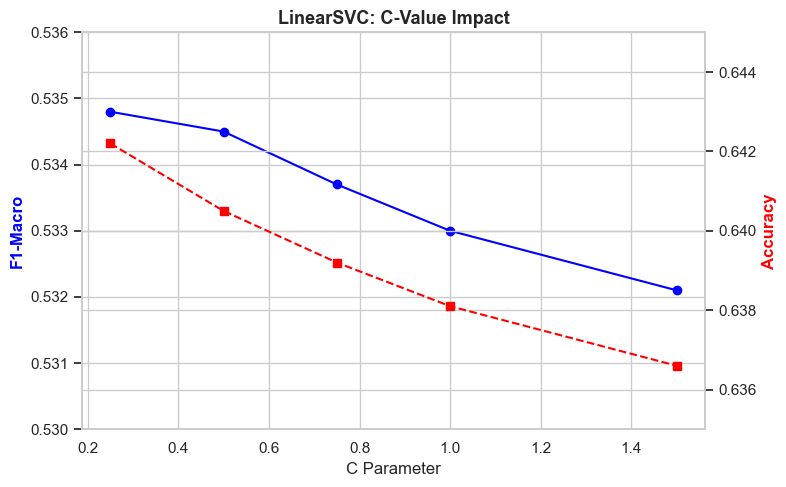

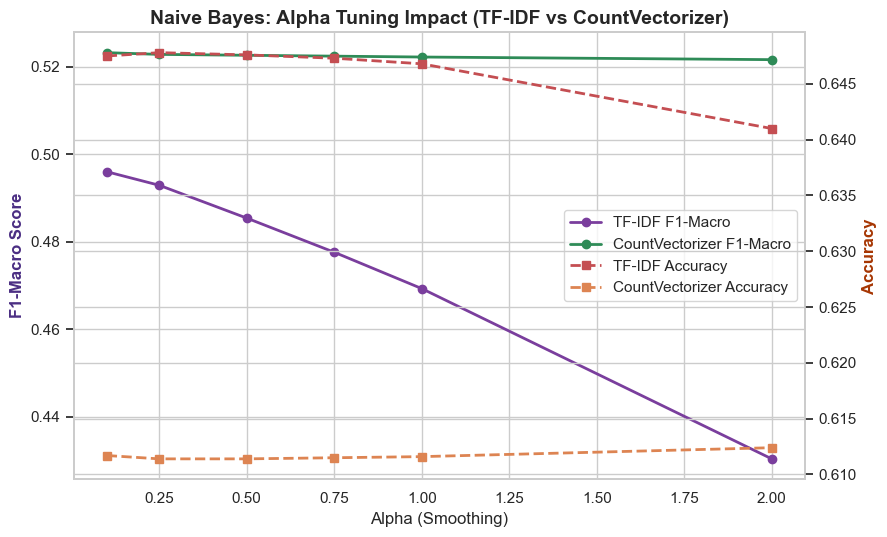

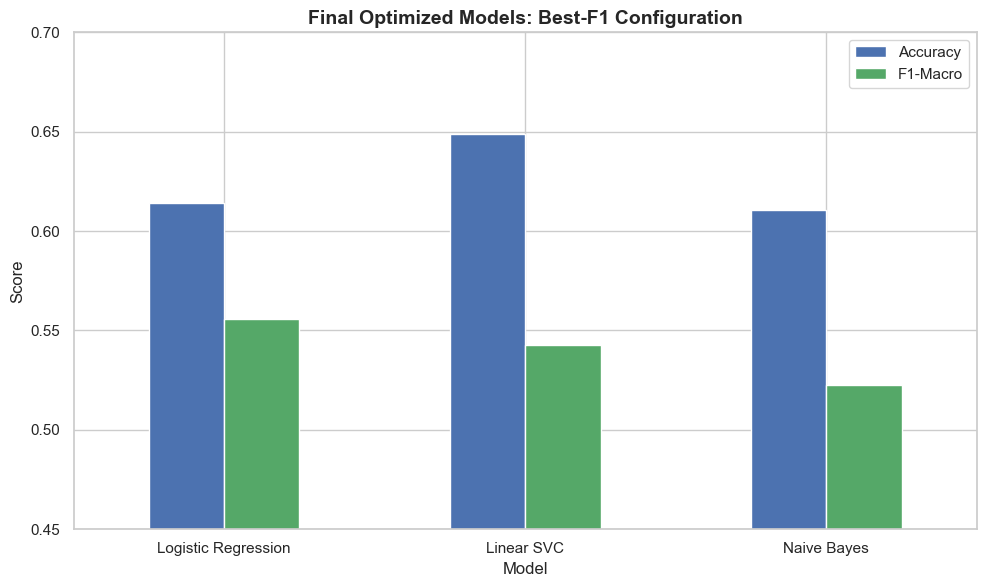

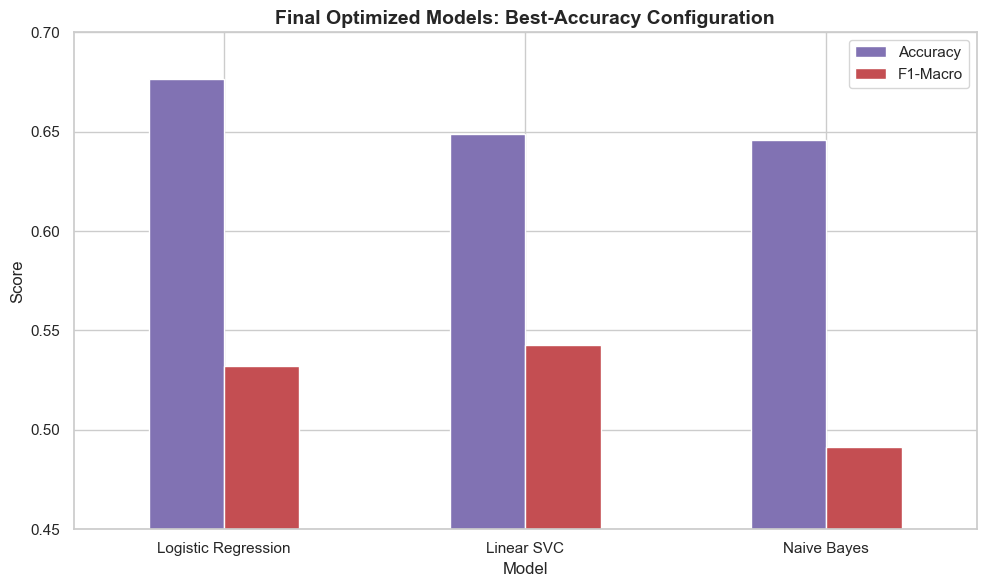

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'figure.autolayout': True})

# 1. Logistic Regression: C-Tuning & Class Weights
# Values verified against the stored Step 4 CV results.
lr_balanced = {
    'C': [0.75, 1.00, 1.50, 2.00, 3.00],
    'F1_Macro': [0.5522, 0.5505, 0.5467, 0.5434, 0.5389],
    'Accuracy': [0.6112, 0.6104, 0.6075, 0.6049, 0.6009]
}
lr_unbalanced = {
    'C': [0.75, 1.00, 1.50, 2.00, 3.00],
    'F1_Macro': [0.5255, 0.5288, 0.5319, 0.5334, 0.5326],
    'Accuracy': [0.6721, 0.6717, 0.6690, 0.6663, 0.6611]
}

fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(lr_balanced['C'], lr_balanced['F1_Macro'], marker='o', label='Balanced F1', color='blue', linewidth=2)
ax1.plot(lr_unbalanced['C'], lr_unbalanced['F1_Macro'], marker='o', label='Unbalanced F1', color='dodgerblue', linestyle='--', linewidth=2)
ax1.set_ylabel('F1-Macro Score', color='blue', fontsize=12, fontweight='bold')
ax1.set_xlabel('Regularization Parameter (C)')
ax1.set_ylim(0.52, 0.56)

ax2 = ax1.twinx()
ax2.plot(lr_balanced['C'], lr_balanced['Accuracy'], marker='s', label='Balanced Accuracy', color='darkred', linewidth=2)
ax2.plot(lr_unbalanced['C'], lr_unbalanced['Accuracy'], marker='s', label='Unbalanced Accuracy', color='red', linestyle='--', linewidth=2)
ax2.set_ylabel('Accuracy', color='darkred', fontsize=12, fontweight='bold')
ax2.set_ylim(0.59, 0.68)

plt.title('Logistic Regression: Accuracy vs F1-Macro Trade-off', fontsize=14, fontweight='bold')
fig.legend(loc='upper right', bbox_to_anchor=(0.87, 0.87))
plt.show()

# 2. LinearSVC: Representation Comparison and C Tuning
svc_tuning = {
    'C': [0.25, 0.50, 0.75, 1.00, 1.50],
    'F1_Macro': [0.5348, 0.5345, 0.5337, 0.5330, 0.5321],
    'Accuracy': [0.6422, 0.6405, 0.6392, 0.6381, 0.6366]
}

svc_rep = pd.DataFrame({
    'Setting': ['Char TF-IDF', 'Filtered (1,3)', 'Filtered (1,2)'],
    'Accuracy': [0.6381, 0.6218, 0.6212],
    'F1-Macro': [0.5330, 0.5288, 0.5277]
})

svc_rep.set_index('Setting').plot(kind='bar', figsize=(10, 6), rot=0, color=['#4C72B0', '#55A868'])
plt.title('LinearSVC: Representation Performance Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Score')
plt.ylim(0.4, 0.7)
plt.legend(loc='lower right')
plt.show()

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(svc_tuning['C'], svc_tuning['F1_Macro'], marker='o', color='blue', label='F1-Macro')
ax1.set_ylabel('F1-Macro', color='blue', fontweight='bold')
ax1.set_xlabel('C Parameter')
ax1.set_ylim(0.53, 0.536)

ax2 = ax1.twinx()
ax2.plot(svc_tuning['C'], svc_tuning['Accuracy'], marker='s', color='red', linestyle='--', label='Accuracy')
ax2.set_ylabel('Accuracy', color='red', fontweight='bold')
ax2.set_ylim(0.635, 0.645)
plt.title('LinearSVC: C-Value Impact', fontsize=13, fontweight='bold')
plt.show()

# 3. Naive Bayes: Alpha Tuning Impact for TF-IDF and CountVectorizer
nb_tfidf = pd.DataFrame({
    'Alpha': [0.1, 0.25, 0.5, 0.75, 1.0, 2.0],
    'F1_Macro': [0.4960, 0.4929, 0.4854, 0.4776, 0.4693, 0.4304],
    'Accuracy': [0.6475, 0.6478, 0.6476, 0.6473, 0.6468, 0.6410]
})
nb_count = pd.DataFrame({
    'Alpha': [0.1, 0.25, 0.5, 0.75, 1.0, 2.0],
    'F1_Macro': [0.5232, 0.5228, 0.5226, 0.5224, 0.5222, 0.5216],
    'Accuracy': [0.6117, 0.6114, 0.6114, 0.6115, 0.6116, 0.6124]
})

fig, ax1 = plt.subplots(figsize=(9, 5.5))
ax1.plot(nb_tfidf['Alpha'], nb_tfidf['F1_Macro'], marker='o', color='#7A3E9D', linewidth=2, label='TF-IDF F1-Macro')
ax1.plot(nb_count['Alpha'], nb_count['F1_Macro'], marker='o', color='#2E8B57', linewidth=2, label='CountVectorizer F1-Macro')
ax1.set_xlabel('Alpha (Smoothing)')
ax1.set_ylabel('F1-Macro Score', color='#4B2E83', fontweight='bold')

ax2 = ax1.twinx()
ax2.plot(nb_tfidf['Alpha'], nb_tfidf['Accuracy'], marker='s', linestyle='--', color='#C44E52', linewidth=2, label='TF-IDF Accuracy')
ax2.plot(nb_count['Alpha'], nb_count['Accuracy'], marker='s', linestyle='--', color='#DD8452', linewidth=2, label='CountVectorizer Accuracy')
ax2.set_ylabel('Accuracy', color='#A63603', fontweight='bold')

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='center right', frameon=True)
plt.title('Naive Bayes: Alpha Tuning Impact (TF-IDF vs CountVectorizer)', fontsize=14, fontweight='bold')
plt.show()

# 4. Final Model Comparison on the test set
final_best_f1 = pd.DataFrame({
    'Model': ['Logistic Regression', 'Linear SVC', 'Naive Bayes'],
    'Accuracy': [0.6140, 0.6491, 0.6104],
    'F1-Macro': [0.5560, 0.5428, 0.5224]
})

final_best_acc = pd.DataFrame({
    'Model': ['Logistic Regression', 'Linear SVC', 'Naive Bayes'],
    'Accuracy': [0.6763, 0.6491, 0.6458],
    'F1-Macro': [0.5321, 0.5428, 0.4915]
})

final_best_f1.set_index('Model').plot(kind='bar', figsize=(10, 6), rot=0, color=['#4C72B0', '#55A868'])
plt.title('Final Optimized Models: Best-F1 Configuration', fontsize=14, fontweight='bold')
plt.ylabel('Score')
plt.ylim(0.45, 0.7)
plt.legend(loc='upper right')
plt.show()

final_best_acc.set_index('Model').plot(kind='bar', figsize=(10, 6), rot=0, color=['#8172B3', '#C44E52'])
plt.title('Final Optimized Models: Best-Accuracy Configuration', fontsize=14, fontweight='bold')
plt.ylabel('Score')
plt.ylim(0.45, 0.7)
plt.legend(loc='upper right')
plt.show()

### Step 4: Final Test Set Evaluation

After tuning, the strongest configuration from each model family was retrained on the full training set and evaluated on `test.csv`. This provides a final comparison on unseen data using the same preprocessing pipeline defined earlier in the notebook.

Where relevant, both the best-Macro-F1 and best-Accuracy variants were tested to compare the trade-off between balanced class performance and overall correctness.


In [ ]:
# Logistic Regression on test set: best F1 params vs best Accuracy params
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

train_df = train_df[["text", "rating"]].dropna().copy()
test_df = test_df[["text", "rating"]].dropna().copy()
train_df["text"] = train_df["text"].astype(str)
test_df["text"] = test_df["text"].astype(str)

X_train = train_df["text"]
y_train = train_df["rating"]
X_test = test_df["text"]
y_test = test_df["rating"]

lr_configs = [
    {
        "label": "LR Best F1",
        "vectorizer": TfidfVectorizer(
            ngram_range=(1, 2),
            min_df=15,
            max_df=0.85,
            max_features=35000,
            sublinear_tf=True
        ),
        "classifier": LogisticRegression(
            max_iter=3000,
            solver="lbfgs",
            C=0.75,
            class_weight="balanced"
        )
    },
    {
        "label": "LR Best Accuracy",
        "vectorizer": TfidfVectorizer(
            ngram_range=(1, 2),
            min_df=15,
            max_df=0.85,
            max_features=35000,
            sublinear_tf=True
        ),
        "classifier": LogisticRegression(
            max_iter=3000,
            solver="lbfgs",
            C=0.75,
            class_weight=None
        )
    }
]

lr_results = []

for cfg in lr_configs:
    model = Pipeline([
        ("preprocess", FinalTextPreprocessor()),
        ("tfidf", cfg["vectorizer"]),
        ("clf", cfg["classifier"])
    ])

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    lr_results.append({
        "Setting": cfg["label"],
        "Test_Accuracy": accuracy_score(y_test, y_pred),
        "Test_F1_Macro": f1_score(y_test, y_pred, average="macro")
    })

lr_results_df = pd.DataFrame(lr_results).sort_values("Test_F1_Macro", ascending=False)
print("=== Logistic Regression Test Set Results ===")
print(lr_results_df.to_string(index=False))


=== Logistic Regression Test Set Results ===
         Setting  Test_Accuracy  Test_F1_Macro
      LR Best F1       0.613972       0.556036
LR Best Accuracy       0.676347       0.532067


In [ ]:
# LinearSVC on test set: best F1 params vs best Accuracy params
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score

train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

train_df = train_df[["text", "rating"]].dropna().copy()
test_df = test_df[["text", "rating"]].dropna().copy()
train_df["text"] = train_df["text"].astype(str)
test_df["text"] = test_df["text"].astype(str)

X_train = train_df["text"]
y_train = train_df["rating"]
X_test = test_df["text"]
y_test = test_df["rating"]

svc_configs = [
    {
        "label": "LinearSVC Best F1 and Accuracy",
        "vectorizer": TfidfVectorizer(
            analyzer="char_wb",
            ngram_range=(3, 5),
            min_df=5,
            max_features=15000,
            sublinear_tf=True
        ),
        "classifier": LinearSVC(
            C=0.25,
            class_weight="balanced"
        )
    },
]

svc_results = []

for cfg in svc_configs:
    model = Pipeline([
        ("preprocess", FinalTextPreprocessor()),
        ("tfidf", cfg["vectorizer"]),
        ("clf", cfg["classifier"])
    ])

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    svc_results.append({
        "Setting": cfg["label"],
        "Test_Accuracy": accuracy_score(y_test, y_pred),
        "Test_F1_Macro": f1_score(y_test, y_pred, average="macro")
    })

svc_results_df = pd.DataFrame(svc_results).sort_values("Test_F1_Macro", ascending=False)
print("=== LinearSVC Test Set Results ===")
print(svc_results_df.to_string(index=False))


=== LinearSVC Test Set Results ===
                       Setting  Test_Accuracy  Test_F1_Macro
LinearSVC Best F1 and Accuracy       0.649097       0.542774


In [ ]:
# Naive Bayes on test set: best F1 params vs best Accuracy params
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, f1_score

train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

train_df = train_df[["text", "rating"]].dropna().copy()
test_df = test_df[["text", "rating"]].dropna().copy()
train_df["text"] = train_df["text"].astype(str)
test_df["text"] = test_df["text"].astype(str)

X_train = train_df["text"]
y_train = train_df["rating"]
X_test = test_df["text"]
y_test = test_df["rating"]

nb_configs = [
    {
        "label": "NB Best F1",
        "vectorizer": CountVectorizer(
            ngram_range=(1, 3),
            min_df=15,
            max_df=0.85,
            max_features=35000
        ),
        "classifier": MultinomialNB()
    },
    {
        "label": "NB Best Accuracy",
        "vectorizer": TfidfVectorizer(
            ngram_range=(1, 3),
            min_df=15,
            max_df=0.85,
            max_features=35000,
            sublinear_tf=True
        ),
        "classifier": MultinomialNB(alpha=0.25)
    }
]

nb_results = []

for cfg in nb_configs:
    model = Pipeline([
        ("preprocess", FinalTextPreprocessor()),
        ("vectorizer", cfg["vectorizer"]),
        ("clf", cfg["classifier"])
    ])

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    nb_results.append({
        "Setting": cfg["label"],
        "Test_Accuracy": accuracy_score(y_test, y_pred),
        "Test_F1_Macro": f1_score(y_test, y_pred, average="macro")
    })

nb_results_df = pd.DataFrame(nb_results).sort_values("Test_F1_Macro", ascending=False)
print("=== Naive Bayes Test Set Results ===")
print(nb_results_df.to_string(index=False))


=== Naive Bayes Test Set Results ===
         Setting  Test_Accuracy  Test_F1_Macro
      NB Best F1       0.610361       0.522407
NB Best Accuracy       0.645806       0.491482


#### 4.10 Kaggle Submission Choice

For Kaggle submission, the selected files were the **best-F1 Logistic Regression**, **best-Accuracy Logistic Regression**, and **LinearSVC** models. The two Logistic Regression submissions were included to compare both optimization priorities directly, while LinearSVC was chosen because it remained a strong and balanced alternative on unseen data.

Naive Bayes was not submitted because, although its Accuracy was reasonable, its Macro F1 stayed clearly lower and Linear regression accuracy was still higher than it.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DATA_PATH = "/content/drive/MyDrive/TA_CW2/"


Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import re

from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

import nltk
nltk.download("punkt")
nltk.download("wordnet")
nltk.download("omw-1.4")
nltk.download('punkt_tab')

from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
train_df = pd.read_csv(DATA_PATH + "train.csv")
test_df  = pd.read_csv(DATA_PATH + "test.csv")

# Basic cleaning
train_df = train_df[["text", "rating"]].dropna().copy()
train_df["text"] = train_df["text"].astype(str)
test_df["text"] = test_df["text"].astype(str)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

lemmatizer = WordNetLemmatizer()

def remove_noise(text: str) -> str:
    noise_patterns = [
        r"\(translated by google\)",
        r"translated by google",
        r"\(original\)",
        r"\boriginal\b",
        r"\btranslated\b",
        r"\bgoogle\b"
    ]
    for pattern in noise_patterns:
        text = re.sub(pattern, " ", text, flags=re.IGNORECASE)
    return text

def normalization(text: str) -> str:
    text = remove_noise(text)
    text = text.lower()
    text = re.sub(r"[^a-z0-9'\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

class FinalTextPreprocessor(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        processed = []

        for text in X:
            text = normalization(str(text))
            tokens = word_tokenize(text)

            clean_tokens = []
            for word in tokens:
                if word in ["'", "''", "``"]:
                    continue
                lemma = lemmatizer.lemmatize(word, pos="v")
                clean_tokens.append(lemma)

            processed.append(" ".join(clean_tokens))

        return processed

class LightNormalizer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return [normalization(str(text)) for text in X]

# Model 1 - Best Macro-F1 style
model_f1 = Pipeline([
    ("preprocess", FinalTextPreprocessor()),
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=15,
        max_df=0.80,
        max_features=35000,
        sublinear_tf=True
    )),
    ("clf", LogisticRegression(
        C=0.75,
        class_weight="balanced",
        max_iter=3000,
        solver="lbfgs"
    ))
])

# Model 2 - Best Accuracy style
model_acc = Pipeline([
    ("preprocess", FinalTextPreprocessor()),
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=15,
        max_df=0.80,
        max_features=35000,
        sublinear_tf=True
    )),
    ("clf", LogisticRegression(
        C=0.75,
        class_weight=None,
        max_iter=3000,
        solver="lbfgs"
    ))
])

# Model 3 - Char LinearSVC
model_svc = Pipeline([
    ("preprocess", LightNormalizer()),
    ("tfidf", TfidfVectorizer(
        analyzer="char_wb",
        ngram_range=(3, 5),
        min_df=5,
        max_features=15000,
        sublinear_tf=True
    )),
    ("clf", LinearSVC(
        C=0.25,
        class_weight="balanced"
    ))
])

X_train = train_df["text"]
y_train = train_df["rating"]


def create_submission(model, name):
    preds = model.predict(test_df["text"])

    submission = pd.DataFrame({
        "Id": test_df["Id"],
        "Rating": preds
    })

    path = DATA_PATH + name
    submission.to_csv(path, index=False)

    print(f"Saved: {path}")
    print(submission.head(), "\n")

Train shape: (288000, 2)
Test shape: (89100, 2)


In [ ]:
print("\nTraining Model F1...")
model_f1.fit(X_train, y_train)
create_submission(model_f1,  "submission_lr_f1.csv")


Training Model F1...
Saved: /content/drive/MyDrive/TA_CW2/submission_lr_f1.csv
   Id  Rating
0   1       4
1   2       3
2   3       4
3   4       2
4   5       5 



In [ ]:
print("\nTraining Model Accuracy...")
model_acc.fit(X_train, y_train)
create_submission(model_acc, "submission_lr_acc.csv")


Training Model Accuracy...
Saved: /content/drive/MyDrive/TA_CW2/submission_lr_acc.csv
   Id  Rating
0   1       4
1   2       4
2   3       4
3   4       1
4   5       5 



In [ ]:
print("\nTraining LinearSVC...")
model_svc.fit(X_train, y_train)
create_submission(model_svc, "submission_svc.csv")


Training LinearSVC...
Saved: /content/drive/MyDrive/TA_CW2/submission_svc.csv
   Id  Rating
0   1       4
1   2       4
2   3       4
3   4       2
4   5       5 



# Task 5: Modelling text as a Sequence

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls /content/drive/MyDrive/

'Colab Notebooks'	     new_TA_dataset1.csv   train.csv
 final_dataset_labeled.csv   test.csv		   VADER_labeled_dataset_2.csv


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, SpatialDropout1D, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
!pip install keras-tuner
import keras_tuner as kt

For Deep Learning sequence models like LSTMs, we want to preserve the natural flow of the sentence, including stop words and negations. Therefore, the pre-processing differs from the pre-processing done in step 2.

1. Label Shifting: strated count from 0 till 4 (In dataset its from 1 till 5)
2. Tokenization & Vocabulary Limiting: Tokenizer converts all text to lowercase, removes basic punctuation and build a dictionary of the top 20,000 most frequently used words and assign each word a unique number.
3. Based on our EDA where we found most reviews are short, so we set the max_length to 150 words.

## Experiment 1: Automated Hyperparameter Tuning (Keras Tuner)



Tokenizing and Padding...
Setting up Hyperparameter Tuning on 10% Subset to find the optimal hyperparameters...
Reloading Tuner from tuning_dir/lstm_tuning_final/tuner0.json

Best Embedding Dim: 64
Best LSTM Units: 64
Best Learning Rate: 0.01

Building and Training Final Model on Full Dataset...
Epoch 1/10
810/810 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.5815 - loss: 1.0364 - val_accuracy: 0.6622 - val_loss: 0.8473 - learning_rate: 0.0100
Epoch 2/10
810/810 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.6706 - loss: 0.8200 - val_accuracy: 0.6732 - val_loss: 0.8294 - learning_rate: 0.0100
Epoch 3/10
810/810 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.6887 - loss: 0.7796 - val_accuracy: 0.6718 - val_loss: 0.8337 - learning_rate: 0.0100
Epoch 4/10
810/810 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.7122 - loss: 0.7233 - val_accuracy: 0.6716 - val_loss: 0.8416 - learning_rate: 0.0020

Evaluating Final Model on Test Set...
1800/1800 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - ac

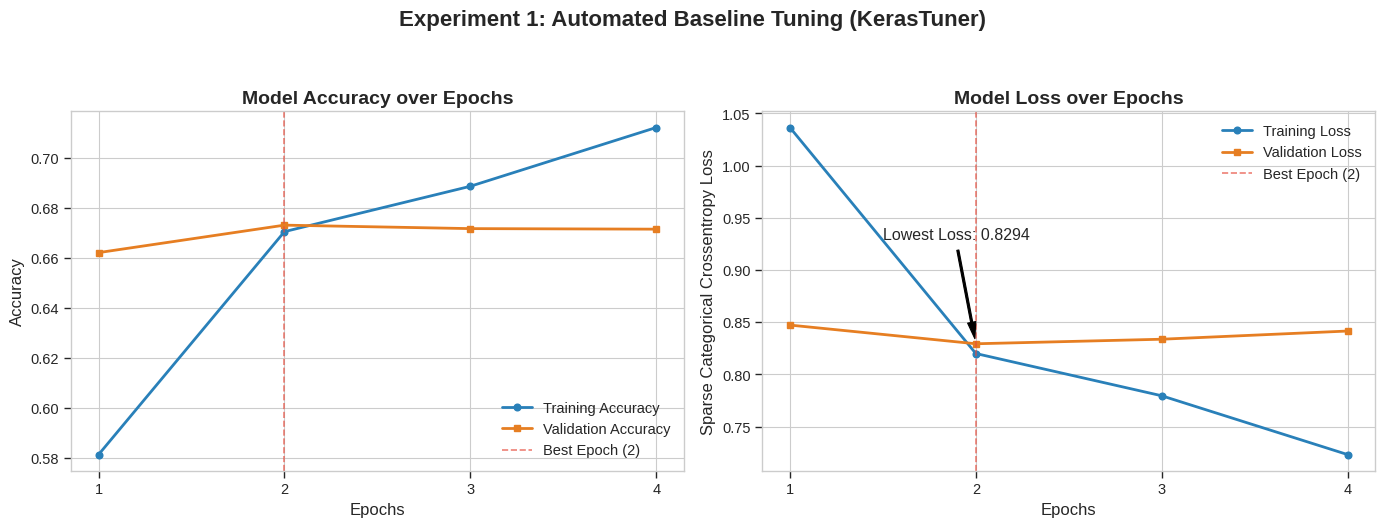

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, SpatialDropout1D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
import keras_tuner as kt
import matplotlib.pyplot as plt
import seaborn as sns


# Load Data
train_data = pd.read_csv("/content/drive/MyDrive/train.csv")
X_raw = train_data['text'].astype(str)
y = train_data['rating'] - 1  # Keras expects labels to start at 0 (so 1-5 becomes 0-4)

print("Tokenizing and Padding...")
max_words = 20000    # Only use the top 20,000 most frequent words
max_length = 150     # Based on our EDA, 150 words covers the vast majority of reviews

# Tokenizer learns 20,000 most common words and assigns each word a unique integer.
# If a word is not recognized, it become OOV (Out of Vocabulary)
tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_raw)
# Converts text into list of integers
X_sequences = tokenizer.texts_to_sequences(X_raw)
# Ensures that every single review is 150 words long
# If a review is 50 words, it adds 100 zeros to the end, and if a review is 300 words, it removes 150 words from the end.
X_padded = pad_sequences(X_sequences, maxlen=max_length, padding='post', truncating='post')

# Split the dataset
X_train_full, X_test, y_train_full, y_test = train_test_split(X_padded, y, test_size=0.2, random_state=42)


# We take 10% of the training data to test different combinations of hyperparameters to find the optimal combination
print("Setting up Hyperparameter Tuning on 10% Subset to find the optimal hyperparameters...")
# We take a small slice of the training data to find the best parameters quickly
X_tune = X_train_full[:20000]
y_tune = y_train_full[:20000]

def build_LSTM(hp):
    model = Sequential()

    # Tuning the embedding dimensions (64, 128)
    hp_embed = hp.Int('embedding_dim', min_value=64, max_value=128, step=64)
    model.add(Embedding(input_dim=max_words, output_dim=hp_embed))
    model.add(SpatialDropout1D(0.2))

    # Tuning the number of LSTM units (32, 64, 96)
    hp_lstm = hp.Int('lstm_units', min_value=32, max_value=96, step=32)
    model.add(LSTM(hp_lstm, dropout=0.2))

    # Output layer for 5 classes
    model.add(Dense(5, activation='softmax'))

    # Tuning the learning rate
    hp_lr = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    optimizer = tf.keras.optimizers.Adam(learning_rate=hp_lr)

    model.compile(loss='sparse_categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    return model

# Use Hyperband to quickly kill bad models and find the best one
tuner = kt.Hyperband(
    build_LSTM,
    objective='val_accuracy',
    max_epochs=5,
    directory='tuning_dir',
    project_name='lstm_tuning_final'
)

# Run the search on the small subset
tuner.search(X_tune, y_tune, epochs=5, validation_split=0.2, verbose=1)

# Get the optimal hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"\nBest Embedding Dim: {best_hps.get('embedding_dim')}")
print(f"Best LSTM Units: {best_hps.get('lstm_units')}")
print(f"Best Learning Rate: {best_hps.get('learning_rate')}")


# Training the final model on training dataset from the best hyper-parameter combination found above
print("\nBuilding and Training Final Model on Full Dataset...")
final_model = tuner.hypermodel.build(best_hps)

# Early Stopping:
# Stop training if validation accuracy stops improving for 2 epochs
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
# Reduce the learning rate automatically if the model gets stuck
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=1, min_lr=1e-5)

# Train the model once on the full dataset
history = final_model.fit(
    X_train_full, y_train_full,
    epochs=10,
    batch_size=256,
    validation_split=0.1,
    callbacks=[early_stop, reduce_lr]
)

# Evaluation
print("\nEvaluating Final Model on Test Set...")
test_loss, test_acc = final_model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

# Plots for report
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.2)

# Extract data from the history object
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

# Find the epoch with the lowest validation loss (where early stopping restored weights)
best_epoch = np.argmin(val_loss) + 1
best_val_loss = min(val_loss)
best_val_acc = val_acc[best_epoch - 1]

# Create a side-by-side figure (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Accuracy
ax1.plot(epochs_range, acc, label='Training Accuracy', color='#2980b9', linewidth=2, marker='o')
ax1.plot(epochs_range, val_acc, label='Validation Accuracy', color='#e67e22', linewidth=2, marker='s')
ax1.axvline(x=best_epoch, color='#e74c3c', linestyle='--', alpha=0.7, label=f'Best Epoch ({best_epoch})')

ax1.set_title('Model Accuracy over Epochs', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epochs', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.legend(loc='lower right')
ax1.set_xticks(epochs_range)

# Plot 2: Loss
ax2.plot(epochs_range, loss, label='Training Loss', color='#2980b9', linewidth=2, marker='o')
ax2.plot(epochs_range, val_loss, label='Validation Loss', color='#e67e22', linewidth=2, marker='s')
ax2.axvline(x=best_epoch, color='#e74c3c', linestyle='--', alpha=0.7, label=f'Best Epoch ({best_epoch})')

# Annotate the best loss point
ax2.annotate(f'Lowest Loss: {best_val_loss:.4f}',
             xy=(best_epoch, best_val_loss),
             xytext=(best_epoch - 0.5, best_val_loss + 0.1),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=6))

ax2.set_title('Model Loss over Epochs', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epochs', fontsize=12)
ax2.set_ylabel('Sparse Categorical Crossentropy Loss', fontsize=12)
ax2.legend(loc='upper right')
ax2.set_xticks(epochs_range)

# Finalize and save
plt.suptitle('Experiment 1: Automated Baseline Tuning (KerasTuner)', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('experiment1_learning_curves.png', dpi=300, bbox_inches='tight')
plt.show()


## Experiment 2: The Overfitting Test (10 Epochs, No Early Stopping)

Experiment 1 was a good baseline, but it does not tells us how the model behaves when we push its limits so we conducted this experiment with 10 epochs, removing early stopping. This was done to understand how the LSTM learns the nuances og human language. By forcing all 15 models to run for 10 epochs, we gathered evi.dence needed to prove where the model's peak learning capacity stops and where the model starts memorizing

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, SpatialDropout1D
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import gc

Loading and Padding Data...

Starting Pipeline for 15 combinations...
NO Early Stopping. Each model will train for exactly 10 epochs.

------------------------------------------------------------
Training Combination 1/15:
Embed: 64 | LSTM: 64 | Drop: 0.2 | LR: 0.01 | Batch: 256
Epoch 1/10
810/810 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.6011 - loss: 1.0021 - val_accuracy: 0.6589 - val_loss: 0.8495
Epoch 2/10
810/810 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.6757 - loss: 0.8112 - val_accuracy: 0.6700 - val_loss: 0.8308
Epoch 3/10
810/810 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.6902 - loss: 0.7735 - val_accuracy: 0.6699 - val_loss: 0.8314
Epoch 4/10
810/810 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.7019 - loss: 0.7486 - val_accuracy: 0.6691 - val_loss: 0.8430
Epoch 5/10
810/810 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.7085 - loss: 0.7319 - val_accuracy: 0.6648 - val_loss: 0.8567
Epoch 6/10
810/810 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.71

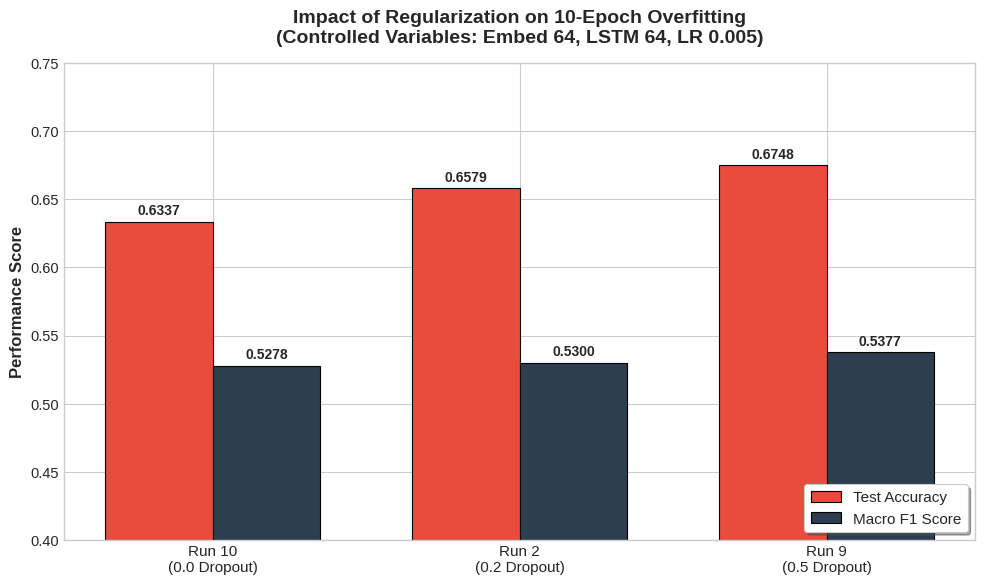

In [ ]:
import matplotlib.pyplot as plt
# Load Data
print("Loading and Padding Data...")
train_data = pd.read_csv("/content/drive/MyDrive/train.csv")
X_raw = train_data['text'].astype(str)
y = train_data['rating'] - 1 # Keras expects labels to start from 0

max_words = 20000
max_length = 150

# Tokenizer learns 20,000 most common words and assigns each word a unique integer.
# If a word is not recognized, it become OOV (Out of Vocabulary)
tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_raw)
# Converts text into list of integers
X_sequences = tokenizer.texts_to_sequences(X_raw)
# Ensures that every single review is 150 words long
# If a review is 50 words, it adds 100 zeros to the end, and if a review is 300 words, it removes 150 words from the end.
X_padded = pad_sequences(X_sequences, maxlen=max_length, padding='post', truncating='post')

# Splitting dataset
X_train, X_test, y_train, y_test = train_test_split(X_padded, y, test_size=0.2, random_state=42)
EPOCHS = 10

# Defining 15 different hyperparameters combination
hyperparameters = [
    {'run': 1, 'embed_dim': 64,  'lstm_units': 64,  'dropout': 0.2, 'lr': 0.01,   'batch_size': 256},
    {'run': 2, 'embed_dim': 64,  'lstm_units': 64,  'dropout': 0.2, 'lr': 0.005,  'batch_size': 256},
    {'run': 3, 'embed_dim': 64,  'lstm_units': 64,  'dropout': 0.2, 'lr': 0.001,  'batch_size': 256}, # Slow learner
    {'run': 4, 'embed_dim': 32,  'lstm_units': 32,  'dropout': 0.2, 'lr': 0.005,  'batch_size': 256}, # Very small
    {'run': 5, 'embed_dim': 128, 'lstm_units': 64,  'dropout': 0.2, 'lr': 0.005,  'batch_size': 256}, # Wide embeddings
    {'run': 6, 'embed_dim': 64,  'lstm_units': 128, 'dropout': 0.2, 'lr': 0.005,  'batch_size': 256}, # Wide LSTM
    {'run': 7, 'embed_dim': 128, 'lstm_units': 128, 'dropout': 0.2, 'lr': 0.005,  'batch_size': 256}, # Heavyweight
    # dropout tests
    {'run': 8, 'embed_dim': 128, 'lstm_units': 128, 'dropout': 0.4, 'lr': 0.005,  'batch_size': 256}, # Heavyweight + High Dropout
    {'run': 9, 'embed_dim': 64,  'lstm_units': 64,  'dropout': 0.5, 'lr': 0.005,  'batch_size': 256}, # Extreme Regularization
    {'run': 10,'embed_dim': 64,  'lstm_units': 64,  'dropout': 0.0, 'lr': 0.005,  'batch_size': 256}, # ZERO Dropout (Guaranteed to overfit quickly)
    # batch size test
    {'run': 11,'embed_dim': 64,  'lstm_units': 64,  'dropout': 0.2, 'lr': 0.005,  'batch_size': 128}, # Smaller batch (more updates)
    {'run': 12,'embed_dim': 64,  'lstm_units': 64,  'dropout': 0.2, 'lr': 0.005,  'batch_size': 512}, # Larger batch (faster, smoother gradients)
    {'run': 13,'embed_dim': 64,  'lstm_units': 64,  'dropout': 0.2, 'lr': 0.005,  'batch_size': 1024},# Massive batch
    {'run': 14,'embed_dim': 128, 'lstm_units': 32,  'dropout': 0.2, 'lr': 0.005,  'batch_size': 256}, # Lots of vocab memory, small engine
    {'run': 15,'embed_dim': 32,  'lstm_units': 128, 'dropout': 0.2, 'lr': 0.005,  'batch_size': 256}  # Tiny vocab memory, massive engine
]

# Dictionary to store the final score of each model
results_log = []

print(f"\nStarting Pipeline for {len(hyperparameters)} combinations...")
print(f"NO Early Stopping. Each model will train for exactly {EPOCHS} epochs.\n")
# Loop to train all 15 models
for config in hyperparameters:
    print("-" * 60)
    print(f"Training Combination {config['run']}/15:")
    print(f"Embed: {config['embed_dim']} | LSTM: {config['lstm_units']} | Drop: {config['dropout']} | LR: {config['lr']} | Batch: {config['batch_size']}")

    # Clears Keras backend memory so Colab GPU doesn't crash
    tf.keras.backend.clear_session()
    gc.collect()

    # Building the Model
    model = Sequential()
    # Converts the integer sequences into dense math vectors
    model.add(Embedding(input_dim=max_words, output_dim=config['embed_dim']))
    model.add(SpatialDropout1D(config['dropout']))
    model.add(LSTM(config['lstm_units'], dropout=config['dropout']))
    model.add(Dense(5, activation='softmax'))

    # Compiling Model
    optimizer = tf.keras.optimizers.Adam(learning_rate=config['lr'])
    model.compile(loss='sparse_categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

    # Training Model
    history = model.fit(
        X_train, y_train,
        epochs=EPOCHS,
        batch_size=config['batch_size'],
        # It splits off 10% of the training data (validation_split=0.1) to check its progress at the end of every epoch.
        validation_split=0.1,
        verbose=1
    )

    # Evaluation
    print("Evaluating on unseen test data...")
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

    # Get the model's predictions, these come as raw percentages
    y_pred_probs = model.predict(X_test, verbose=0)

    # Converts these percentages to actual class predictions (0, 1, 2, 3/4)
    y_pred = np.argmax(y_pred_probs, axis=1)

    # Calculating Macro F1 Score
    macro_f1 = f1_score(y_test, y_pred, average='macro')

    # Saving the result
    config['test_accuracy'] = test_acc
    config['macro_f1'] = macro_f1
    results_log.append(config)

    print(f"Combination {config['run']} -> Accuracy: {test_acc:.4f} | Macro F1: {macro_f1:.4f}\n")


print("=" * 70)
print("FINAL PIPELINE RESULTS")
print("=" * 70)

# Sort results by test accuracy (highest first)
results_log_sorted = sorted(results_log, key=lambda x: x['test_accuracy'], reverse=True)

# Print all 15 in order of performance
for res in results_log_sorted:
    print(f"Rank {results_log_sorted.index(res)+1:2d}: Run {res['run']:2d} -> Acc: {res['test_accuracy']:.4f} | F1: {res['macro_f1']:.4f}  (Embed:{res['embed_dim']:3d}, LSTM:{res['lstm_units']:3d}, Drop:{res['dropout']}, LR:{res['lr']}, Batch:{res['batch_size']:4d})")

print("-" * 70)
best_model = results_log_sorted[0]
print(f"THE BEST COMBINATION IS RUN {best_model['run']}")
print(f"Achieved Test Accuracy: {best_model['test_accuracy']:.4f}")
print(f"Achieved Macro F1 Score: {best_model['macro_f1']:.4f}")

# Plots for report
plt.style.use('seaborn-v0_8-whitegrid')

# Isolate the runs that serve as our perfectly controlled experiment
# Run 10 (0.0 Dropout), Run 2 (0.2 Dropout), Run 9 (0.5 Dropout)
target_runs = [10, 2, 9]
controlled_results = [res for res in results_log if res['run'] in target_runs]

# Sort them from lowest dropout to highest dropout
controlled_results.sort(key=lambda x: x['dropout'])

# Extract the data for plotting
labels = [
    f"Run 10\n(0.0 Dropout)",
    f"Run 2\n(0.2 Dropout)",
    f"Run 9\n(0.5 Dropout)"
]
acc_scores = [res['test_accuracy'] for res in controlled_results]
f1_scores = [res['macro_f1'] for res in controlled_results]

# Build the Grouped Bar Chart
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

rects1 = ax.bar(x - width/2, acc_scores, width, label='Test Accuracy', color='#e74c3c', edgecolor='black')
rects2 = ax.bar(x + width/2, f1_scores, width, label='Macro F1 Score', color='#2c3e50', edgecolor='black')

# Add data labels on top of the bars for precise reading
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

autolabel(rects1)
autolabel(rects2)

# Formatting the graph
ax.set_ylabel('Performance Score', fontsize=12, fontweight='bold')
ax.set_title('Impact of Regularization on 10-Epoch Overfitting\n(Controlled Variables: Embed 64, LSTM 64, LR 0.005)', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylim(0.40, 0.75) # Zoomed in to clearly show the difference
ax.legend(loc='lower right', fontsize=11, frameon=True, shadow=True)

# Save and show
plt.tight_layout()
plt.savefig('exp2_overfitting_dropout_analysis.png', dpi=300)
plt.show()


## Experiment 3: Preventing Overfitting

Look at Run 1 as a perfect example:

Epoch 2: val_loss: 0.8291 | val_accuracy: 0.6716 (This is the peak)

Epoch 10: val_loss: 0.8851 | val_accuracy: 0.6613 (It got worse)

Because our script evaluates the X_test data at the very end of the run, the final scores you got (Accuracy: 0.6609) were calculated using the overfitted brain from Epoch 10, not the highly accurate brain from Epoch 2.

Running the full 10 epochs gathered the evidence about overfitting.

Therfore, in this experiment, we will reduce the number of epochs.

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, SpatialDropout1D
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.metrics import f1_score
import gc

Loading and Padding Data...

Starting Pipeline for 15 combinations...
NO Early Stopping. Each model will train for exactly 3 epochs.

------------------------------------------------------------
Training Combination 1/15:
Embed: 64 | LSTM: 64 | Drop: 0.2 | LR: 0.01 | Batch: 256
Epoch 1/3
203/203 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.4815 - loss: 1.2907 - val_accuracy: 0.6193 - val_loss: 0.9817
Epoch 2/3
203/203 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.6293 - loss: 0.9275 - val_accuracy: 0.6556 - val_loss: 0.8759
Epoch 3/3
203/203 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.6757 - loss: 0.8051 - val_accuracy: 0.6545 - val_loss: 0.8840
Evaluating on unseen test data...
Combination 1 -> Accuracy: 0.6423 | Macro F1: 0.4762

------------------------------------------------------------
Training Combination 2/15:
Embed: 64 | LSTM: 64 | Drop: 0.2 | LR: 0.005 | Batch: 256
Epoch 1/3
203/203 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.4764 - loss: 1.3028 - val_accuracy: 0

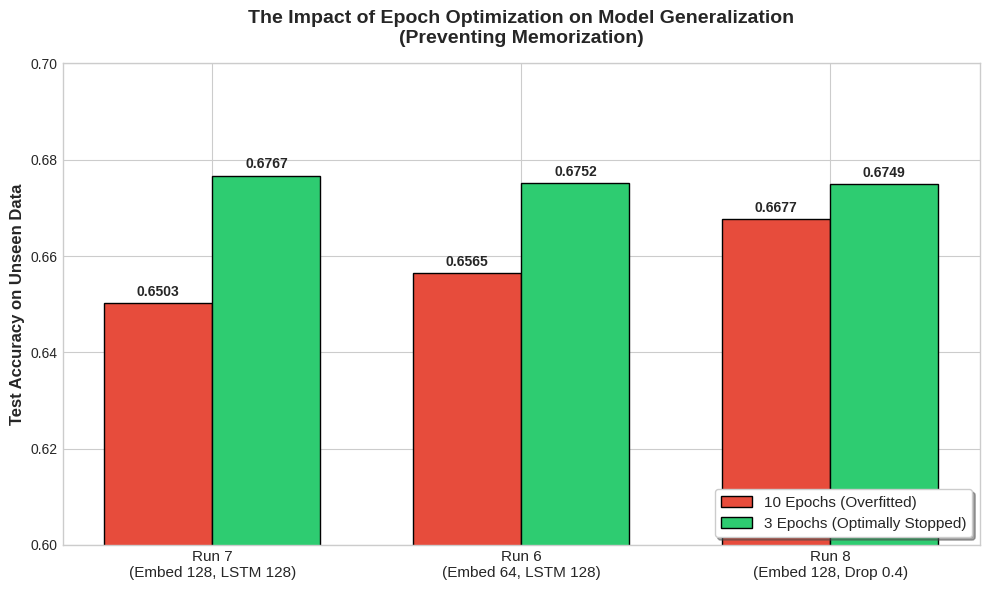

In [ ]:
print("Loading and Padding Data...")
train_data = pd.read_csv("/content/drive/MyDrive/test/test.csv")
X_raw = train_data['text'].astype(str)
y = train_data['rating'] - 1

max_words = 20000
max_length = 150

# Tokenizer learns 20,000 most common words and assigns each word a unique integer.
# If a word is not recognized, it become OOV (Out of Vocabulary)
tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_raw)
# Converts text into list of integers
X_sequences = tokenizer.texts_to_sequences(X_raw)
# Ensures that every single review is 150 words long
# If a review is 50 words, it adds 100 zeros to the end, and if a review is 300 words, it removes 150 words from the end.
X_padded = pad_sequences(X_sequences, maxlen=max_length, padding='post', truncating='post')

# Data Split
X_train, X_test, y_train, y_test = train_test_split(X_padded, y, test_size=0.2, random_state=42)
EPOCHS = 3

# Defining 15 different hyperparameters combination
hyperparameters = [
    {'run': 1, 'embed_dim': 64,  'lstm_units': 64,  'dropout': 0.2, 'lr': 0.01,   'batch_size': 256},
    {'run': 2, 'embed_dim': 64,  'lstm_units': 64,  'dropout': 0.2, 'lr': 0.005,  'batch_size': 256},
    {'run': 3, 'embed_dim': 64,  'lstm_units': 64,  'dropout': 0.2, 'lr': 0.001,  'batch_size': 256}, # Slow learner
    {'run': 4, 'embed_dim': 32,  'lstm_units': 32,  'dropout': 0.2, 'lr': 0.005,  'batch_size': 256}, # Very small
    {'run': 5, 'embed_dim': 128, 'lstm_units': 64,  'dropout': 0.2, 'lr': 0.005,  'batch_size': 256}, # Wide embeddings
    {'run': 6, 'embed_dim': 64,  'lstm_units': 128, 'dropout': 0.2, 'lr': 0.005,  'batch_size': 256}, # Wide LSTM
    {'run': 7, 'embed_dim': 128, 'lstm_units': 128, 'dropout': 0.2, 'lr': 0.005,  'batch_size': 256}, # Heavyweight
    # Dropout tests
    {'run': 8, 'embed_dim': 128, 'lstm_units': 128, 'dropout': 0.4, 'lr': 0.005,  'batch_size': 256}, # Heavyweight + High Dropout
    {'run': 9, 'embed_dim': 64,  'lstm_units': 64,  'dropout': 0.5, 'lr': 0.005,  'batch_size': 256}, # Extreme Regularization
    {'run': 10,'embed_dim': 64,  'lstm_units': 64,  'dropout': 0.0, 'lr': 0.005,  'batch_size': 256}, # ZERO Dropout (Guaranteed to overfit quickly)
    # Batch Size Test
    {'run': 11,'embed_dim': 64,  'lstm_units': 64,  'dropout': 0.2, 'lr': 0.005,  'batch_size': 128}, # Smaller batch (more updates)
    {'run': 12,'embed_dim': 64,  'lstm_units': 64,  'dropout': 0.2, 'lr': 0.005,  'batch_size': 512}, # Larger batch (faster, smoother gradients)
    {'run': 13,'embed_dim': 64,  'lstm_units': 64,  'dropout': 0.2, 'lr': 0.005,  'batch_size': 1024},# Massive batch
    {'run': 14,'embed_dim': 128, 'lstm_units': 32,  'dropout': 0.2, 'lr': 0.005,  'batch_size': 256}, # Lots of vocab memory, small engine
    {'run': 15,'embed_dim': 32,  'lstm_units': 128, 'dropout': 0.2, 'lr': 0.005,  'batch_size': 256}  # Tiny vocab memory, massive engine
]

# Dictionary to store final score of each model
results_log = []

print(f"\nStarting Pipeline for {len(hyperparameters)} combinations...")
print(f"NO Early Stopping. Each model will train for exactly {EPOCHS} epochs.\n")

for config in hyperparameters:
    print("-" * 60)
    print(f"Training Combination {config['run']}/15:")
    print(f"Embed: {config['embed_dim']} | LSTM: {config['lstm_units']} | Drop: {config['dropout']} | LR: {config['lr']} | Batch: {config['batch_size']}")

    # Clear Keras backend memory so Colab GPU doesn't crash
    tf.keras.backend.clear_session()
    gc.collect()

    # Building Model
    model = Sequential()
    model.add(Embedding(input_dim=max_words, output_dim=config['embed_dim']))
    model.add(SpatialDropout1D(config['dropout']))
    model.add(LSTM(config['lstm_units'], dropout=config['dropout']))
    model.add(Dense(5, activation='softmax'))

    # Compiling Model
    optimizer = tf.keras.optimizers.Adam(learning_rate=config['lr'])
    model.compile(loss='sparse_categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

    # Training Model
    history = model.fit(
        X_train, y_train,
        epochs=EPOCHS,
        batch_size=config['batch_size'],
        validation_split=0.1,
        verbose=1
    )

    print("Evaluating on unseen test data...")
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

    # Get the model's predictions
    y_pred_probs = model.predict(X_test, verbose=0)

    # Convert the percentages to actual class predictions (0, 1, 2, 3/4)
    y_pred = np.argmax(y_pred_probs, axis=1)

    # Calculate Macro F1 Score
    macro_f1 = f1_score(y_test, y_pred, average='macro')

    # Saving the result
    config['test_accuracy'] = test_acc
    config['macro_f1'] = macro_f1
    results_log.append(config)

    print(f"Combination {config['run']} -> Accuracy: {test_acc:.4f} | Macro F1: {macro_f1:.4f}\n")


print("=" * 70)
print("FINAL PIPELINE RESULTS")
print("=" * 70)

# Sort results by test accuracy (highest first)
results_log_sorted = sorted(results_log, key=lambda x: x['test_accuracy'], reverse=True)

# Print all 15 in order of performance
for res in results_log_sorted:
    print(f"Rank {results_log_sorted.index(res)+1:2d}: Run {res['run']:2d} -> Acc: {res['test_accuracy']:.4f} | F1: {res['macro_f1']:.4f}  (Embed:{res['embed_dim']:3d}, LSTM:{res['lstm_units']:3d}, Drop:{res['dropout']}, LR:{res['lr']}, Batch:{res['batch_size']:4d})")

print("-" * 70)
best_model = results_log_sorted[0]
print(f"THE BEST COMBINATION IS RUN {best_model['run']}")
print(f"Achieved Test Accuracy: {best_model['test_accuracy']:.4f}")
print(f"Achieved Macro F1 Score: {best_model['macro_f1']:.4f}")

# ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# KAGGLE SUBMISSION CODE

print("\n" + "=" * 70)
print("PREPARING FINAL KAGGLE SUBMISSION")
print("=" * 70)

print(f"Retraining the winning model (Run {best_model['run']}) on 100% of the training data...")
tf.keras.backend.clear_session()
gc.collect()

final_model = Sequential()
final_model.add(Embedding(input_dim=max_words, output_dim=best_model['embed_dim']))
final_model.add(SpatialDropout1D(best_model['dropout']))
final_model.add(LSTM(best_model['lstm_units'], dropout=best_model['dropout']))
final_model.add(Dense(5, activation='softmax'))

optimizer = tf.keras.optimizers.Adam(learning_rate=best_model['lr'])
final_model.compile(loss='sparse_categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])


final_model.fit(
    X_padded, y,
    epochs=EPOCHS,
    batch_size=best_model['batch_size'],
    verbose=1
)

print("\nLoading Kaggle test.csv data...")
test_data = pd.read_csv("/content/drive/MyDrive/testK.csv")

# Process using the existing tokenizer
X_kaggle_raw = test_data['text'].astype(str)
X_kaggle_seq = tokenizer.texts_to_sequences(X_kaggle_raw)
X_kaggle_padded = pad_sequences(X_kaggle_seq, maxlen=max_length, padding='post', truncating='post')

print("Generating predictions...")
predictions_probs = final_model.predict(X_kaggle_padded)
predictions_classes = np.argmax(predictions_probs, axis=1)

# Shift ratings back to 1-5 scale
final_ratings = predictions_classes + 1

print("Creating submission.csv...")
submission_df = pd.DataFrame({
    'Id': test_data['Id'],
    'Rating': final_ratings
})

submission_df.to_csv("submission.csv", index=False)
print("Done! 'submission.csv' has been generated and is ready to upload.")
print(submission_df.head())

# Plots for report
plt.style.use('seaborn-v0_8-whitegrid')

# Data extracted from Experiment 2 (10 Epochs) and Experiment 3 (3 Epochs) results
# We isolate the Top 3 performing models from Exp 3 to show how much they improved
labels = [
    'Run 7\n(Embed 128, LSTM 128)',
    'Run 6\n(Embed 64, LSTM 128)',
    'Run 8\n(Embed 128, Drop 0.4)'
]

# Accuracies when forced to overfit for 10 epochs (from Exp 2 logs)
acc_10_epochs = [0.6503, 0.6565, 0.6677]

# Accuracies when optimally stopped at 3 epochs (from Exp 3 logs)
acc_3_epochs = [0.6767, 0.6752, 0.6749]

x = np.arange(len(labels))
width = 0.35

# Build the comparative bar chart
fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, acc_10_epochs, width, label='10 Epochs (Overfitted)', color='#e74c3c', edgecolor='black')
rects2 = ax.bar(x + width/2, acc_3_epochs, width, label='3 Epochs (Optimally Stopped)', color='#2ecc71', edgecolor='black')

# Add exact score labels on top of the bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

autolabel(rects1)
autolabel(rects2)

# Formatting
ax.set_ylabel('Test Accuracy on Unseen Data', fontsize=12, fontweight='bold')
ax.set_title('The Impact of Epoch Optimization on Model Generalization\n(Preventing Memorization)', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylim(0.60, 0.70) # Zoomed in to clearly highlight the delta
ax.legend(loc='lower right', fontsize=11, frameon=True, shadow=True)

# Save and and shoq
plt.tight_layout()
plt.savefig('exp3_epoch_optimization_comparison.png', dpi=300)
plt.show()


###**Evaluating Experiment 3 on Test Set**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report
import tensorflow as tf
import gc

print("\n" + "=" * 70)
print("RETRAINING BEST STANDARD LSTM & EVALUATING ON EXTERNAL TEST SET")
print("=" * 70)


# RETRAIN THE WINNING MODEL
print(f"Retraining the winning model (Run {best_model['run']}) on 100% of training data...")
tf.keras.backend.clear_session()
gc.collect()

# Rebuild the architecture using the best hyperparameters
final_model = Sequential()
final_model.add(Embedding(input_dim=max_words, output_dim=best_model['embed_dim']))
final_model.add(SpatialDropout1D(best_model['dropout']))
final_model.add(LSTM(best_model['lstm_units'], dropout=best_model['dropout']))
final_model.add(Dense(5, activation='softmax'))

optimizer = tf.keras.optimizers.Adam(learning_rate=best_model['lr'])
final_model.compile(loss='sparse_categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

# Train on the full dataset (X_padded, y) for 3 Epochs
final_model.fit(
    X_padded, y,
    epochs=EPOCHS,
    batch_size=best_model['batch_size'],
    verbose=1
)


# Load and process test dataset
print("\nLoading external test set...")
eval_test_data = pd.read_csv("/content/drive/MyDrive/test/test.csv")

# Process the text using the existing tokenizer
# We use texts_to_sequences so the model doesn't "cheat" and learn new words
X_eval_seq = tokenizer.texts_to_sequences(eval_test_data['text'].astype(str))
X_eval_padded = pad_sequences(X_eval_seq, maxlen=max_length, padding='post', truncating='post')

# Shift the 1-5 star ratings to 0-4 for the model's loss function
y_eval_true = eval_test_data['rating'] - 1

print(f"Successfully loaded and processed {len(eval_test_data)} test reviews.")


# Evaluate and print report
print("\nEvaluating Standard LSTM on External Test Set...")
eval_loss, eval_acc = final_model.evaluate(X_eval_padded, y_eval_true, verbose=0)
print(f"Standard LSTM Test Accuracy: {eval_acc:.4f}")


eval_preds_probs = final_model.predict(X_eval_padded, verbose=0)
eval_preds = np.argmax(eval_preds_probs, axis=1)

print("\nClassification Report (Standard LSTM):")
print(classification_report(
    y_eval_true,
    eval_preds,
    target_names=['1-Star', '2-Star', '3-Star', '4-Star', '5-Star']
))


RETRAINING BEST STANDARD LSTM & EVALUATING ON EXTERNAL TEST SET
Retraining the winning model (Run 2) on 100% of training data...
Epoch 1/3
282/282 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.4838 - loss: 1.2701
Epoch 2/3
282/282 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.6341 - loss: 0.9114
Epoch 3/3
282/282 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.6754 - loss: 0.8139

Loading external test set...
Successfully loaded and processed 72000 test reviews.

Evaluating Standard LSTM on External Test Set...
Standard LSTM Test Accuracy: 0.7114

Classification Report (Standard LSTM):
              precision    recall  f1-score   support

      1-Star       0.77      0.96      0.85     27395
      2-Star       0.50      0.11      0.18      8055
      3-Star       0.48      0.36      0.41      8832
      4-Star       0.74      0.77      0.75     20518
      5-Star       0.65      0.73      0.69      7200

    accuracy                           0.71     72000
   macro avg       0.6

## Experiment 4: Bi-LSTM

In Experiment 3, the model achieved its highest accuracy of approximately 67%, but the F1-Score remained low (~53%) which indicated the class imbalance. To force the model to learn the minority classes, the follwoing changes were made:
  1. Making the model a Bi-Directional LSTM so that it reads from left-to-right and right-to-left both.
  2. Applying class weights for class imbalance.

Loading and Padding Data...

Calculating Class Weights to handle imbalance...
Weights applied: {0: np.float64(0.5256433655776601), 1: np.float64(1.7866004962779156), 2: np.float64(1.6331159625744258), 3: np.float64(0.7011564211807669), 4: np.float64(2.0027816411682893)}

Starting Bidirectional Pipeline for 5 combinations...
----------------------------------------------------------------------
Training Bi-LSTM Combination 1/5:
Embed: 64 | LSTM Units: 32 (x2 for Bidi) | Drop: 0.2
Epoch 1/5
203/203 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.5094 - loss: 1.1737 - val_accuracy: 0.5191 - val_loss: 1.0847
Epoch 2/5
203/203 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.5976 - loss: 0.9758 - val_accuracy: 0.5469 - val_loss: 1.0244
Epoch 3/5
203/203 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.6393 - loss: 0.8822 - val_accuracy: 0.5832 - val_loss: 0.9891
Epoch 4/5
203/203 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.6786 - loss: 0.7962 - val_accuracy: 0.5851 - val_loss: 1.0088
Eval

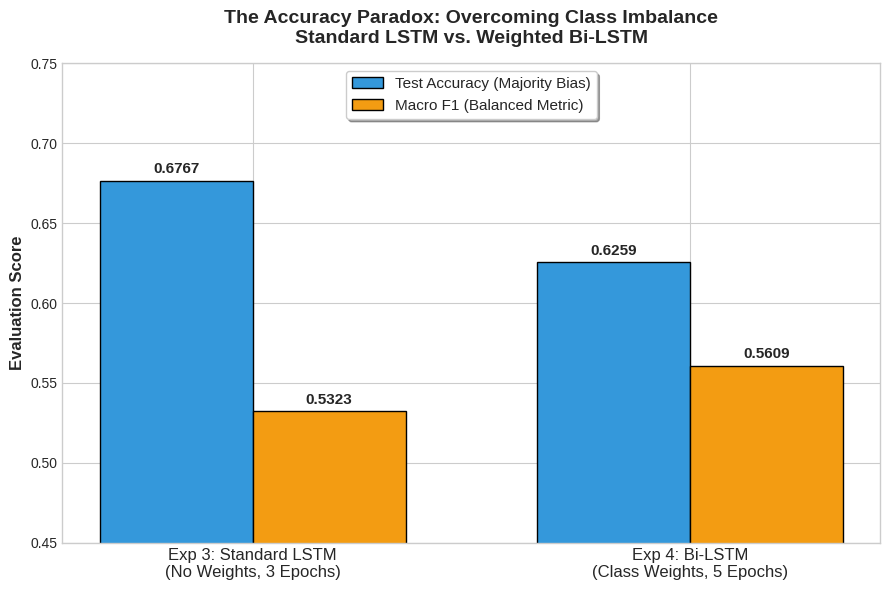

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, SpatialDropout1D, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_class_weight
import gc
import matplotlib.pyplot as plt

print("Loading and Padding Data...")
train_data = pd.read_csv("/content/drive/MyDrive/test/test.csv")
X_raw = train_data['text'].astype(str)
y = train_data['rating'] - 1

max_words = 20000
max_length = 150

# Tokenizer learns 20,000 most common words and assigns each word a unique integer.
# If a word is not recognized, it become OOV (Out of Vocabulary)
tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_raw)
X_sequences = tokenizer.texts_to_sequences(X_raw)
# Ensures that every single review is 150 words long
# If a review is 50 words, it adds 100 zeros to the end, and if a review is 300 words, it removes 150 words from the end.
X_padded = pad_sequences(X_sequences, maxlen=max_length, padding='post', truncating='post')

# Splitting the dataset
X_train, X_test, y_train, y_test = train_test_split(X_padded, y, test_size=0.2, random_state=42)

# compute_class_weigth scans y_train data and counts how many 1,2,3,4 and 5 star reviews are there and then assigns a multiplier to each.
# So if a 2 star review is very rare, it might assign it a weight of 2.5. And if 5 star reviews are very common, it assigns them a weight of 0.5.
print("\nCalculating Class Weights to handle imbalance...")
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))
print(f"Weights applied: {class_weight_dict}")

# 5 different hyperparameters combination
hyperparameters = [
    {'run': 1, 'embed_dim': 64,  'lstm_units': 32, 'dropout': 0.2, 'lr': 0.005}, # Lightweight Bidi
    {'run': 2, 'embed_dim': 128, 'lstm_units': 32, 'dropout': 0.2, 'lr': 0.005}, # High Vocab, Low Brain
    {'run': 3, 'embed_dim': 64,  'lstm_units': 64, 'dropout': 0.2, 'lr': 0.005}, # Balanced Bidi
    {'run': 4, 'embed_dim': 128, 'lstm_units': 64, 'dropout': 0.2, 'lr': 0.005}, # The previous winner
    {'run': 5, 'embed_dim': 128, 'lstm_units': 64, 'dropout': 0.4, 'lr': 0.005}  # Previous winner + High Dropout
]

results_log = []
print(f"\nStarting Bidirectional Pipeline for {len(hyperparameters)} combinations...")
# Turning EarlyStopping ON for the loop to save massive amounts of local compute time
early_stop = EarlyStopping(monitor='val_loss', patience=1, restore_best_weights=True)

for config in hyperparameters:
    print("-" * 70)
    print(f"Training Bi-LSTM Combination {config['run']}/5:")
    print(f"Embed: {config['embed_dim']} | LSTM Units: {config['lstm_units']} (x2 for Bidi) | Drop: {config['dropout']}")

    tf.keras.backend.clear_session()
    gc.collect()

    model = Sequential()
    model.add(Embedding(input_dim=max_words, output_dim=config['embed_dim']))
    model.add(SpatialDropout1D(config['dropout']))
    model.add(Bidirectional(LSTM(config['lstm_units'], dropout=config['dropout'])))

    model.add(Dense(5, activation='softmax'))

    optimizer = tf.keras.optimizers.Adam(learning_rate=config['lr'])
    model.compile(loss='sparse_categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

    # Train Model with Class Weights and Early Stopping
    # When model makes a mistake while training, the optimizer calculates the loss.
    # By passing the class_Weight_dict, the optimizer multiplies the loss by the class weight.
    # So if the model incorrectly guessed a 2-star review, the penalty is multiplied, forcing the netwrok to adjust its weight to avoid mistake again.
    history = model.fit(
        X_train, y_train,
        epochs=5,
        batch_size=256,
        class_weight=class_weight_dict,
        validation_split=0.1,
        callbacks=[early_stop],
        verbose=1
    )

    print("Evaluating...")
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

    y_pred_probs = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    macro_f1 = f1_score(y_test, y_pred, average='macro')

    config['test_accuracy'] = test_acc
    config['macro_f1'] = macro_f1
    results_log.append(config)

    print(f"Run {config['run']} -> Accuracy: {test_acc:.4f} | Macro F1: {macro_f1:.4f}\n")

print("=" * 70)
print("FINAL BIDIRECTIONAL PIPELINE RESULTS")
print("=" * 70)

# Sorting by MACRO F1 instead of Accuracy
results_log_sorted = sorted(results_log, key=lambda x: x['macro_f1'], reverse=True)

for res in results_log_sorted:
    print(f"Rank {results_log_sorted.index(res)+1}: Run {res['run']} -> F1: {res['macro_f1']:.4f} | Acc: {res['test_accuracy']:.4f} (Embed:{res['embed_dim']}, LSTM:{res['lstm_units']}, Drop:{res['dropout']})")


# Plots for report
plt.style.use('seaborn-v0_8-whitegrid')

# Data Extracted from experiments 3 & 4
labels = [
    'Exp 3: Standard LSTM\n(No Weights, 3 Epochs)',
    'Exp 4: Bi-LSTM\n(Class Weights, 5 Epochs)'
]

# The top Accuracy vs F1 scores from both experiments
accuracy_scores = [0.6767, 0.6259] # Exp 3 Best (Run 7) vs Exp 4 Best (Run 4)
f1_scores = [0.5323, 0.5609]

x = np.arange(len(labels))
width = 0.35

# Build the comparative grouped bar chart
fig, ax = plt.subplots(figsize=(9, 6))

rects1 = ax.bar(x - width/2, accuracy_scores, width, label='Test Accuracy (Majority Bias)', color='#3498db', edgecolor='black')
rects2 = ax.bar(x + width/2, f1_scores, width, label='Macro F1 (Balanced Metric)', color='#f39c12', edgecolor='black')

# Add precise score labels on top of the bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=11, fontweight='bold')

autolabel(rects1)
autolabel(rects2)
# Formatting
ax.set_ylabel('Evaluation Score', fontsize=12, fontweight='bold')
ax.set_title('The Accuracy Paradox: Overcoming Class Imbalance\nStandard LSTM vs. Weighted Bi-LSTM', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylim(0.45, 0.75) # Zoomed to highlight the inverse relationship
ax.legend(loc='upper center', fontsize=11, frameon=True, shadow=True)

plt.tight_layout()
plt.savefig('exp4_accuracy_paradox.png', dpi=300)
plt.show()

###**Evaluating Experiment 4 on Test Set**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report
import tensorflow as tf
import gc
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, SpatialDropout1D, Bidirectional
from tensorflow.keras.preprocessing.sequence import pad_sequences

print("\n" + "=" * 70)
print("RETRAINING BEST BI-LSTM & EVALUATING ON EXTERNAL TEST SET")
print("=" * 70)


# Retrain winning bi-lstm model
# Grab the best configuration from your Exp 4 results
best_bidi_config = results_log_sorted[0]
print(f"Retraining Best Bi-LSTM (Run {best_bidi_config['run']}) on 100% of training data...")

tf.keras.backend.clear_session()
gc.collect()

final_bidi_model = Sequential()
final_bidi_model.add(Embedding(input_dim=max_words, output_dim=best_bidi_config['embed_dim']))
final_bidi_model.add(SpatialDropout1D(best_bidi_config['dropout']))
final_bidi_model.add(Bidirectional(LSTM(best_bidi_config['lstm_units'], dropout=best_bidi_config['dropout'])))
final_bidi_model.add(Dense(5, activation='softmax'))

optimizer = tf.keras.optimizers.Adam(learning_rate=best_bidi_config['lr'])
final_bidi_model.compile(loss='sparse_categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

# Train on the full dataset (X_padded, y)
final_bidi_model.fit(
    X_padded, y,
    epochs=3,
    batch_size=256,
    class_weight=class_weight_dict,
    verbose=1
)

# Load test set
print("\nLoading external test set...")
eval_test_data = pd.read_csv("/content/drive/MyDrive/test/test.csv")

# Process the text using the EXISTING tokenizer
X_eval_seq = tokenizer.texts_to_sequences(eval_test_data['text'].astype(str))
X_eval_padded = pad_sequences(X_eval_seq, maxlen=max_length, padding='post', truncating='post')

# Shift the 1-5 star ratings to 0-4 for the model's loss function
y_eval_true = eval_test_data['rating'] - 1

print(f"Successfully loaded and processed {len(eval_test_data)} test reviews.")


print("\nEvaluating Weighted Bi-LSTM on External Test Set...")
eval_loss, eval_acc = final_bidi_model.evaluate(X_eval_padded, y_eval_true, verbose=0)
print(f"Weighted Bi-LSTM Test Accuracy: {eval_acc:.4f}")

# Get  metrics
eval_preds_probs = final_bidi_model.predict(X_eval_padded, verbose=0)
eval_preds = np.argmax(eval_preds_probs, axis=1)
# Print metrics
print("\nClassification Report (Weighted Bi-LSTM):")
print(classification_report(
    y_eval_true,
    eval_preds,
    target_names=['1-Star', '2-Star', '3-Star', '4-Star', '5-Star']
))


RETRAINING BEST BI-LSTM & EVALUATING ON EXTERNAL TEST SET
Retraining Best Bi-LSTM (Run 5) on 100% of training data...
Epoch 1/3
282/282 ━━━━━━━━━━━━━━━━━━━━ 12s 35ms/step - accuracy: 0.5187 - loss: 1.1601
Epoch 2/3
282/282 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - accuracy: 0.5896 - loss: 0.9859
Epoch 3/3
282/282 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - accuracy: 0.6239 - loss: 0.9056

Loading external test set...
Successfully loaded and processed 72000 test reviews.

Evaluating Weighted Bi-LSTM on External Test Set...
Weighted Bi-LSTM Test Accuracy: 0.6731

Classification Report (Weighted Bi-LSTM):
              precision    recall  f1-score   support

      1-Star       0.91      0.78      0.84     27395
      2-Star       0.37      0.70      0.49      8055
      3-Star       0.46      0.47      0.47      8832
      4-Star       0.85      0.53      0.65     20518
      5-Star       0.56      0.90      0.69      7200

    accuracy                           0.67     72000
   macro avg       0.

## Simple RNN-Based Implementation

The pipeline begins by loading and cleaning the dataset, where text is normalized by removing URLs, special characters, and extra whitespace.

Then, labels are encoded into numerical form using a label encoder.

The cleaned data is then split into training and validation sets while preserving class distribution.

Then a tokenizer is applied to convert text into sequences of integers, followed by padding to ensure uniform input length.

Then simple rnn model is constructed using an embedding layer to learn word representations, followed by a recurrent layer to capture sequential dependencies in the text. Additional dense and dropout layers are used to improve learning capacity and reduce overfitting. It is trained using early stopping based on validation loss.

Finally, performance is evaluated using accuracy, macro F1-score, classification report, and confusion matrix.

Train columns: ['text', 'rating']
Test columns: ['Id', 'text']


c:\Users\Shaji\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
3600/3600 ━━━━━━━━━━━━━━━━━━━━ 161s 44ms/step - accuracy: 0.4265 - loss: 1.4036 - val_accuracy: 0.4910 - val_loss: 1.3520
Epoch 2/10
3600/3600 ━━━━━━━━━━━━━━━━━━━━ 163s 45ms/step - accuracy: 0.4802 - loss: 1.3369 - val_accuracy: 0.5772 - val_loss: 1.1186
Epoch 3/10
3600/3600 ━━━━━━━━━━━━━━━━━━━━ 172s 48ms/step - accuracy: 0.6041 - loss: 1.0210 - val_accuracy: 0.6225 - val_loss: 0.9557
Epoch 4/10
3600/3600 ━━━━━━━━━━━━━━━━━━━━ 152s 42ms/step - accuracy: 0.6269 - loss: 0.9353 - val_accuracy: 0.6271 - val_loss: 0.9421
Epoch 5/10
3600/3600 ━━━━━━━━━━━━━━━━━━━━ 141s 39ms/step - accuracy: 0.6443 - loss: 0.8870 - val_accuracy: 0.6254 - val_loss: 0.9591
Epoch 6/10
3600/3600 ━━━━━━━━━━━━━━━━━━━━ 145s 40ms/step - accuracy: 0.6545 - loss: 0.8635 - val_accuracy: 0.6170 - val_loss: 0.9700
Epoch 7/10
3600/3600 ━━━━━━━━━━━━━━━━━━━━ 131s 36ms/step - accuracy: 0.6594 - loss: 0.8557 - val_accuracy: 0.4635 - val_loss: 1.5697
1800/1800 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step

Validation Accuracy: 0.6

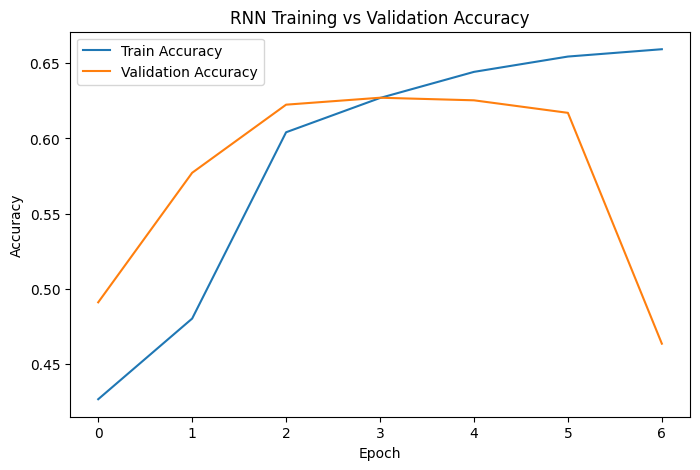

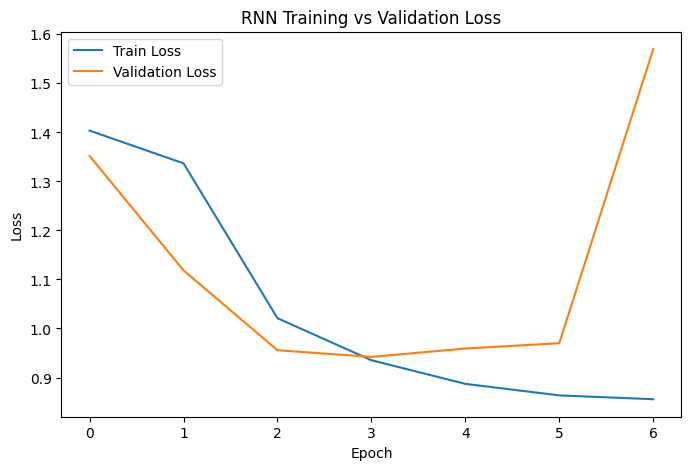

2785/2785 ━━━━━━━━━━━━━━━━━━━━ 24s 9ms/step

Test Predictions Preview:
   ID  predicted_rating
0   1                 4
1   2                 4
2   3                 4
3   4                 4
4   5                 4

Saved file: rnn_test_predictions.csv


In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

#Loading the data
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

print("Train columns:", train_df.columns.tolist())

print("Test columns:", test_df.columns.tolist())


TRAIN_TEXT_COL = "text"
TARGET_COL = "rating"
TEST_ID_COL = "Id"
TEST_TEXT_COL = "text"

#Cleaning the text

def clean_text(text):
    text = str(text).lower()
    # remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    # keep letters only
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    # remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()
    return text



train_df[TRAIN_TEXT_COL] = train_df[TRAIN_TEXT_COL].fillna("").apply(clean_text)
test_df[TEST_TEXT_COL] = test_df[TEST_TEXT_COL].fillna("").apply(clean_text)

#Removing empty texts
train_df = train_df[train_df[TRAIN_TEXT_COL].str.len() > 0].copy()
test_df = test_df[test_df[TEST_TEXT_COL].str.len() > 0].copy()



#Encode labels from train
label_encoder = LabelEncoder()
train_df[TARGET_COL] = label_encoder.fit_transform(train_df[TARGET_COL])




#Train and validation spliting the dataset
X_train, X_val, y_train, y_val = train_test_split(
    train_df[TRAIN_TEXT_COL],
    train_df[TARGET_COL],
    test_size=0.2,
    random_state=42,
    stratify=train_df[TARGET_COL]
)




#Tokenization and padding

max_vocab = 20000
max_len = 100

tokenizer = Tokenizer(num_words=max_vocab, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(test_df[TEST_TEXT_COL])

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding="post", truncating="post")
X_val_pad = pad_sequences(X_val_seq, maxlen=max_len, padding="post", truncating="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding="post", truncating="post")

y_train = np.array(y_train)
y_val = np.array(y_val)




#Building the RNN model
model = Sequential([
    Embedding(input_dim=max_vocab, output_dim=128, input_length=max_len),
    SimpleRNN(64, activation="tanh"),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dense(5, activation="softmax")
])


model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()



#Training the model
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

#Evaluate on validation set
y_val_probs = model.predict(X_val_pad)
y_val_pred = np.argmax(y_val_probs, axis=1)



print("\nValidation Accuracy:", accuracy_score(y_val, y_val_pred))
print("Validation Macro F1:", f1_score(y_val, y_val_pred, average="macro"))

print("\nClassification Report:\n")
print(classification_report(
    y_val,
    y_val_pred,
    target_names=[str(c) for c in label_encoder.classes_]
))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_val, y_val_pred))



#Plot training output
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("RNN Training vs Validation Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("RNN Training vs Validation Loss")
plt.legend()
plt.show()



#Prediction of test reviews

test_probs = model.predict(X_test_pad)
test_pred_encoded = np.argmax(test_probs, axis=1)
test_pred_labels = label_encoder.inverse_transform(test_pred_encoded)

predictions_df = pd.DataFrame({
    "ID": test_df[TEST_ID_COL],
    "predicted_rating": test_pred_labels
})

print("\nTest Predictions Preview:")
print(predictions_df.head())

predictions_df.to_csv("rnn_test_predictions.csv", index=False)
print("\nSaved file: rnn_test_predictions.csv")

## Results

- Training accuracy had a steady increase from ~42% in the first epoch to ~65% by later epochs
- Validation accuracy improved consistently up to ~62.7%, after which it plateaued and slightly declined, suggesting the onset of overfitting.

The final evaluation on the validation set got:
- Accuracy: 62.71%
- Macro F1-score: 0.41

The macro F1-score reveals a significant imbalance in class-wise performance. The model performs well on majority classes like ratings 1 and 4, achieving high recall values (0.93 and 0.81 respectively). But, it struggles considerably with minority classes, like ratings 2 and 3, where recall is extremely low.

The confusion matrix add to this by showing that many samples from underrepresented classes are misclassified into dominant classes.

Shown below is the class imbalance of the dataset.

In [ ]:
print(pd.Series(test_pred_labels).value_counts().sort_index())

1    26513
2      383
3     4801
4    52661
5     4734
Name: count, dtype: int64


## More Balanced RNN

This version improves upon the previous one by incorporating label distribution analysis and applying class weights during training to handle imbalanced data


Train shape: (288000, 2)
Test shape: (89100, 2)
Train columns: ['text', 'rating']
Test columns: ['Id', 'text']

After cleaning:
Train shape: (287957, 2)
Test shape: (89092, 2)

Training label distribution:
rating
1    109567
2     32212
3     35323
4     82055
5     28800
Name: count, dtype: int64


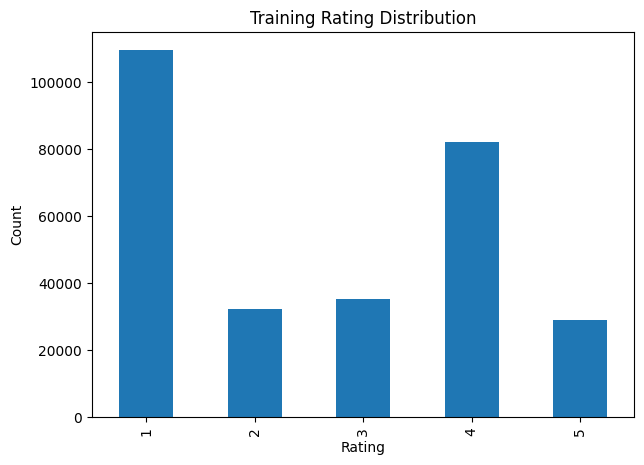


Original classes: [1 2 3 4 5]

Train size: 230365
Validation size: 57592

Padded training shape: (230365, 100)
Padded validation shape: (57592, 100)
Padded test shape: (89092, 100)

Class weights:
{np.int64(0): np.float64(0.5256294707539959), np.int64(1): np.float64(1.7878540939076446), np.int64(2): np.float64(1.630440937079765), np.int64(3): np.float64(0.7018615562732313), np.int64(4): np.float64(1.9996961805555555)}

Model Summary:


c:\Users\Shaji\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
3600/3600 ━━━━━━━━━━━━━━━━━━━━ 161s 44ms/step - accuracy: 0.2729 - loss: 1.5806 - val_accuracy: 0.3667 - val_loss: 1.5767
Epoch 2/10
3600/3600 ━━━━━━━━━━━━━━━━━━━━ 142s 39ms/step - accuracy: 0.2575 - loss: 1.5778 - val_accuracy: 0.4133 - val_loss: 1.5220
Epoch 3/10
3600/3600 ━━━━━━━━━━━━━━━━━━━━ 165s 46ms/step - accuracy: 0.2825 - loss: 1.5765 - val_accuracy: 0.3704 - val_loss: 1.5590
Epoch 4/10
3600/3600 ━━━━━━━━━━━━━━━━━━━━ 165s 46ms/step - accuracy: 0.2713 - loss: 1.5778 - val_accuracy: 0.1847 - val_loss: 1.5675

Validation Accuracy: 0.4132692040561189
Validation Macro F1: 0.2116616815537266

Classification Report:

              precision    recall  f1-score   support

           1       0.45      0.68      0.54     21914
           2       0.17      0.05      0.08      6442
           3       0.00      0.00      0.00      7065
           4       0.38      0.52      0.44     16411
           5       0.36      0.00      0.00      5760

    accuracy                        

c:\Users\Shaji\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Shaji\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Shaji\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

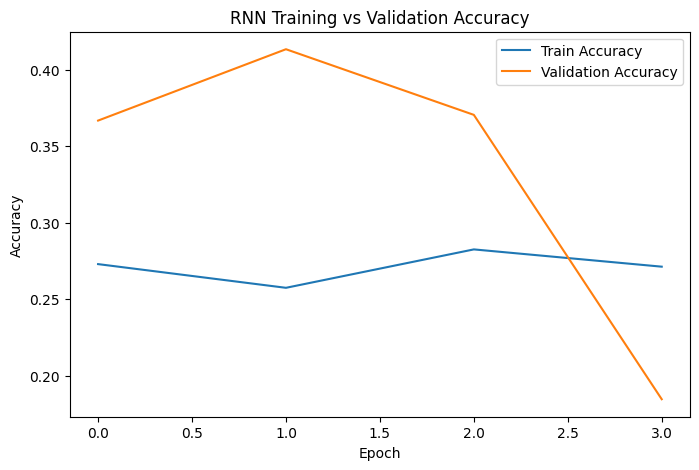

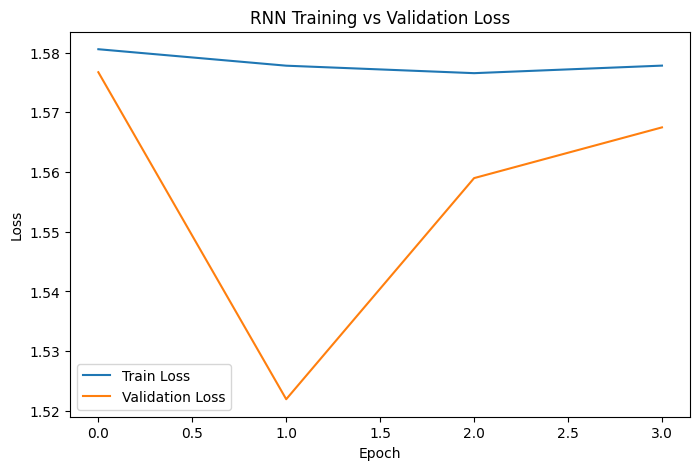

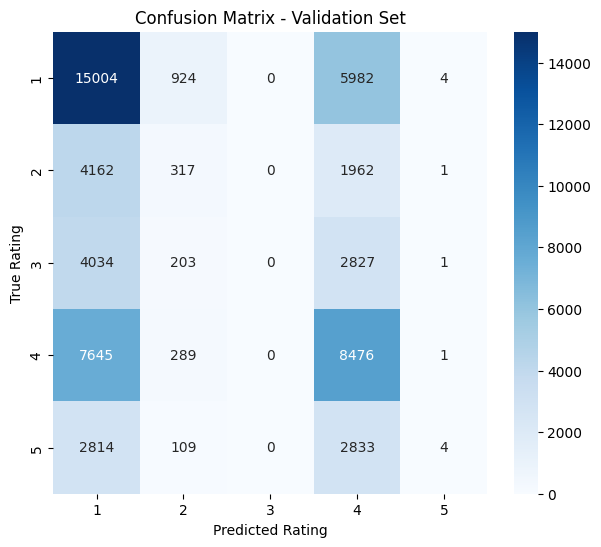


Validation prediction counts:
1    33659
2     1842
4    22080
5       11
Name: count, dtype: int64

Test prediction distribution:
1    43980
2     2545
4    42550
5       17
Name: count, dtype: int64

Test Predictions Preview:
   Id  predicted_rating
0   1                 4
1   2                 4
2   3                 4
3   4                 1
4   5                 2

Saved file: rnn_test_predictions.csv


In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping



#Loading datasets
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Train columns:", train_df.columns.tolist())
print("Test columns:", test_df.columns.tolist())

TRAIN_TEXT_COL = "text"
TARGET_COL = "rating"
TEST_TEXT_COL = "text"
TEST_ID_COL = "Id"



#Text cleaning
def clean_text(text):
    text = str(text).lower()
    # remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    # remove HTML tags
    text = re.sub(r"<.*?>", " ", text)
    # keep letters only
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    # remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()
    return text

train_df[TRAIN_TEXT_COL] = train_df[TRAIN_TEXT_COL].fillna("").apply(clean_text)
test_df[TEST_TEXT_COL] = test_df[TEST_TEXT_COL].fillna("").apply(clean_text)



#Remove empty rows if any
train_df = train_df[train_df[TRAIN_TEXT_COL].str.len() > 0].copy()
test_df = test_df[test_df[TEST_TEXT_COL].str.len() > 0].copy()

print("\nAfter cleaning:")
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)



#Label distribution
print("\nTraining label distribution:")
print(train_df[TARGET_COL].value_counts().sort_index())

plt.figure(figsize=(7, 5))
train_df[TARGET_COL].value_counts().sort_index().plot(kind="bar")
plt.title("Training Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

#Encode labels
label_encoder = LabelEncoder()
train_df[TARGET_COL] = label_encoder.fit_transform(train_df[TARGET_COL])

print("\nOriginal classes:", label_encoder.classes_)




#Train-validation split
X_train, X_val, y_train, y_val = train_test_split(

    train_df[TRAIN_TEXT_COL],
    train_df[TARGET_COL],
    test_size=0.2,
    random_state=42,
    stratify=train_df[TARGET_COL]
)

print("\nTrain size:", len(X_train))
print("Validation size:", len(X_val))



#Tokenization and padding
max_vocab = 20000
max_len = 100

tokenizer = Tokenizer(num_words=max_vocab, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(test_df[TEST_TEXT_COL])

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding="post", truncating="post")
X_val_pad = pad_sequences(X_val_seq, maxlen=max_len, padding="post", truncating="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding="post", truncating="post")

y_train = np.array(y_train)
y_val = np.array(y_val)

print("\nPadded training shape:", X_train_pad.shape)
print("Padded validation shape:", X_val_pad.shape)
print("Padded test shape:", X_test_pad.shape)



#Computing class weights
classes = np.unique(y_train)
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)
class_weight_dict = dict(zip(classes, class_weights))

print("\nClass weights:")
print(class_weight_dict)




#Building the RNN model
model = Sequential([
    Embedding(input_dim=max_vocab, output_dim=128, input_length=max_len),
    SimpleRNN(64, activation="tanh"),
    Dropout(0.4),
    Dense(64, activation="relu"),
    Dense(5, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("\nModel Summary:")
model.summary()

#Callbacks
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

#Training the model
history = model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=64,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)



#Validation predictions
y_val_probs = model.predict(X_val_pad, verbose=0)
y_val_pred = np.argmax(y_val_probs, axis=1)

val_accuracy = accuracy_score(y_val, y_val_pred)
val_macro_f1 = f1_score(y_val, y_val_pred, average="macro")

print("\nValidation Accuracy:", val_accuracy)
print("Validation Macro F1:", val_macro_f1)

print("\nClassification Report:\n")
print(
    classification_report(
        y_val,
        y_val_pred,
        target_names=[str(c) for c in label_encoder.classes_]
    )
)

cm = confusion_matrix(y_val, y_val_pred)
print("\nConfusion Matrix:\n")
print(cm)

#Plot outputs
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("RNN Training vs Validation Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("RNN Training vs Validation Loss")
plt.legend()
plt.show()

#Confusion matrix
plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title("Confusion Matrix - Validation Set")
plt.xlabel("Predicted Rating")
plt.ylabel("True Rating")
plt.show()


#Validation prediction distribution
val_pred_labels = label_encoder.inverse_transform(y_val_pred)
print("\nValidation prediction counts:")
print(pd.Series(val_pred_labels).value_counts().sort_index())



#Predict on test set
test_probs = model.predict(X_test_pad, verbose=0)
test_pred_encoded = np.argmax(test_probs, axis=1)
test_pred_labels = label_encoder.inverse_transform(test_pred_encoded)


print("\nTest prediction distribution:")
print(pd.Series(test_pred_labels).value_counts().sort_index())



#Save test predictions
predictions_df = pd.DataFrame({
    TEST_ID_COL: test_df[TEST_ID_COL],
    "predicted_rating": test_pred_labels
})

print("\nTest Predictions Preview:")
print(predictions_df.head())

predictions_df.to_csv("rnn_test_predictions.csv", index=False)
print("\nSaved file: rnn_test_predictions.csv")

## Results
As we can see, the improved model is doing significantly worse, achieving only 41.3% accuracy and a macro F1-score of 0.21.

Some classes like ratings 3 and 5 were not predicted at all.

This shows that while class weighting was intended to address imbalance, it destabilized training and caused the model to fail in learning meaningful patterns.

The confusion matrix also confirms this heavy bias toward a few classes.

# BERT Implementation
This task implements BERT-based transformer model for review rating prediction.

The pipeline includes:
- data loading
- light text preprocessing
- label encoding
- train-validation splitting
- tokenization
- model training
- evaluation
- test prediction

Class weights are incorporated to reduce the effect of label imbalance.

Finally, performance is measured using accuracy, macro F1-score, classification report, and confusion matrix.

## num_train_epochs=2 Implementation
We start of with considering a max length of 128 for the text, and train with a learning rate of 2e-5 and 2 epochs.

In [ ]:
import os
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
from google.colab import files

import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)


SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)


print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No GPU found")

#Upload files
drive.mount('/content/drive')

TRAIN_PATH = "/content/drive/MyDrive/Colab/train.csv"
TEST_PATH = "/content/drive/MyDrive/Colab/test.csv"


#Load datasets
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Train columns:", train_df.columns.tolist())
print("Test columns:", test_df.columns.tolist())


CUDA available: True
GPU: Tesla T4
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train shape: (288000, 2)
Test shape: (89100, 2)
Train columns: ['text', 'rating']
Test columns: ['Id', 'text']



After cleaning:
Train shape: (288000, 2)
Test shape: (89100, 2)

Training rating distribution:
rating
1    109583
2     32218
3     35326
4     82073
5     28800
Name: count, dtype: int64


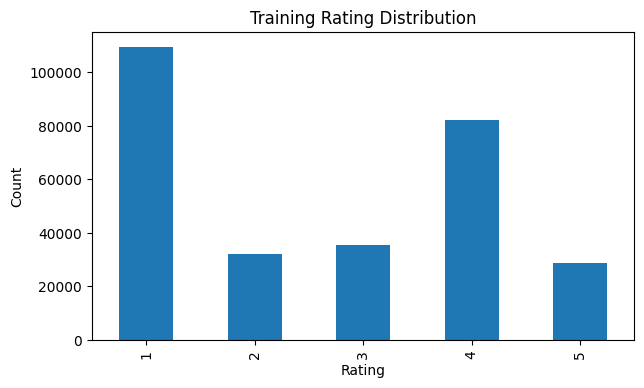


Review length summary:
count    288000.000000
mean         58.695309
std          80.353561
min           1.000000
25%          12.000000
50%          32.000000
75%          72.000000
max        1533.000000
Name: review_length_words, dtype: float64


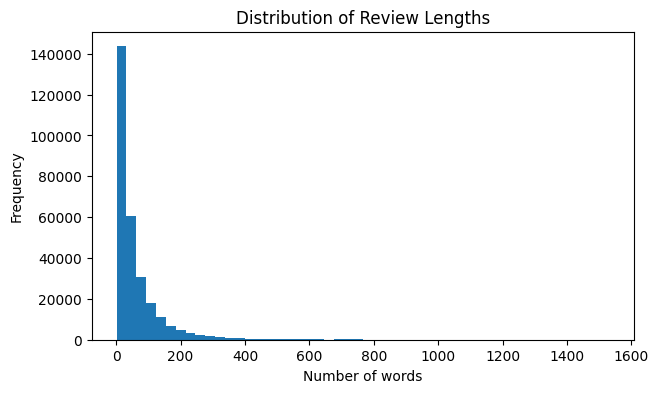


Encoded classes: [1 2 3 4 5]

Train size: 230400
Validation size: 57600

Class weights:
{0: 0.5256313736226131, 1: 1.7877788554801164, 2: 1.6305155514666856, 3: 0.7018185141186146, 4: 2.0}


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.927654,0.868680,0.672083,0.608212
2,0.753458,0.894827,0.678003,0.612568


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


Validation Accuracy: 0.6780034722222222
Validation Macro F1: 0.6125681985939928

Classification Report:

              precision    recall  f1-score   support

           1       0.86      0.80      0.83     21917
           2       0.36      0.46      0.41      6443
           3       0.43      0.47      0.45      7065
           4       0.76      0.67      0.71     16415
           5       0.60      0.75      0.67      5760

    accuracy                           0.68     57600
   macro avg       0.60      0.63      0.61     57600
weighted avg       0.70      0.68      0.69     57600


Confusion Matrix:
 [[17547  3386   755   171    58]
 [ 2008  2960  1261   186    28]
 [  533  1446  3292  1697    97]
 [  205   332  2222 10933  2723]
 [   33    13    73  1320  4321]]


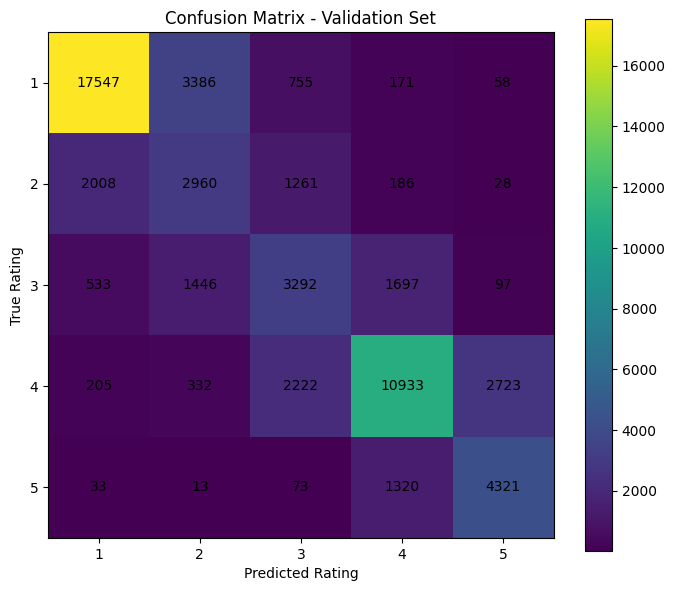


Validation prediction counts:
1    20326
2     8137
3     7603
4    14307
5     7227
Name: count, dtype: int64



Test prediction distribution:
1    12405
2    10982
3    17360
4    38374
5     9979
Name: count, dtype: int64

Test Predictions Preview:
   Id  Rating
0   1       4
1   2       4
2   3       4
3   4       2
4   5       5


OSError: Cannot save file into a non-existent directory: '/content/drive/MyDrive/Colab Notebooks'

In [ ]:

#Define column names
TRAIN_TEXT_COL = "text"
TARGET_COL = "rating"
TEST_ID_COL = "Id"
TEST_TEXT_COL = "text"

#Basic preprocessing for transformer
def clean_text(text):
    text = str(text).strip().lower()
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

train_df[TRAIN_TEXT_COL] = train_df[TRAIN_TEXT_COL].fillna("").apply(clean_text)
test_df[TEST_TEXT_COL] = test_df[TEST_TEXT_COL].fillna("").apply(clean_text)

#Remove empty rows
train_df = train_df[train_df[TRAIN_TEXT_COL].str.len() > 0].copy()
test_df = test_df[test_df[TEST_TEXT_COL].str.len() > 0].copy()

print("\nAfter cleaning:")
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

#Data exploration
print("\nTraining rating distribution:")
print(train_df[TARGET_COL].value_counts().sort_index())

plt.figure(figsize=(7, 4))
train_df[TARGET_COL].value_counts().sort_index().plot(kind="bar")
plt.title("Training Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

#Review length analysis
train_df["review_length_words"] = train_df[TRAIN_TEXT_COL].apply(lambda x: len(x.split()))
print("\nReview length summary:")
print(train_df["review_length_words"].describe())

plt.figure(figsize=(7, 4))
plt.hist(train_df["review_length_words"], bins=50)
plt.title("Distribution of Review Lengths")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.show()

#Encoding labels
label_encoder = LabelEncoder()
train_df[TARGET_COL] = label_encoder.fit_transform(train_df[TARGET_COL])

print("\nEncoded classes:", label_encoder.classes_)


#Train-validation split
X_train, X_val, y_train, y_val = train_test_split(
    train_df[TRAIN_TEXT_COL],
    train_df[TARGET_COL],
    test_size=0.2,
    random_state=SEED,
    stratify=train_df[TARGET_COL]
)

print("\nTrain size:", len(X_train))
print("Validation size:", len(X_val))

#Class weights to handle imbalanced classes
classes = np.unique(y_train)
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)
class_weight_dict = {int(c): float(w) for c, w in zip(classes, class_weights)}
print("\nClass weights:")
print(class_weight_dict)

#Building Hugging Face datasets
train_hf = Dataset.from_dict({
    "text": X_train.tolist(),
    "label": y_train.tolist()
})

val_hf = Dataset.from_dict({
    "text": X_val.tolist(),
    "label": y_val.tolist()
})

test_hf = Dataset.from_dict({
    "text": test_df[TEST_TEXT_COL].tolist()
})

#Tokenizer
MODEL_NAME = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

MAX_LENGTH = 128

def tokenize_function(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH
    )

train_hf = train_hf.map(tokenize_function, batched=True)
val_hf = val_hf.map(tokenize_function, batched=True)
test_hf = test_hf.map(tokenize_function, batched=True)

train_hf.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
val_hf.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
test_hf.set_format(type="torch", columns=["input_ids", "attention_mask"])

#Weighted Trainer
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(
            input_ids=inputs.get("input_ids"),
            attention_mask=inputs.get("attention_mask")
        )
        logits = outputs.get("logits")

        weight_tensor = torch.tensor(
            [class_weight_dict[i] for i in range(len(class_weight_dict))],
            dtype=torch.float
        ).to(logits.device)

        loss_fct = torch.nn.CrossEntropyLoss(weight=weight_tensor)
        loss = loss_fct(logits.view(-1, model.config.num_labels), labels.view(-1))

        return (loss, outputs) if return_outputs else loss

#Loading model
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=5
)

#Training arguments
training_args = TrainingArguments(
    output_dir="./bert_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=100,
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    report_to="none",
    fp16=torch.cuda.is_available(),
    seed=SEED
)

#Metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    acc = accuracy_score(labels, preds)
    macro_f1 = f1_score(labels, preds, average="macro")

    return {
        "accuracy": acc,
        "macro_f1": macro_f1
    }

#Trainer
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_hf,
    eval_dataset=val_hf,
    processing_class=tokenizer,
    compute_metrics=compute_metrics
)

#Training
train_result = trainer.train()

#Evaluating on validation set
val_output = trainer.predict(val_hf)
y_val_pred = np.argmax(val_output.predictions, axis=1)

val_accuracy = accuracy_score(y_val, y_val_pred)
val_macro_f1 = f1_score(y_val, y_val_pred, average="macro")

print("\nValidation Accuracy:", val_accuracy)
print("Validation Macro F1:", val_macro_f1)

print("\nClassification Report:\n")
print(classification_report(
    y_val,
    y_val_pred,
    target_names=[str(c) for c in label_encoder.classes_]
))

cm = confusion_matrix(y_val, y_val_pred)
print("\nConfusion Matrix:\n", cm)

#Confusion matrix
plt.figure(figsize=(7, 6))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix - Validation Set")
plt.colorbar()
tick_marks = np.arange(len(label_encoder.classes_))
plt.xticks(tick_marks, label_encoder.classes_)
plt.yticks(tick_marks, label_encoder.classes_)
plt.xlabel("Predicted Rating")
plt.ylabel("True Rating")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

#Validation prediction distribution
val_pred_labels = label_encoder.inverse_transform(y_val_pred)
print("\nValidation prediction counts:")
print(pd.Series(val_pred_labels).value_counts().sort_index())

#Predict test set
test_output = trainer.predict(test_hf)
test_pred_encoded = np.argmax(test_output.predictions, axis=1)
test_pred_labels = label_encoder.inverse_transform(test_pred_encoded)

print("\nTest prediction distribution:")
print(pd.Series(test_pred_labels).value_counts().sort_index())



In [ ]:
#Save predictions
OUTPUT_PATH = "/content/drive/MyDrive/Colab/cw2_predictions.csv"


predictions_df = pd.DataFrame({
    "Id": test_df[TEST_ID_COL],
    "Rating": test_pred_labels
})

print("\nTest Predictions Preview:")
print(predictions_df.head())

#Save CSV
predictions_df.to_csv(OUTPUT_PATH, index=False)

print("Saved file to:", OUTPUT_PATH)

#Download file
from google.colab import files
files.download(OUTPUT_PATH)


Test Predictions Preview:
   Id  Rating
0   1       4
1   2       4
2   3       4
3   4       2
4   5       5
Saved file to: /content/drive/MyDrive/Colab/cw2_predictions.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:


print("Prediction shape:", predictions_df.shape)

print("Prediction columns:", predictions_df.columns.tolist())


Prediction shape: (89100, 2)
Prediction columns: ['Id', 'Rating']


## num_train_epochs=3 Implementation
The below implementation is the same as the previous one, only that num_train_epochs=3, to see if the output improves


After cleaning:
Train shape: (288000, 2)
Test shape: (89100, 2)

Training rating distribution:
rating
1    109583
2     32218
3     35326
4     82073
5     28800
Name: count, dtype: int64


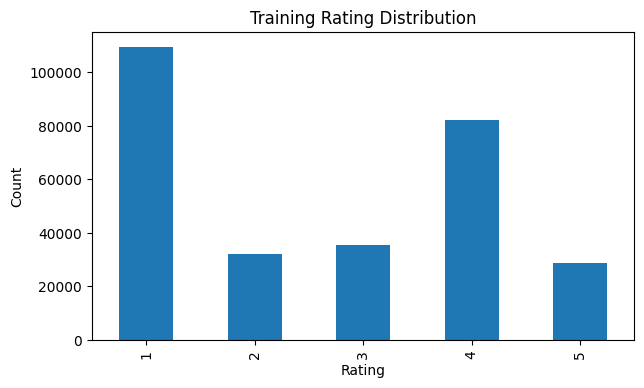


Review length summary:
count    288000.000000
mean         58.695309
std          80.353561
min           1.000000
25%          12.000000
50%          32.000000
75%          72.000000
max        1533.000000
Name: review_length_words, dtype: float64


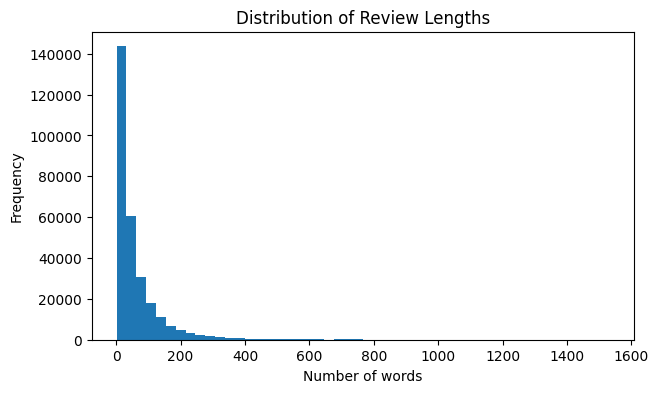


Encoded classes: [1 2 3 4 5]

Train size: 230400
Validation size: 57600

Class weights:
{0: 0.5256313736226131, 1: 1.7877788554801164, 2: 1.6305155514666856, 3: 0.7018185141186146, 4: 2.0}


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


Validation Accuracy: 0.6755034722222222
Validation Macro F1: 0.6062448995331382

Classification Report:

              precision    recall  f1-score   support

           1       0.86      0.81      0.83     21917
           2       0.36      0.40      0.38      6443
           3       0.42      0.49      0.45      7065
           4       0.76      0.66      0.71     16415
           5       0.59      0.75      0.66      5760

    accuracy                           0.68     57600
   macro avg       0.60      0.62      0.61     57600
weighted avg       0.69      0.68      0.68     57600


Confusion Matrix:
 [[17680  3025   924   228    60]
 [ 2101  2582  1511   217    32]
 [  539  1227  3439  1758   102]
 [  187   240  2279 10865  2844]
 [   30     8    81  1298  4343]]


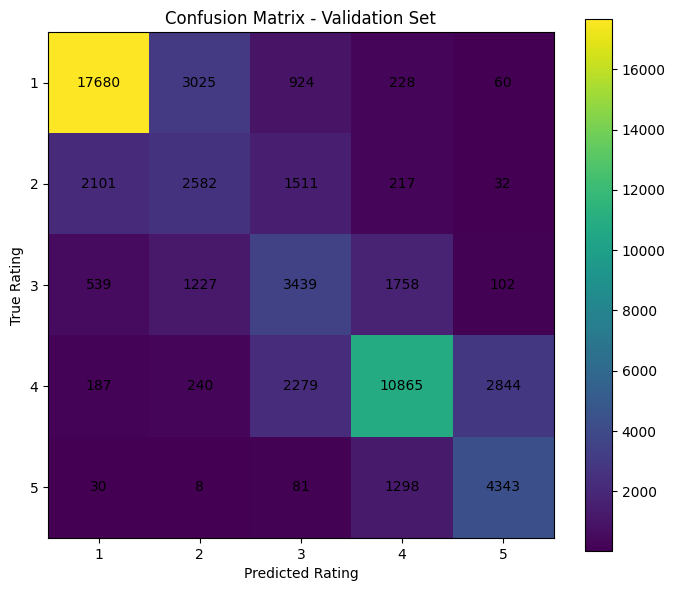


Validation prediction counts:
1    20537
2     7082
3     8234
4    14366
5     7381
Name: count, dtype: int64



Test prediction distribution:
1    12539
2     9432
3    18578
4    38636
5     9915
Name: count, dtype: int64

Test Predictions Preview:
   Id  Rating
0   1       4
1   2       4
2   3       4
3   4       2
4   5       4

Saved file: cw2_predictions.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:

#Define column names
TRAIN_TEXT_COL = "text"
TARGET_COL = "rating"
TEST_ID_COL = "Id"
TEST_TEXT_COL = "text"

#Basic preprocessing
def clean_text(text):
    text = str(text).strip().lower()
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

train_df[TRAIN_TEXT_COL] = train_df[TRAIN_TEXT_COL].fillna("").apply(clean_text)
test_df[TEST_TEXT_COL] = test_df[TEST_TEXT_COL].fillna("").apply(clean_text)

#Remove empty rows
train_df = train_df[train_df[TRAIN_TEXT_COL].str.len() > 0].copy()
test_df = test_df[test_df[TEST_TEXT_COL].str.len() > 0].copy()

print("\nAfter cleaning:")
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)



print("\nTraining rating distribution:")
print(train_df[TARGET_COL].value_counts().sort_index())

plt.figure(figsize=(7, 4))
train_df[TARGET_COL].value_counts().sort_index().plot(kind="bar")
plt.title("Training Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

#Review length analysis
train_df["review_length_words"] = train_df[TRAIN_TEXT_COL].apply(lambda x: len(x.split()))
print("\nReview length summary:")
print(train_df["review_length_words"].describe())

plt.figure(figsize=(7, 4))
plt.hist(train_df["review_length_words"], bins=50)
plt.title("Distribution of Review Lengths")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.show()

#Encode labels
label_encoder = LabelEncoder()
train_df[TARGET_COL] = label_encoder.fit_transform(train_df[TARGET_COL])

print("\nEncoded classes:", label_encoder.classes_)

#Train-validation split
X_train, X_val, y_train, y_val = train_test_split(
    train_df[TRAIN_TEXT_COL],
    train_df[TARGET_COL],
    test_size=0.2,
    random_state=SEED,
    stratify=train_df[TARGET_COL]
)

print("\nTrain size:", len(X_train))
print("Validation size:", len(X_val))

#Class weights
classes = np.unique(y_train)
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)
class_weight_dict = {int(c): float(w) for c, w in zip(classes, class_weights)}
print("\nClass weights:")
print(class_weight_dict)

#Building Hugging Face datasets
train_hf = Dataset.from_dict({
    "text": X_train.tolist(),
    "label": y_train.tolist()
})

val_hf = Dataset.from_dict({
    "text": X_val.tolist(),
    "label": y_val.tolist()
})

test_hf = Dataset.from_dict({
    "text": test_df[TEST_TEXT_COL].tolist()
})

#Tokenizer
MODEL_NAME = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

MAX_LENGTH = 128

def tokenize_function(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH
    )

train_hf = train_hf.map(tokenize_function, batched=True)
val_hf = val_hf.map(tokenize_function, batched=True)
test_hf = test_hf.map(tokenize_function, batched=True)

train_hf.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
val_hf.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
test_hf.set_format(type="torch", columns=["input_ids", "attention_mask"])

#Weighted Trainer
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(
            input_ids=inputs.get("input_ids"),
            attention_mask=inputs.get("attention_mask")
        )
        logits = outputs.get("logits")

        weight_tensor = torch.tensor(
            [class_weight_dict[i] for i in range(len(class_weight_dict))],
            dtype=torch.float
        ).to(logits.device)

        loss_fct = torch.nn.CrossEntropyLoss(weight=weight_tensor)
        loss = loss_fct(logits.view(-1, model.config.num_labels), labels.view(-1))

        return (loss, outputs) if return_outputs else loss

#Loading model
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=5
)

#Training arguments
training_args = TrainingArguments(
    output_dir="./bert_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=100,
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    report_to="none",
    fp16=torch.cuda.is_available(),
    seed=SEED
)

#Metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    acc = accuracy_score(labels, preds)
    macro_f1 = f1_score(labels, preds, average="macro")

    return {
        "accuracy": acc,
        "macro_f1": macro_f1
    }

#Trainer
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_hf,
    eval_dataset=val_hf,
    processing_class=tokenizer,
    compute_metrics=compute_metrics
)

#Training
train_result = trainer.train()

#Evaluate on validation set
val_output = trainer.predict(val_hf)
y_val_pred = np.argmax(val_output.predictions, axis=1)

val_accuracy = accuracy_score(y_val, y_val_pred)
val_macro_f1 = f1_score(y_val, y_val_pred, average="macro")

print("\nValidation Accuracy:", val_accuracy)
print("Validation Macro F1:", val_macro_f1)

print("\nClassification Report:\n")
print(classification_report(
    y_val,
    y_val_pred,
    target_names=[str(c) for c in label_encoder.classes_]
))

cm = confusion_matrix(y_val, y_val_pred)
print("\nConfusion Matrix:\n", cm)

#Plot confusion matrix
plt.figure(figsize=(7, 6))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix - Validation Set")
plt.colorbar()
tick_marks = np.arange(len(label_encoder.classes_))
plt.xticks(tick_marks, label_encoder.classes_)
plt.yticks(tick_marks, label_encoder.classes_)
plt.xlabel("Predicted Rating")
plt.ylabel("True Rating")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

#Validation prediction distribution
val_pred_labels = label_encoder.inverse_transform(y_val_pred)
print("\nValidation prediction counts:")
print(pd.Series(val_pred_labels).value_counts().sort_index())

#Predict test set
test_output = trainer.predict(test_hf)
test_pred_encoded = np.argmax(test_output.predictions, axis=1)
test_pred_labels = label_encoder.inverse_transform(test_pred_encoded)

print("\nTest prediction distribution:")
print(pd.Series(test_pred_labels).value_counts().sort_index())

#Save predictions
predictions_df = pd.DataFrame({
    "Id": test_df[TEST_ID_COL],
    "Rating": test_pred_labels
})

print("\nTest Predictions Preview:")
print(predictions_df.head())

# Save CSV
predictions_df.to_csv("cw2_predictions.csv", index=False)

print("\nSaved file: cw2_predictions.csv")

# Download file
from google.colab import files
files.download("cw2_predictions.csv")

In [ ]:
import os
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files

import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No GPU found")


drive.mount('/content/drive')

TRAIN_PATH = "/content/drive/MyDrive/Colab/train.csv"
TEST_PATH = "/content/drive/MyDrive/Colab/test.csv"


#Load datasets
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Train columns:", train_df.columns.tolist())
print("Test columns:", test_df.columns.tolist())


CUDA available: True
GPU: Tesla T4


Saving train.csv to train.csv
Saving test.csv to test.csv
Train shape: (288000, 2)
Test shape: (89100, 2)
Train columns: ['text', 'rating']
Test columns: ['Id', 'text']


## Comparing the outputs of both BERT runs
### 2 epoch implementation output:
- Validation Accuracy: 0.6780034722222222

- Validation Macro F1: 0.6125681985939928

### 3 epoch implementation output:

- Validation Accuracy: 0.6755034722222222

- Validation Macro F1: 0.6062448995331382

### Summary:
The 2 epoch run is overall better than the 3 epoch run.

Validation loss also increased from 0.895 to 1.007, suggesting that model started to overfit after epoch 2.

# RoBERTa and DeBERTa Implementations

We first experimented with DeBERTa whose training was with a balanced subset:
- Model: deberta-v3-base  
- Epochs: 2  
- Learning rate: 1.5e-5  
- Max length: 160  
- Training data: 40000 balanced subset
- Result: ~0.38 accuracy and ~0.11 macro F1

DeBERTa was unstable under this setup.

We then switched to RoBERTa with the same balanced configuration:
- Model: roberta-base  
- Epochs: 2  
- Learning rate: 1.5e-5  
- Max length: 160  
- Training data: 40000 balanced subset  
- Result: ~0.64 validation accuracy, ~0.59 macro F1  

This greatly improved performance and stability.

Next, we increased the dataset size to a 100k balanced subset and the sequence length to 192:
- Result: ~0.657 accuracy, ~0.60 macro F1  

This showed less of an improvement, but still an improvement none the less.

We then switched to a larger stratified subset of 120k samples with natural distribution:
- Model: roberta-base  
- Epochs: 3  
- Learning rate: 1e-5  
- Max length: 256  
- Result: 0.7173 accuracy, 0.608 macro F1 - this is our best performance

This shows us that preserving the real data distribution improved the performance.

Finally, in hopes of improving our performance, we enhanced this model using:
- Checkpoint ensembling for the last 3 checkpoints
- Multi-window inference from the start and end of the text

However the final run returned the same output as the previous 0.7173 accuracy and 0.608 macro F1

The code below is the implementation of the same:

In [ ]:
import os
import re
import gc
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)


SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No GPU found. In Colab: Runtime > Change runtime type > T4 GPU")

TRAIN_PATH = "train.csv"
TEST_PATH = "test.csv"

# Load data
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Train columns:", train_df.columns.tolist())
print("Test columns:", test_df.columns.tolist())

TRAIN_TEXT_COL = "text"
TARGET_COL = "rating"
TEST_ID_COL = "Id"
TEST_TEXT_COL = "text"

# Light preprocessing
def clean_text(text):
    text = str(text).strip()
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

train_df[TRAIN_TEXT_COL] = train_df[TRAIN_TEXT_COL].fillna("").apply(clean_text)
test_df[TEST_TEXT_COL] = test_df[TEST_TEXT_COL].fillna("").apply(clean_text)

train_df = train_df[train_df[TRAIN_TEXT_COL].str.len() > 0].copy()
test_df = test_df[test_df[TEST_TEXT_COL].str.len() > 0].copy()

before_dupes = len(train_df)
train_df = train_df.drop_duplicates(subset=[TRAIN_TEXT_COL, TARGET_COL]).reset_index(drop=True)
after_dupes = len(train_df)

print("\nRemoved duplicates:", before_dupes - after_dupes)
print("Train shape after cleaning:", train_df.shape)
print("Test shape after cleaning:", test_df.shape)


#Explore
print("\nOriginal training rating distribution:")
print(train_df[TARGET_COL].value_counts().sort_index())

plt.figure(figsize=(7, 4))
train_df[TARGET_COL].value_counts().sort_index().plot(kind="bar")
plt.title("Original Training Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

train_df["word_count"] = train_df[TRAIN_TEXT_COL].apply(lambda x: len(x.split()))
print("\nReview length summary:")
print(train_df["word_count"].describe())



#Encode labels
label_encoder = LabelEncoder()
train_df["label"] = label_encoder.fit_transform(train_df[TARGET_COL])

print("\nEncoded class mapping:")
for orig, enc in zip(label_encoder.classes_, range(len(label_encoder.classes_))):
    print(f"{orig} -> {enc}")

# Validation split
train_pool_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    random_state=SEED,
    stratify=train_df["label"]
)

print("\nTrain pool shape:", train_pool_df.shape)
print("Validation shape:", val_df.shape)

print("\nValidation distribution:")
print(val_df[TARGET_COL].value_counts().sort_index())

# large stratified training subset
TRAIN_SUBSET_SIZE = 120000

train_subset_df, _ = train_test_split(
    train_pool_df,
    train_size=TRAIN_SUBSET_SIZE,
    random_state=SEED,
    stratify=train_pool_df["label"]
)

print("\nStratified training subset shape:", train_subset_df.shape)
print("Stratified training subset distribution:")
print(train_subset_df[TARGET_COL].value_counts().sort_index())

plt.figure(figsize=(7, 4))
train_subset_df[TARGET_COL].value_counts().sort_index().plot(kind="bar")
plt.title(f"Stratified Training Subset ({TRAIN_SUBSET_SIZE} rows)")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

# Model/tokenizer configuration
MODEL_NAME = "roberta-base"
MAX_LENGTH = 256

print("\nUsing model:", MODEL_NAME)
print("Max length:", MAX_LENGTH)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Building HF datasets for training
train_hf = Dataset.from_dict({
    "text": train_subset_df[TRAIN_TEXT_COL].tolist(),
    "label": train_subset_df["label"].tolist()
})

val_hf = Dataset.from_dict({
    "text": val_df[TRAIN_TEXT_COL].tolist(),
    "label": val_df["label"].tolist()
})

def tokenize_train_val(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH
    )

print("\nTokenizing train set...")
train_hf = train_hf.map(tokenize_train_val, batched=True)

print("Tokenizing validation set...")
val_hf = val_hf.map(tokenize_train_val, batched=True)

train_hf.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
val_hf.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

# Model
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=5
)

# Metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro")
    }

# Training arguments save checkpoints every epoch
MODEL_OUTPUT_DIR = "model_output_one_run"

training_args = TrainingArguments(
    output_dir=MODEL_OUTPUT_DIR,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=3,
    logging_strategy="steps",
    logging_steps=100,
    learning_rate=1.0e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,
    num_train_epochs=3,
    warmup_steps=500,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
    report_to="none",
    fp16=False,
    seed=SEED
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_hf,
    eval_dataset=val_hf,
    processing_class=tokenizer,
    compute_metrics=compute_metrics
)

# Train
print("\nStarting training...")
trainer.train()
print("Training complete.")

# Evaluate on validation set
print("\nEvaluating on validation set...")
val_output = trainer.predict(val_hf)
y_val_true = val_df["label"].values
y_val_pred = np.argmax(val_output.predictions, axis=1)

val_accuracy = accuracy_score(y_val_true, y_val_pred)
val_macro_f1 = f1_score(y_val_true, y_val_pred, average="macro")

print("\nVALIDATION RESULTS\n")
print("Validation Accuracy:", round(val_accuracy, 4))
print("Validation Macro F1:", round(val_macro_f1, 4))

print("\nClassification Report:\n")
print(classification_report(
    y_val_true,
    y_val_pred,
    target_names=[str(c) for c in label_encoder.classes_]
))

cm = confusion_matrix(y_val_true, y_val_pred)
print("\nConfusion Matrix:\n", cm)

plt.figure(figsize=(7, 6))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix - Full Validation Set")
plt.colorbar()

tick_marks = np.arange(len(label_encoder.classes_))
plt.xticks(tick_marks, label_encoder.classes_)
plt.yticks(tick_marks, label_encoder.classes_)
plt.xlabel("Predicted Rating")
plt.ylabel("True Rating")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black")

plt.tight_layout()
plt.show()

# Build Test datasets for start-window and end-window inference
print("\nPreparing start/end window test datasets...")

PAD_ID = tokenizer.pad_token_id

def encode_start_window(text, tokenizer, max_length):
    enc = tokenizer(text, truncation=False, padding=False, add_special_tokens=True)
    ids = enc["input_ids"][:max_length]
    attn = [1] * len(ids)
    if len(ids) < max_length:
        pad_len = max_length - len(ids)
        ids = ids + [PAD_ID] * pad_len
        attn = attn + [0] * pad_len
    return ids, attn

def encode_end_window(text, tokenizer, max_length):
    enc = tokenizer(text, truncation=False, padding=False, add_special_tokens=True)
    ids_full = enc["input_ids"]
    if len(ids_full) > max_length:
        ids = ids_full[-max_length:]
    else:
        ids = ids_full
    attn = [1] * len(ids)
    if len(ids) < max_length:
        pad_len = max_length - len(ids)
        ids = ids + [PAD_ID] * pad_len
        attn = attn + [0] * pad_len
    return ids, attn

start_input_ids = []
start_attention_masks = []
end_input_ids = []
end_attention_masks = []

for text in test_df[TEST_TEXT_COL].tolist():
    ids_s, attn_s = encode_start_window(text, tokenizer, MAX_LENGTH)
    ids_e, attn_e = encode_end_window(text, tokenizer, MAX_LENGTH)

    start_input_ids.append(ids_s)
    start_attention_masks.append(attn_s)
    end_input_ids.append(ids_e)
    end_attention_masks.append(attn_e)

test_start_hf = Dataset.from_dict({
    "input_ids": start_input_ids,
    "attention_mask": start_attention_masks
})

test_end_hf = Dataset.from_dict({
    "input_ids": end_input_ids,
    "attention_mask": end_attention_masks
})

test_start_hf.set_format(type="torch", columns=["input_ids", "attention_mask"])
test_end_hf.set_format(type="torch", columns=["input_ids", "attention_mask"])

print("Start/end test datasets ready.")

# Find saved checkpoints
checkpoint_dirs = sorted([
    os.path.join(MODEL_OUTPUT_DIR, d)
    for d in os.listdir(MODEL_OUTPUT_DIR)
    if d.startswith("checkpoint-")
])

print("\nFound checkpoints:")
for c in checkpoint_dirs:
    print(c)

# Keep last 3 checkpoints only
checkpoint_dirs = checkpoint_dirs[-3:]

if len(checkpoint_dirs) == 0:
    raise ValueError("No checkpoints found.")

# Weights across checkpoints; epoch2 usually best, so weighted middle
if len(checkpoint_dirs) == 3:
    checkpoint_weights = np.array([0.2, 0.5, 0.3], dtype=np.float32)
elif len(checkpoint_dirs) == 2:
    checkpoint_weights = np.array([0.6, 0.4], dtype=np.float32)
else:
    checkpoint_weights = np.array([1.0], dtype=np.float32)

checkpoint_weights = checkpoint_weights / checkpoint_weights.sum()
print("\nCheckpoint weights:", checkpoint_weights)

# Weights for start/end windows
START_WEIGHT = 0.6
END_WEIGHT = 0.4

# Predict with checkpoint ensemble and multi-window inference
all_checkpoint_probs = []

for ckpt, ckpt_w in zip(checkpoint_dirs, checkpoint_weights):
    print(f"\nLoading checkpoint: {ckpt}")

    ckpt_model = AutoModelForSequenceClassification.from_pretrained(ckpt)
    pred_trainer = Trainer(model=ckpt_model)

    print("Predicting START window...")
    start_output = pred_trainer.predict(test_start_hf)
    start_probs = torch.nn.functional.softmax(
        torch.tensor(start_output.predictions), dim=1
    ).numpy()

    print("Predicting END window...")
    end_output = pred_trainer.predict(test_end_hf)
    end_probs = torch.nn.functional.softmax(
        torch.tensor(end_output.predictions), dim=1
    ).numpy()

    # combine windows for this checkpoint
    ckpt_probs = START_WEIGHT * start_probs + END_WEIGHT * end_probs

    # weighted checkpoint contribution
    all_checkpoint_probs.append(ckpt_w * ckpt_probs)

    del ckpt_model, pred_trainer, start_output, end_output, start_probs, end_probs, ckpt_probs
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# Final averaged probabilities
avg_probs = np.sum(all_checkpoint_probs, axis=0)

final_pred_encoded = np.argmax(avg_probs, axis=1)
final_pred_labels = label_encoder.inverse_transform(final_pred_encoded)

print("\nFinal test prediction counts:")
print(pd.Series(final_pred_labels).value_counts().sort_index())

# Save submission
OUTPUT_PATH = "cw2_one_run_checkpoint_window_ensemble.csv"

submission_df = pd.DataFrame({
    TEST_ID_COL: test_df[TEST_ID_COL],
    "predicted_rating": final_pred_labels
})

print("\nSubmission preview:")
print(submission_df.head())

submission_df.to_csv(OUTPUT_PATH, index=False)
print(f"\nSaved: {OUTPUT_PATH}")

#local probability save
PROBS_OUTPUT_PATH = "cw2_one_run_checkpoint_window_ensemble_probs.npy"
np.save(PROBS_OUTPUT_PATH, avg_probs)
print(f"Saved probabilities: {PROBS_OUTPUT_PATH}")

# Save plots
plt.figure(figsize=(7, 4))
train_df[TARGET_COL].value_counts().sort_index().plot(kind="bar")
plt.title("Original Training Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.tight_layout()

plt.close()

plt.figure(figsize=(7, 4))
train_subset_df[TARGET_COL].value_counts().sort_index().plot(kind="bar")
plt.title(f"Stratified Training Subset ({TRAIN_SUBSET_SIZE} rows)")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.tight_layout()

plt.close()

plt.figure(figsize=(7, 6))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix - Full Validation Set")
plt.colorbar()
plt.xticks(tick_marks, label_encoder.classes_)
plt.yticks(tick_marks, label_encoder.classes_)
plt.xlabel("Predicted Rating")
plt.ylabel("True Rating")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black")
plt.tight_layout()

plt.close()

Below is the output generated by the above code:

(venv311) PS C:\Users\dybal\Downloads\CW2> python train_model.py   
CUDA available: True
GPU: NVIDIA GeForce RTX 3050 Laptop GPU
Train shape: (288000, 2)
Test shape: (89100, 2)
Train columns: ['text', 'rating']
Test columns: ['Id', 'text']

Removed duplicates: 12
Train shape after cleaning: (287988, 2)
Test shape after cleaning: (89100, 2)

Original training rating distribution:
rating
1    109580
2     32218
3     35326
4     82064
5     28800
Name: count, dtype: int64

Review length summary:
count    287988.000000
mean         58.696932
std          80.354166
min           1.000000
25%          12.000000
50%          32.000000
75%          72.000000
max        1533.000000
Name: word_count, dtype: float64

Encoded class mapping:
1 -> 0
2 -> 1
3 -> 2
4 -> 3
5 -> 4

Train pool shape: (230390, 4)
Validation shape: (57598, 4)

Validation distribution:
rating
1    21916
2     6444
3     7065
4    16413
5     5760
Name: count, dtype: int64

Stratified training subset shape: (120000, 4)
Stratified training subset distribution:
rating
1    45660
2    13425
3    14720
4    34195
5    12000
Name: count, dtype: int64

Using model: roberta-base
Max length: 256
Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.

Tokenizing train set...
Map: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 120000/120000 [00:08<00:00, 14265.39 examples/s]
Tokenizing validation set...
Map: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 57598/57598 [00:04<00:00, 14350.78 examples/s]
Tokenizing test set...
Map: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 89100/89100 [00:06<00:00, 14732.24 examples/s]
Loading weights: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 197/197 [00:00<00:00, 7745.31it/s]
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     |
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED |
roberta.embeddings.position_ids | UNEXPECTED |
lm_head.dense.weight            | UNEXPECTED |
lm_head.layer_norm.weight       | UNEXPECTED |
lm_head.bias                    | UNEXPECTED |
lm_head.layer_norm.bias         | UNEXPECTED |
classifier.out_proj.bias        | MISSING    |
classifier.dense.weight         | MISSING    |
classifier.out_proj.weight      | MISSING    |
classifier.dense.bias           | MISSING    |

Notes:
- UNEXPECTED:   can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:      those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.

Starting training...
{'loss': '3.159', 'grad_norm': '3.036', 'learning_rate': '1.98e-06', 'epoch': '0.01333'}
{'loss': '2.914', 'grad_norm': '7.083', 'learning_rate': '3.98e-06', 'epoch': '0.02667'}                                                                                      
{'loss': '2.08', 'grad_norm': '15.79', 'learning_rate': '5.98e-06', 'epoch': '0.04'}                                                                                          
{'loss': '1.821', 'grad_norm': '17.18', 'learning_rate': '7.98e-06', 'epoch': '0.05333'}                                                                                      
{'loss': '1.739', 'grad_norm': '16.93', 'learning_rate': '9.98e-06', 'epoch': '0.06667'}                                                                                      
{'loss': '1.686', 'grad_norm': '16.26', 'learning_rate': '9.955e-06', 'epoch': '0.08'}                                                                                        
{'loss': '1.586', 'grad_norm': '14.23', 'learning_rate': '9.91e-06', 'epoch': '0.09333'}                                                                                      
{'loss': '1.557', 'grad_norm': '17.59', 'learning_rate': '9.864e-06', 'epoch': '0.1067'}                                                                                      
{'loss': '1.6', 'grad_norm': '13.56', 'learning_rate': '9.819e-06', 'epoch': '0.12'}                                                                                          
{'loss': '1.611', 'grad_norm': '9.241', 'learning_rate': '9.773e-06', 'epoch': '0.1333'}                                                                                      
{'loss': '1.734', 'grad_norm': '14.92', 'learning_rate': '9.728e-06', 'epoch': '0.1467'}                                                                                      
{'loss': '1.597', 'grad_norm': '17.64', 'learning_rate': '9.682e-06', 'epoch': '0.16'}                                                                                        
{'loss': '1.524', 'grad_norm': '11.58', 'learning_rate': '9.637e-06', 'epoch': '0.1733'}                                                                                      
{'loss': '1.632', 'grad_norm': '57.84', 'learning_rate': '9.591e-06', 'epoch': '0.1867'}                                                                                      
{'loss': '1.594', 'grad_norm': '11.15', 'learning_rate': '9.546e-06', 'epoch': '0.2'}                                                                                         
{'loss': '1.6', 'grad_norm': '10.97', 'learning_rate': '9.5e-06', 'epoch': '0.2133'}                                                                                          
{'loss': '1.61', 'grad_norm': '34.74', 'learning_rate': '9.455e-06', 'epoch': '0.2267'}                                                                                       
{'loss': '1.539', 'grad_norm': '9.729', 'learning_rate': '9.41e-06', 'epoch': '0.24'}                                                                                         
{'loss': '1.623', 'grad_norm': '16.28', 'learning_rate': '9.364e-06', 'epoch': '0.2533'}                                                                                      
{'loss': '1.584', 'grad_norm': '10.88', 'learning_rate': '9.319e-06', 'epoch': '0.2667'}                                                                                      
{'loss': '1.576', 'grad_norm': '12.44', 'learning_rate': '9.273e-06', 'epoch': '0.28'}                                                                                        
{'loss': '1.47', 'grad_norm': '10.66', 'learning_rate': '9.228e-06', 'epoch': '0.2933'}                                                                                       
{'loss': '1.583', 'grad_norm': '17.06', 'learning_rate': '9.182e-06', 'epoch': '0.3067'}                                                                                      
{'loss': '1.537', 'grad_norm': '15.04', 'learning_rate': '9.137e-06', 'epoch': '0.32'}                                                                                        
{'loss': '1.417', 'grad_norm': '12.4', 'learning_rate': '9.091e-06', 'epoch': '0.3333'}                                                                                       
{'loss': '1.571', 'grad_norm': '14.99', 'learning_rate': '9.046e-06', 'epoch': '0.3467'}                                                                                      
{'loss': '1.506', 'grad_norm': '11.54', 'learning_rate': '9e-06', 'epoch': '0.36'}                                                                                            
{'loss': '1.61', 'grad_norm': '12.52', 'learning_rate': '8.955e-06', 'epoch': '0.3733'}                                                                                       
{'loss': '1.539', 'grad_norm': '13.02', 'learning_rate': '8.91e-06', 'epoch': '0.3867'}                                                                                       
{'loss': '1.579', 'grad_norm': '13.07', 'learning_rate': '8.864e-06', 'epoch': '0.4'}                                                                                         
{'loss': '1.52', 'grad_norm': '24.95', 'learning_rate': '8.819e-06', 'epoch': '0.4133'}                                                                                       
{'loss': '1.556', 'grad_norm': '10.82', 'learning_rate': '8.773e-06', 'epoch': '0.4267'}                                                                                      
{'loss': '1.528', 'grad_norm': '12.14', 'learning_rate': '8.728e-06', 'epoch': '0.44'}                                                                                        
{'loss': '1.469', 'grad_norm': '16.88', 'learning_rate': '8.682e-06', 'epoch': '0.4533'}                                                                                      
{'loss': '1.546', 'grad_norm': '11.24', 'learning_rate': '8.637e-06', 'epoch': '0.4667'}                                                                                      
{'loss': '1.543', 'grad_norm': '8.607', 'learning_rate': '8.591e-06', 'epoch': '0.48'}                                                                                        
{'loss': '1.457', 'grad_norm': '11.35', 'learning_rate': '8.546e-06', 'epoch': '0.4933'}
{'loss': '1.527', 'grad_norm': '12.15', 'learning_rate': '8.5e-06', 'epoch': '0.5067'}                                                                                        
{'loss': '1.523', 'grad_norm': '12.75', 'learning_rate': '8.455e-06', 'epoch': '0.52'}                                                                                        
{'loss': '1.516', 'grad_norm': '19.29', 'learning_rate': '8.41e-06', 'epoch': '0.5333'}                                                                                       
{'loss': '1.535', 'grad_norm': '10.95', 'learning_rate': '8.364e-06', 'epoch': '0.5467'}                                                                                      
{'loss': '1.493', 'grad_norm': '11.11', 'learning_rate': '8.319e-06', 'epoch': '0.56'}                                                                                        
{'loss': '1.518', 'grad_norm': '9.342', 'learning_rate': '8.273e-06', 'epoch': '0.5733'}                                                                                      
{'loss': '1.516', 'grad_norm': '10.13', 'learning_rate': '8.228e-06', 'epoch': '0.5867'}                                                                                      
{'loss': '1.454', 'grad_norm': '10.06', 'learning_rate': '8.182e-06', 'epoch': '0.6'}                                                                                         
{'loss': '1.571', 'grad_norm': '13.04', 'learning_rate': '8.137e-06', 'epoch': '0.6133'}                                                                                      
{'loss': '1.489', 'grad_norm': '7.271', 'learning_rate': '8.091e-06', 'epoch': '0.6267'}                                                                                      
{'loss': '1.519', 'grad_norm': '12.51', 'learning_rate': '8.046e-06', 'epoch': '0.64'}                                                                                        
{'loss': '1.464', 'grad_norm': '12.43', 'learning_rate': '8e-06', 'epoch': '0.6533'}                                                                                          
{'loss': '1.43', 'grad_norm': '12.76', 'learning_rate': '7.955e-06', 'epoch': '0.6667'}                                                                                       
{'loss': '1.503', 'grad_norm': '18.85', 'learning_rate': '7.91e-06', 'epoch': '0.68'}                                                                                         
{'loss': '1.524', 'grad_norm': '11.03', 'learning_rate': '7.864e-06', 'epoch': '0.6933'}                                                                                      
{'loss': '1.496', 'grad_norm': '6.646', 'learning_rate': '7.819e-06', 'epoch': '0.7067'}                                                                                      
{'loss': '1.496', 'grad_norm': '8.033', 'learning_rate': '7.773e-06', 'epoch': '0.72'}                                                                                        
{'loss': '1.485', 'grad_norm': '13.73', 'learning_rate': '7.728e-06', 'epoch': '0.7333'}                                                                                      
{'loss': '1.499', 'grad_norm': '16.69', 'learning_rate': '7.682e-06', 'epoch': '0.7467'}                                                                                      
{'loss': '1.53', 'grad_norm': '14.35', 'learning_rate': '7.637e-06', 'epoch': '0.76'}                                                                                         
{'loss': '1.45', 'grad_norm': '11.32', 'learning_rate': '7.591e-06', 'epoch': '0.7733'}                                                                                       
{'loss': '1.459', 'grad_norm': '9.762', 'learning_rate': '7.546e-06', 'epoch': '0.7867'}                                                                                      
{'loss': '1.501', 'grad_norm': '12.05', 'learning_rate': '7.5e-06', 'epoch': '0.8'}                                                                                           
{'loss': '1.507', 'grad_norm': '14.62', 'learning_rate': '7.455e-06', 'epoch': '0.8133'}                                                                                      
{'loss': '1.471', 'grad_norm': '14.75', 'learning_rate': '7.41e-06', 'epoch': '0.8267'}                                                                                       
{'loss': '1.503', 'grad_norm': '14.14', 'learning_rate': '7.364e-06', 'epoch': '0.84'}                                                                                        
{'loss': '1.484', 'grad_norm': '10.31', 'learning_rate': '7.319e-06', 'epoch': '0.8533'}                                                                                      
{'loss': '1.409', 'grad_norm': '8.746', 'learning_rate': '7.273e-06', 'epoch': '0.8667'}                                                                                      
{'loss': '1.501', 'grad_norm': '20.03', 'learning_rate': '7.228e-06', 'epoch': '0.88'}                                                                                        
{'loss': '1.475', 'grad_norm': '10.35', 'learning_rate': '7.182e-06', 'epoch': '0.8933'}                                                                                      
{'loss': '1.476', 'grad_norm': '18.41', 'learning_rate': '7.137e-06', 'epoch': '0.9067'}                                                                                      
{'loss': '1.496', 'grad_norm': '14.42', 'learning_rate': '7.091e-06', 'epoch': '0.92'}                                                                                        
{'loss': '1.47', 'grad_norm': '22.82', 'learning_rate': '7.046e-06', 'epoch': '0.9333'}                                                                                       
{'loss': '1.44', 'grad_norm': '13.92', 'learning_rate': '7e-06', 'epoch': '0.9467'}                                                                                           
{'loss': '1.491', 'grad_norm': '15.15', 'learning_rate': '6.955e-06', 'epoch': '0.96'}                                                                                        
{'loss': '1.466', 'grad_norm': '12.84', 'learning_rate': '6.91e-06', 'epoch': '0.9733'}                                                                                       
{'loss': '1.471', 'grad_norm': '17.13', 'learning_rate': '6.864e-06', 'epoch': '0.9867'}                                                                                      
{'loss': '1.527', 'grad_norm': '14.28', 'learning_rate': '6.819e-06', 'epoch': '1'}                                                                                           
{'eval_loss': '0.7374', 'eval_accuracy': '0.7068', 'eval_macro_f1': '0.5831', 'eval_runtime': '997.9', 'eval_samples_per_second': '57.72', 'eval_steps_per_second': '7.215', 'epoch': '1'}
Writing model shards: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  2.14it/s]
{'loss': '1.436', 'grad_norm': '5.153', 'learning_rate': '6.773e-06', 'epoch': '1.013'}
{'loss': '1.347', 'grad_norm': '10.76', 'learning_rate': '6.728e-06', 'epoch': '1.027'}                                                                                       
{'loss': '1.325', 'grad_norm': '7.882', 'learning_rate': '6.682e-06', 'epoch': '1.04'}                                                                                        
{'loss': '1.357', 'grad_norm': '17.19', 'learning_rate': '6.637e-06', 'epoch': '1.053'}                                                                                       
{'loss': '1.392', 'grad_norm': '18.2', 'learning_rate': '6.591e-06', 'epoch': '1.067'}                                                                                        
{'loss': '1.398', 'grad_norm': '12.37', 'learning_rate': '6.546e-06', 'epoch': '1.08'}                                                                                        
{'loss': '1.385', 'grad_norm': '22.15', 'learning_rate': '6.5e-06', 'epoch': '1.093'}                                                                                         
{'loss': '1.405', 'grad_norm': '12.11', 'learning_rate': '6.455e-06', 'epoch': '1.107'}                                                                                       
{'loss': '1.43', 'grad_norm': '11.5', 'learning_rate': '6.41e-06', 'epoch': '1.12'}                                                                                           
{'loss': '1.379', 'grad_norm': '8.422', 'learning_rate': '6.364e-06', 'epoch': '1.133'}                                                                                       
{'loss': '1.354', 'grad_norm': '16.84', 'learning_rate': '6.319e-06', 'epoch': '1.147'}                                                                                       
{'loss': '1.414', 'grad_norm': '15.11', 'learning_rate': '6.273e-06', 'epoch': '1.16'}                                                                                        
{'loss': '1.388', 'grad_norm': '21.23', 'learning_rate': '6.228e-06', 'epoch': '1.173'}                                                                                       
{'loss': '1.452', 'grad_norm': '10.41', 'learning_rate': '6.182e-06', 'epoch': '1.187'}                                                                                       
{'loss': '1.335', 'grad_norm': '11.52', 'learning_rate': '6.137e-06', 'epoch': '1.2'}                                                                                         
{'loss': '1.363', 'grad_norm': '14.3', 'learning_rate': '6.091e-06', 'epoch': '1.213'}                                                                                        
{'loss': '1.381', 'grad_norm': '9.488', 'learning_rate': '6.046e-06', 'epoch': '1.227'}                                                                                       
{'loss': '1.387', 'grad_norm': '9.5', 'learning_rate': '6e-06', 'epoch': '1.24'}                                                                                              
{'loss': '1.37', 'grad_norm': '13.91', 'learning_rate': '5.955e-06', 'epoch': '1.253'}                                                                                        
{'loss': '1.313', 'grad_norm': '14.18', 'learning_rate': '5.91e-06', 'epoch': '1.267'}                                                                                        
{'loss': '1.395', 'grad_norm': '21.54', 'learning_rate': '5.864e-06', 'epoch': '1.28'}                                                                                        
{'loss': '1.433', 'grad_norm': '13.43', 'learning_rate': '5.819e-06', 'epoch': '1.293'}                                                                                       
{'loss': '1.363', 'grad_norm': '16.87', 'learning_rate': '5.773e-06', 'epoch': '1.307'}                                                                                       
{'loss': '1.403', 'grad_norm': '13.24', 'learning_rate': '5.728e-06', 'epoch': '1.32'}                                                                                        
{'loss': '1.357', 'grad_norm': '18.88', 'learning_rate': '5.682e-06', 'epoch': '1.333'}                                                                                       
{'loss': '1.395', 'grad_norm': '29.5', 'learning_rate': '5.637e-06', 'epoch': '1.347'}                                                                                        
{'loss': '1.354', 'grad_norm': '16.09', 'learning_rate': '5.591e-06', 'epoch': '1.36'}                                                                                        
{'loss': '1.407', 'grad_norm': '11.67', 'learning_rate': '5.546e-06', 'epoch': '1.373'}                                                                                       
{'loss': '1.362', 'grad_norm': '12.86', 'learning_rate': '5.5e-06', 'epoch': '1.387'}                                                                                         
{'loss': '1.366', 'grad_norm': '19.57', 'learning_rate': '5.455e-06', 'epoch': '1.4'}                                                                                         
{'loss': '1.344', 'grad_norm': '20.92', 'learning_rate': '5.41e-06', 'epoch': '1.413'}                                                                                        
{'loss': '1.312', 'grad_norm': '6.307', 'learning_rate': '5.364e-06', 'epoch': '1.427'}                                                                                       
{'loss': '1.382', 'grad_norm': '19.29', 'learning_rate': '5.319e-06', 'epoch': '1.44'}                                                                                        
{'loss': '1.353', 'grad_norm': '13.16', 'learning_rate': '5.273e-06', 'epoch': '1.453'}                                                                                       
{'loss': '1.351', 'grad_norm': '12.16', 'learning_rate': '5.228e-06', 'epoch': '1.467'}                                                                                       
{'loss': '1.317', 'grad_norm': '14.76', 'learning_rate': '5.182e-06', 'epoch': '1.48'}                                                                                        
{'loss': '1.378', 'grad_norm': '23.83', 'learning_rate': '5.137e-06', 'epoch': '1.493'}                                                                                       
{'loss': '1.352', 'grad_norm': '9.949', 'learning_rate': '5.091e-06', 'epoch': '1.507'}                                                                                       
{'loss': '1.384', 'grad_norm': '17.1', 'learning_rate': '5.046e-06', 'epoch': '1.52'}                                                                                         
{'loss': '1.373', 'grad_norm': '13.8', 'learning_rate': '5e-06', 'epoch': '1.533'}                                                                                            
{'loss': '1.385', 'grad_norm': '11.99', 'learning_rate': '4.955e-06', 'epoch': '1.547'}                                                                                       
{'loss': '1.282', 'grad_norm': '8.262', 'learning_rate': '4.91e-06', 'epoch': '1.56'}                                                                                         
{'loss': '1.303', 'grad_norm': '20.71', 'learning_rate': '4.864e-06', 'epoch': '1.573'}                                                                                       
{'loss': '1.399', 'grad_norm': '9.282', 'learning_rate': '4.819e-06', 'epoch': '1.587'}                                                                                       
{'loss': '1.349', 'grad_norm': '29.24', 'learning_rate': '4.773e-06', 'epoch': '1.6'}                                                                                         
{'loss': '1.41', 'grad_norm': '12.04', 'learning_rate': '4.728e-06', 'epoch': '1.613'}                                                                                        
{'loss': '1.372', 'grad_norm': '15.5', 'learning_rate': '4.682e-06', 'epoch': '1.627'}                                                                                        
{'loss': '1.427', 'grad_norm': '11.76', 'learning_rate': '4.637e-06', 'epoch': '1.64'}                                                                                        
{'loss': '1.323', 'grad_norm': '13.62', 'learning_rate': '4.591e-06', 'epoch': '1.653'}                                                                                       
{'loss': '1.413', 'grad_norm': '226.9', 'learning_rate': '4.546e-06', 'epoch': '1.667'}                                                                                       
{'loss': '1.399', 'grad_norm': '16.66', 'learning_rate': '4.5e-06', 'epoch': '1.68'}                                                                                          
{'loss': '1.367', 'grad_norm': '13.01', 'learning_rate': '4.455e-06', 'epoch': '1.693'}                                                                                       
{'loss': '1.322', 'grad_norm': '7.789', 'learning_rate': '4.41e-06', 'epoch': '1.707'}                                                                                        
{'loss': '1.353', 'grad_norm': '12.55', 'learning_rate': '4.364e-06', 'epoch': '1.72'}                                                                                        
{'loss': '1.353', 'grad_norm': '12.11', 'learning_rate': '4.319e-06', 'epoch': '1.733'}                                                                                       
{'loss': '1.37', 'grad_norm': '13.1', 'learning_rate': '4.273e-06', 'epoch': '1.747'}                                                                                         
{'loss': '1.359', 'grad_norm': '15.73', 'learning_rate': '4.228e-06', 'epoch': '1.76'}                                                                                        
{'loss': '1.373', 'grad_norm': '25.69', 'learning_rate': '4.182e-06', 'epoch': '1.773'}                                                                                       
{'loss': '1.357', 'grad_norm': '13.79', 'learning_rate': '4.137e-06', 'epoch': '1.787'}                                                                                       
{'loss': '1.381', 'grad_norm': '7.782', 'learning_rate': '4.091e-06', 'epoch': '1.8'}                                                                                         
{'loss': '1.404', 'grad_norm': '10.83', 'learning_rate': '4.046e-06', 'epoch': '1.813'}                                                                                       
{'loss': '1.353', 'grad_norm': '7.838', 'learning_rate': '4e-06', 'epoch': '1.827'}                                                                                           
{'loss': '1.398', 'grad_norm': '20.27', 'learning_rate': '3.955e-06', 'epoch': '1.84'}                                                                                        
{'loss': '1.366', 'grad_norm': '15.39', 'learning_rate': '3.91e-06', 'epoch': '1.853'}                                                                                        
{'loss': '1.377', 'grad_norm': '6.732', 'learning_rate': '3.864e-06', 'epoch': '1.867'}                                                                                       
{'loss': '1.308', 'grad_norm': '11.69', 'learning_rate': '3.819e-06', 'epoch': '1.88'}                                                                                        
{'loss': '1.286', 'grad_norm': '14.78', 'learning_rate': '3.773e-06', 'epoch': '1.893'}                                                                                       
{'loss': '1.354', 'grad_norm': '12.82', 'learning_rate': '3.728e-06', 'epoch': '1.907'}                                                                                       
{'loss': '1.346', 'grad_norm': '14.09', 'learning_rate': '3.682e-06', 'epoch': '1.92'}                                                                                        
{'loss': '1.388', 'grad_norm': '12.44', 'learning_rate': '3.637e-06', 'epoch': '1.933'}                                                                                       
{'loss': '1.286', 'grad_norm': '8.875', 'learning_rate': '3.591e-06', 'epoch': '1.947'}                                                                                       
{'loss': '1.353', 'grad_norm': '13.15', 'learning_rate': '3.546e-06', 'epoch': '1.96'}                                                                                        
{'loss': '1.402', 'grad_norm': '12.91', 'learning_rate': '3.5e-06', 'epoch': '1.973'}                                                                                         
{'loss': '1.294', 'grad_norm': '13.34', 'learning_rate': '3.455e-06', 'epoch': '1.987'}                                                                                       
{'loss': '1.322', 'grad_norm': '7.464', 'learning_rate': '3.41e-06', 'epoch': '2'}                                                                                            
{'eval_loss': '0.7179', 'eval_accuracy': '0.7174', 'eval_macro_f1': '0.608', 'eval_runtime': '1000', 'eval_samples_per_second': '57.6', 'eval_steps_per_second': '7.2', 'epoch': '2'}
Writing model shards: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.82it/s]
{'loss': '1.288', 'grad_norm': '15.84', 'learning_rate': '3.364e-06', 'epoch': '2.013'}
{'loss': '1.198', 'grad_norm': '16.47', 'learning_rate': '3.319e-06', 'epoch': '2.027'}                                                                                       
{'loss': '1.321', 'grad_norm': '24.09', 'learning_rate': '3.273e-06', 'epoch': '2.04'}                                                                                        
{'loss': '1.176', 'grad_norm': '11.54', 'learning_rate': '3.228e-06', 'epoch': '2.053'}                                                                                       
{'loss': '1.297', 'grad_norm': '11.55', 'learning_rate': '3.182e-06', 'epoch': '2.067'}                                                                                       
{'loss': '1.221', 'grad_norm': '13.43', 'learning_rate': '3.137e-06', 'epoch': '2.08'}                                                                                        
{'loss': '1.274', 'grad_norm': '13.46', 'learning_rate': '3.091e-06', 'epoch': '2.093'}                                                                                       
{'loss': '1.267', 'grad_norm': '14.77', 'learning_rate': '3.046e-06', 'epoch': '2.107'}                                                                                       
{'loss': '1.289', 'grad_norm': '10.86', 'learning_rate': '3e-06', 'epoch': '2.12'}                                                                                            
{'loss': '1.28', 'grad_norm': '15.92', 'learning_rate': '2.955e-06', 'epoch': '2.133'}                                                                                        
{'loss': '1.329', 'grad_norm': '14.69', 'learning_rate': '2.91e-06', 'epoch': '2.147'}                                                                                        
{'loss': '1.283', 'grad_norm': '14.75', 'learning_rate': '2.864e-06', 'epoch': '2.16'}                                                                                        
{'loss': '1.261', 'grad_norm': '12.89', 'learning_rate': '2.819e-06', 'epoch': '2.173'}                                                                                       
{'loss': '1.272', 'grad_norm': '41.77', 'learning_rate': '2.773e-06', 'epoch': '2.187'}                                                                                       
{'loss': '1.202', 'grad_norm': '11.54', 'learning_rate': '2.728e-06', 'epoch': '2.2'}                                                                                         
{'loss': '1.284', 'grad_norm': '13.18', 'learning_rate': '2.682e-06', 'epoch': '2.213'}                                                                                       
{'loss': '1.173', 'grad_norm': '12.4', 'learning_rate': '2.637e-06', 'epoch': '2.227'}                                                                                        
{'loss': '1.334', 'grad_norm': '15.49', 'learning_rate': '2.591e-06', 'epoch': '2.24'}                                                                                        
{'loss': '1.242', 'grad_norm': '11.07', 'learning_rate': '2.546e-06', 'epoch': '2.253'}                                                                                       
{'loss': '1.208', 'grad_norm': '12.99', 'learning_rate': '2.5e-06', 'epoch': '2.267'}                                                                                         
{'loss': '1.235', 'grad_norm': '14.54', 'learning_rate': '2.455e-06', 'epoch': '2.28'}                                                                                        
{'loss': '1.23', 'grad_norm': '11.69', 'learning_rate': '2.41e-06', 'epoch': '2.293'}                                                                                         
{'loss': '1.324', 'grad_norm': '17.03', 'learning_rate': '2.364e-06', 'epoch': '2.307'}                                                                                       
{'loss': '1.234', 'grad_norm': '15.59', 'learning_rate': '2.319e-06', 'epoch': '2.32'}                                                                                        
{'loss': '1.321', 'grad_norm': '14.84', 'learning_rate': '2.273e-06', 'epoch': '2.333'}                                                                                       
{'loss': '1.204', 'grad_norm': '10.78', 'learning_rate': '2.228e-06', 'epoch': '2.347'}                                                                                       
{'loss': '1.308', 'grad_norm': '14.12', 'learning_rate': '2.182e-06', 'epoch': '2.36'}                                                                                        
{'loss': '1.309', 'grad_norm': '11.89', 'learning_rate': '2.137e-06', 'epoch': '2.373'}                                                                                       
{'loss': '1.246', 'grad_norm': '14.32', 'learning_rate': '2.091e-06', 'epoch': '2.387'}                                                                                       
{'loss': '1.303', 'grad_norm': '8.747', 'learning_rate': '2.046e-06', 'epoch': '2.4'}                                                                                         
{'loss': '1.276', 'grad_norm': '16.09', 'learning_rate': '2e-06', 'epoch': '2.413'}                                                                                           
{'loss': '1.209', 'grad_norm': '9.853', 'learning_rate': '1.955e-06', 'epoch': '2.427'}                                                                                       
{'loss': '1.246', 'grad_norm': '12.78', 'learning_rate': '1.91e-06', 'epoch': '2.44'}                                                                                         
{'loss': '1.237', 'grad_norm': '14.52', 'learning_rate': '1.864e-06', 'epoch': '2.453'}                                                                                       
{'loss': '1.3', 'grad_norm': '17.77', 'learning_rate': '1.819e-06', 'epoch': '2.467'}                                                                                         
{'loss': '1.202', 'grad_norm': '18.72', 'learning_rate': '1.773e-06', 'epoch': '2.48'}                                                                                        
{'loss': '1.226', 'grad_norm': '16.48', 'learning_rate': '1.728e-06', 'epoch': '2.493'}                                                                                       
{'loss': '1.16', 'grad_norm': '13.74', 'learning_rate': '1.682e-06', 'epoch': '2.507'}                                                                                        
{'loss': '1.206', 'grad_norm': '16.77', 'learning_rate': '1.637e-06', 'epoch': '2.52'}                                                                                        
{'loss': '1.262', 'grad_norm': '15.86', 'learning_rate': '1.591e-06', 'epoch': '2.533'}                                                                                       
{'loss': '1.214', 'grad_norm': '13.43', 'learning_rate': '1.546e-06', 'epoch': '2.547'}                                                                                       
{'loss': '1.241', 'grad_norm': '20.2', 'learning_rate': '1.5e-06', 'epoch': '2.56'}                                                                                           
{'loss': '1.301', 'grad_norm': '16.08', 'learning_rate': '1.455e-06', 'epoch': '2.573'}                                                                                       
{'loss': '1.295', 'grad_norm': '15.6', 'learning_rate': '1.41e-06', 'epoch': '2.587'}                                                                                         
{'loss': '1.25', 'grad_norm': '19.81', 'learning_rate': '1.364e-06', 'epoch': '2.6'}                                                                                          
{'loss': '1.204', 'grad_norm': '13.92', 'learning_rate': '1.319e-06', 'epoch': '2.613'}                                                                                       
{'loss': '1.276', 'grad_norm': '18.36', 'learning_rate': '1.273e-06', 'epoch': '2.627'}                                                                                       
{'loss': '1.218', 'grad_norm': '17.39', 'learning_rate': '1.228e-06', 'epoch': '2.64'}                                                                                        
{'loss': '1.267', 'grad_norm': '13.68', 'learning_rate': '1.182e-06', 'epoch': '2.653'}                                                                                       
{'loss': '1.15', 'grad_norm': '9.787', 'learning_rate': '1.137e-06', 'epoch': '2.667'}                                                                                        
{'loss': '1.218', 'grad_norm': '22.67', 'learning_rate': '1.091e-06', 'epoch': '2.68'}                                                                                        
{'loss': '1.285', 'grad_norm': '16.08', 'learning_rate': '1.046e-06', 'epoch': '2.693'}                                                                                       
{'loss': '1.21', 'grad_norm': '15.9', 'learning_rate': '1e-06', 'epoch': '2.707'}                                                                                             
{'loss': '1.221', 'grad_norm': '15.81', 'learning_rate': '9.55e-07', 'epoch': '2.72'}                                                                                         
{'loss': '1.187', 'grad_norm': '12.98', 'learning_rate': '9.095e-07', 'epoch': '2.733'}                                                                                       
{'loss': '1.211', 'grad_norm': '23.55', 'learning_rate': '8.641e-07', 'epoch': '2.747'}                                                                                       
{'loss': '1.248', 'grad_norm': '8.195', 'learning_rate': '8.186e-07', 'epoch': '2.76'}                                                                                        
{'loss': '1.232', 'grad_norm': '22.5', 'learning_rate': '7.732e-07', 'epoch': '2.773'}                                                                                        
{'loss': '1.278', 'grad_norm': '11.23', 'learning_rate': '7.277e-07', 'epoch': '2.787'}                                                                                       
{'loss': '1.183', 'grad_norm': '14.83', 'learning_rate': '6.823e-07', 'epoch': '2.8'}                                                                                         
{'loss': '1.235', 'grad_norm': '19.02', 'learning_rate': '6.368e-07', 'epoch': '2.813'}                                                                                       
{'loss': '1.302', 'grad_norm': '12.58', 'learning_rate': '5.914e-07', 'epoch': '2.827'}                                                                                       
{'loss': '1.209', 'grad_norm': '12.66', 'learning_rate': '5.459e-07', 'epoch': '2.84'}                                                                                        
{'loss': '1.24', 'grad_norm': '16.86', 'learning_rate': '5.005e-07', 'epoch': '2.853'}                                                                                        
{'loss': '1.322', 'grad_norm': '10.31', 'learning_rate': '4.55e-07', 'epoch': '2.867'}                                                                                        
{'loss': '1.267', 'grad_norm': '12.24', 'learning_rate': '4.095e-07', 'epoch': '2.88'}                                                                                        
{'loss': '1.253', 'grad_norm': '20.55', 'learning_rate': '3.641e-07', 'epoch': '2.893'}                                                                                       
{'loss': '1.328', 'grad_norm': '13.05', 'learning_rate': '3.186e-07', 'epoch': '2.907'}                                                                                       
{'loss': '1.212', 'grad_norm': '13.52', 'learning_rate': '2.732e-07', 'epoch': '2.92'}                                                                                        
{'loss': '1.167', 'grad_norm': '11.62', 'learning_rate': '2.277e-07', 'epoch': '2.933'}                                                                                       
{'loss': '1.275', 'grad_norm': '15.89', 'learning_rate': '1.823e-07', 'epoch': '2.947'}                                                                                       
{'loss': '1.327', 'grad_norm': '9.21', 'learning_rate': '1.368e-07', 'epoch': '2.96'}                                                                                         
{'loss': '1.261', 'grad_norm': '49.67', 'learning_rate': '9.136e-08', 'epoch': '2.973'}                                                                                       
{'loss': '1.238', 'grad_norm': '13.35', 'learning_rate': '4.591e-08', 'epoch': '2.987'}                                                                                       
{'loss': '1.228', 'grad_norm': '14.96', 'learning_rate': '4.545e-10', 'epoch': '3'}                                                                                           
{'eval_loss': '0.7341', 'eval_accuracy': '0.7148', 'eval_macro_f1': '0.6137', 'eval_runtime': '999.8', 'eval_samples_per_second': '57.61', 'eval_steps_per_second': '7.201', 'epoch': '3'}
Writing model shards: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.61it/s]
{'train_runtime': '2.307e+04', 'train_samples_per_second': '15.6', 'train_steps_per_second': '0.975', 'train_loss': '1.399', 'epoch': '3'}
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 22500/22500 [6:24:32<00:00,  1.13it/s]There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.LayerNorm.bias', 'roberta.encoder.layer.4.attention.output.LayerNorm.weight', 'roberta.encoder.layer.4.attention.output.LayerNorm.bias', 'roberta.encoder.layer.4.output.LayerNorm.weight', 'roberta.encoder.layer.4.output.LayerNorm.bias', 'roberta.encoder.layer.5.attention.output.LayerNorm.weight', 'roberta.encoder.layer.5.attention.output.LayerNorm.bias', 'roberta.encoder.layer.5.output.LayerNorm.weight', 'roberta.encoder.layer.5.output.LayerNorm.bias', 'roberta.encoder.layer.6.attention.output.LayerNorm.weight', 'roberta.encoder.layer.6.attention.output.LayerNorm.bias', 'roberta.encoder.layer.6.output.LayerNorm.weight', 'roberta.encoder.layer.6.output.LayerNorm.bias', 'roberta.encoder.layer.7.attention.output.LayerNorm.weight', 'roberta.encoder.layer.7.attention.output.LayerNorm.bias', 'roberta.encoder.layer.7.output.LayerNorm.weight', 'roberta.encoder.layer.7.output.LayerNorm.bias', 'roberta.encoder.layer.8.attention.output.LayerNorm.weight', 'roberta.encoder.layer.8.attention.output.LayerNorm.bias', 'roberta.encoder.layer.8.output.LayerNorm.weight', 'roberta.encoder.layer.8.output.LayerNorm.bias', 'roberta.encoder.layer.9.attention.output.LayerNorm.weight', 'roberta.encoder.layer.9.attention.output.LayerNorm.bias', 'roberta.encoder.layer.9.output.LayerNorm.weight', 'roberta.encoder.layer.9.output.LayerNorm.bias', 'roberta.encoder.layer.10.attention.output.LayerNorm.weight', 'roberta.encoder.layer.10.attention.output.LayerNorm.bias', 'roberta.encoder.layer.10.output.LayerNorm.weight', 'roberta.encoder.layer.10.output.LayerNorm.bias', 'roberta.encoder.layer.11.attention.output.LayerNorm.weight', 'roberta.encoder.layer.11.attention.output.LayerNorm.bias', 'roberta.encoder.layer.11.output.LayerNorm.weight', 'roberta.encoder.layer.11.output.LayerNorm.bias'].    
There were unexpected keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.beta', 'roberta.embeddings.LayerNorm.gamma', 'roberta.encoder.layer.0.attention.output.LayerNorm.beta', 'roberta.encoder.layer.0.attention.output.LayerNorm.gamma', 'roberta.encoder.layer.0.output.LayerNorm.beta', 'roberta.encoder.layer.0.output.LayerNorm.gamma', 'roberta.encoder.layer.1.attention.output.LayerNorm.beta', 'roberta.encoder.layer.1.attention.output.LayerNorm.gamma', 'roberta.encoder.layer.1.output.LayerNorm.beta', 'roberta.encoder.layer.1.output.LayerNorm.gamma', 'roberta.encoder.layer.2.attention.output.LayerNorm.beta', 'roberta.encoder.layer.2.attention.output.LayerNorm.gamma', 'roberta.encoder.layer.2.output.LayerNorm.beta', 'roberta.encoder.layer.2.output.LayerNorm.gamma', 'roberta.encoder.layer.3.attention.output.LayerNorm.beta', 'roberta.encoder.layer.3.attention.output.LayerNorm.gamma', 'roberta.encoder.layer.3.output.LayerNorm.beta', 'roberta.encoder.layer.3.output.LayerNorm.gamma', 'roberta.encoder.layer.4.attention.output.LayerNorm.beta', 'roberta.encoder.layer.4.attention.output.LayerNorm.gamma', 'roberta.encoder.layer.4.output.LayerNorm.beta', 'roberta.encoder.layer.4.output.LayerNorm.gamma', 'roberta.encoder.layer.5.attention.output.LayerNorm.beta', 'roberta.encoder.layer.5.attention.output.LayerNorm.gamma', 'roberta.encoder.layer.5.output.LayerNorm.beta', 'roberta.encoder.layer.5.output.LayerNorm.gamma', 'roberta.encoder.layer.6.attention.output.LayerNorm.beta', 'roberta.encoder.layer.6.attention.output.LayerNorm.gamma', 'roberta.encoder.layer.6.output.LayerNorm.beta', 'roberta.encoder.layer.6.output.LayerNorm.gamma', 'roberta.encoder.layer.7.attention.output.LayerNorm.beta', 'roberta.encoder.layer.7.attention.output.LayerNorm.gamma', 'roberta.encoder.layer.7.output.LayerNorm.beta', 'roberta.encoder.layer.7.output.LayerNorm.gamma', 'roberta.encoder.layer.8.attention.output.LayerNorm.beta', 'roberta.encoder.layer.8.attention.output.LayerNorm.gamma', 'roberta.encoder.layer.8.output.LayerNorm.beta', 'roberta.encoder.layer.8.output.LayerNorm.gamma', 'roberta.encoder.layer.9.attention.output.LayerNorm.beta', 'roberta.encoder.layer.9.attention.output.LayerNorm.gamma', 'roberta.encoder.layer.9.output.LayerNorm.beta', 'roberta.encoder.layer.9.output.LayerNorm.gamma', 'roberta.encoder.layer.10.attention.output.LayerNorm.beta', 'roberta.encoder.layer.10.attention.output.LayerNorm.gamma', 'roberta.encoder.layer.10.output.LayerNorm.beta', 'roberta.encoder.layer.10.output.LayerNorm.gamma', 'roberta.encoder.layer.11.attention.output.LayerNorm.beta', 'roberta.encoder.layer.11.attention.output.LayerNorm.gamma', 'roberta.encoder.layer.11.output.LayerNorm.beta', 'roberta.encoder.layer.11.output.LayerNorm.gamma'].
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 22500/22500 [6:24:32<00:00,  1.03s/it]
Training complete.

Evaluating on validation set...
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 7200/7200 [16:33<00:00,  7.25it/s]

VALIDATION RESULTS

Validation Accuracy: 0.7173
Validation Macro F1: 0.608

Classification Report:

              precision    recall  f1-score   support

           1       0.81      0.92      0.86     21916
           2       0.48      0.27      0.34      6444
           3       0.48      0.37      0.41      7065
           4       0.72      0.80      0.76     16413
           5       0.67      0.65      0.66      5760

    accuracy                           0.72     57598
   macro avg       0.63      0.60      0.61     57598
weighted avg       0.69      0.72      0.70     57598


Confusion Matrix:
 [[20133   948   529   279    27]
 [ 3257  1728  1130   311    18]
 [ 1056   820  2587  2548    54]
 [  302   114  1168 13118  1711]
 [   23     2    23  1962  3750]]

Validation prediction counts:
1    24771
2     3612
3     5437
4    18218
5     5560
Name: count, dtype: int64

Predicting on test set...
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11138/11138 [25:30<00:00,  7.28it/s]

Test prediction counts:
1    16807
2     6294
3    11731
4    46965
5     7303
Name: count, dtype: int64

Submission preview:
   Id  predicted_rating
0   1                 4
1   2                 4
2   3                 4
3   4                 1
4   5                 4

Saved: cw2_predictions.csv
Saved plots: train_rating_distribution.png, stratified_train_distribution.png, confusion_matrix.png

# Task 6: Topic Modelling of High and Low Ratings

We examine 1-star and 5-star reviews separately using **Latent Dirichlet Allocation (LDA)**.
The goal is to discover latent themes in each rating group and compare what topics dominate positive vs negative reviews.

**Approach:**
- Use preprocessed (lemmatized) text from `train_preprocessed_step2.csv`
- Apply a custom stop word list that covers lemmatized function words (e.g. `be`, `do`, `have`) missed by standard English stop word lists
- Use bigrams (`ngram_range=(1,2)`) to capture multi-word phrases like *customer service*, *wait time*, *highly recommend*
- Experiment with `NUM_TOPICS` = 10, 12, and 15 as suggested by the specification
- Use perplexity as a supporting metric, and manual inspection of topic coherence to select the final model

In [ ]:
# CELL 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
from sklearn.decomposition import LatentDirichletAllocation

In [ ]:
# CELL 2: Load data

FILE_PATH = "train_preprocessed_step2.csv"

df = pd.read_csv(FILE_PATH)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print(df.head())

Shape: (288000, 3)
Columns: ['text', 'rating', 'processed_text']
                                                text  rating  \
0  This place is TERRIBLE; the people in charge a...       2   
1  Terrible Service! And they are saying that I n...       1   
2  Absolutely terrible company.  They sent me to ...       1   
3  To find it, either park in front of the Tuesda...       4   
4  Mall location. Used their services for sedan. ...       4   

                                      processed_text  
0  this place be terrible the people in charge be...  
1  terrible service and they be say that i never ...  
2  absolutely terrible company they send me to co...  
3  to find it either park in front of the tuesday...  
4  mall location use their service for sedan nice...  


In [ ]:
# CELL 3: Basic checks and cleaning

df = df[["rating", "processed_text"]].copy()
df = df.dropna(subset=["rating", "processed_text"]).copy()
df["processed_text"] = df["processed_text"].astype(str)
df = df[df["processed_text"].str.strip() != ""]

print("Shape after cleaning:", df.shape)
print("\nRating distribution:")
print(df["rating"].value_counts().sort_index())

Shape after cleaning: (287968, 2)

Rating distribution:
rating
1    109571
2     32215
3     35324
4     82058
5     28800
Name: count, dtype: int64


In [ ]:
# CELL 4: Split 1-star and 5-star reviews

df_1 = df[df["rating"] == 1].copy()
df_5 = df[df["rating"] == 5].copy()

print("1-star reviews:", df_1.shape)
print("5-star reviews:", df_5.shape)

1-star reviews: (109571, 2)
5-star reviews: (28800, 2)


In [ ]:
# CELL 5: Sample smaller subsets
# We sample 5000 reviews per group for tractable runtime.

SAMPLE_SIZE  = 5000
RANDOM_STATE = 42

df_1_sample = df_1.sample(n=min(SAMPLE_SIZE, len(df_1)), random_state=RANDOM_STATE).copy()
df_5_sample = df_5.sample(n=min(SAMPLE_SIZE, len(df_5)), random_state=RANDOM_STATE).copy()

print("1-star sample:", df_1_sample.shape)
print("5-star sample:", df_5_sample.shape)

1-star sample: (5000, 2)
5-star sample: (5000, 2)


In [ ]:
# CELL 6: Define custom stop words
# Standard stop words won't catch lemmatized forms like 'be', 'do', 'have'
# so extending the list with common ones that don't add topic signal.
# Kept words like 'good', 'bad', 'great' since they still carry meaning in phrases.

LEMMATIZED_FUNCTION_WORDS = [
    # Core lemmatized auxiliaries / verbs with no topic content
    'be', 'do', 'have', 'get', 'go', 'say', 'make', 'know', 'use',
    'come', 'see', 'want', 'look', 'tell', 'think', 'feel', 'take',
    'give', 'ask', 'need', 'try', 'call', 'leave', 'find',
    'let', 'put', 'keep', 'bring', 'show', 'hear', 'pay', 'wait',
    'turn', 'run', 'seem', 'talk', 'start', 'end', 'move', 'live',
    # Generic nouns / adjectives that appear in almost every review
    # and don't distinguish one topic from another
    'thing', 'time', 'day', 'way', 'man', 'new', 'old',
    'back', 'even', 'well', 'also', 'really', 'just', 'still',
    'ever', 'never', 'always', 'much'
]

CUSTOM_STOP_WORDS = list(ENGLISH_STOP_WORDS) + LEMMATIZED_FUNCTION_WORDS

print(f"Total stop words in custom list: {len(CUSTOM_STOP_WORDS)}")

Total stop words in custom list: 376


In [ ]:
# CELL 7: Vectorize texts
# ngram_range=(1,2) captures meaningful bigrams such as:
#   'customer service', 'wait time', 'highly recommend', 'hair appointment'
# max_df=0.90 removes terms that appear in >90% of documents (too common)
# min_df=10   removes terms that appear in fewer than 10 documents (too rare)

NUM_WORDS = 12   # top words shown per topic

vectorizer_1 = CountVectorizer(
    max_df=0.90,
    min_df=10,
    stop_words=CUSTOM_STOP_WORDS,
    ngram_range=(1, 2)
)

vectorizer_5 = CountVectorizer(
    max_df=0.90,
    min_df=10,
    stop_words=CUSTOM_STOP_WORDS,
    ngram_range=(1, 2)
)

X_1 = vectorizer_1.fit_transform(df_1_sample["processed_text"])
X_5 = vectorizer_5.fit_transform(df_5_sample["processed_text"])

print("1-star document-term matrix shape:", X_1.shape)
print("5-star document-term matrix shape:", X_5.shape)

1-star document-term matrix shape: (5000, 2173)
5-star document-term matrix shape: (5000, 1467)


In [ ]:
# CELL 8: Helper functions

def get_topic_words(model, vectorizer, n_words=12):
    """Return a DataFrame with each topic and its top n words."""
    feature_names = vectorizer.get_feature_names_out()
    rows = []
    for idx, topic in enumerate(model.components_):
        top_idx  = topic.argsort()[-n_words:][::-1]
        top_words = [feature_names[i] for i in top_idx]
        rows.append({"Topic": f"Topic {idx}", "Top Words": ", ".join(top_words)})
    return pd.DataFrame(rows)


def print_topics(model, vectorizer, title, n_words=12):
    """Pretty-print topics with their top words."""
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)
    feature_names = vectorizer.get_feature_names_out()
    for idx, topic in enumerate(model.components_):
        top_idx   = topic.argsort()[-n_words:][::-1]
        top_words = [feature_names[i] for i in top_idx]
        print(f"Topic {idx}: {', '.join(top_words)}")


def assign_dominant_topic(model, X, df_sample):
    """Add a 'dominant_topic' column to df_sample based on LDA output."""
    topic_dist = model.transform(X)
    df_out = df_sample.copy()
    df_out["dominant_topic"] = topic_dist.argmax(axis=1)
    return df_out


def make_topic_summary(df_with_topics):
    """Return a DataFrame with topic counts and percentages."""
    counts = df_with_topics["dominant_topic"].value_counts().sort_index()
    return pd.DataFrame({
        "Topic":   counts.index,
        "Count":   counts.values,
        "Percent": (counts.values / counts.values.sum()) * 100
    })


def plot_topic_distribution(topic_summary, title, color):
    """Bar chart of topic distribution."""
    plt.figure(figsize=(12, 5))
    bars = plt.bar(
        [f"T{t}" for t in topic_summary["Topic"]],
        topic_summary["Count"],
        color=color, edgecolor='black'
    )
    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 2,
            str(int(bar.get_height())),
            ha='center', va='bottom', fontsize=9
        )
    plt.title(title, fontsize=14)
    plt.xlabel("Topic", fontsize=12)
    plt.ylabel("Number of Reviews", fontsize=12)
    plt.tight_layout()
    plt.show()


def run_lda(n_topics, X_1, X_5, random_state=42):
    """Fit LDA models for 1-star and 5-star matrices. Returns (lda_1, lda_5)."""
    lda_1 = LatentDirichletAllocation(
        n_components=n_topics, random_state=random_state, learning_method="batch"
    )
    lda_5 = LatentDirichletAllocation(
        n_components=n_topics, random_state=random_state, learning_method="batch"
    )
    lda_1.fit(X_1)
    lda_5.fit(X_5)
    return lda_1, lda_5


print("Helper functions defined.")

Helper functions defined.


## Experimenting with Different Numbers of Topics

Tried LDA with 10, 12, and 15 topics and compared them two ways:
1. **Perplexity** — lower means better statistical fit
2. **Manual inspection** — do the topics actually look coherent and distinct

Perplexity on its own isn't enough — a lower score can still give you overlapping or messy topics, so I used it as a rough guide alongside actually reading the topic words.

In [ ]:
# CELL 9: Fit LDA for 10, 12, and 15 topics
# We fit all models once here and reuse them throughout —

print("Fitting LDA models — this may take a minute...")

lda_1_10, lda_5_10 = run_lda(10, X_1, X_5)
print("n=10 done.")

lda_1_12, lda_5_12 = run_lda(12, X_1, X_5)
print("n=12 done.")

lda_1_15, lda_5_15 = run_lda(15, X_1, X_5)
print("n=15 done.")

print("\nAll LDA models fitted.")

Fitting LDA models — this may take a minute...
n=10 done.
n=12 done.
n=15 done.

All LDA models fitted.


Perplexity (lower = better statistical fit):


,NUM_TOPICS,1-star perplexity,5-star perplexity
0,10,1142.79,723.64
1,12,1144.56,745.10
2,15,1179.98,754.90


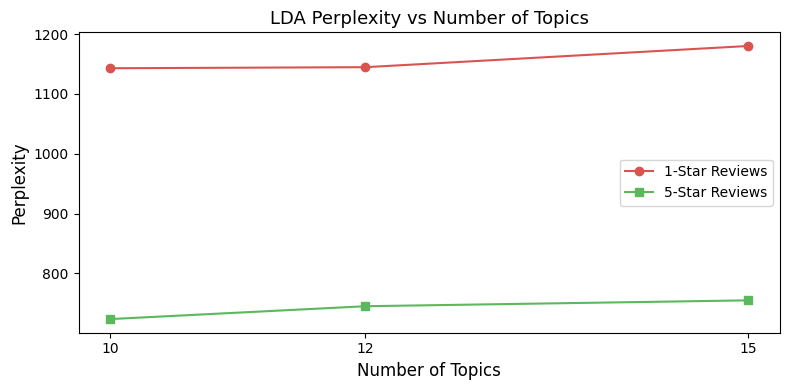


Note: Perplexity is used here as a supporting metric only.
The final topic count is selected based on perplexity AND manual
inspection of topic coherence and distinctness (see cells below).


In [ ]:
# CELL 10: Perplexity comparison (reusing already-fitted models)
# lower perplexity = better fit, but doesn't mean topics are actually readable
# using this alongside manual inspection to pick the final model

topic_options  = [10, 12, 15]
models_1       = [lda_1_10, lda_1_12, lda_1_15]
models_5       = [lda_5_10, lda_5_12, lda_5_15]

perplexity_1 = [m.perplexity(X_1) for m in models_1]
perplexity_5 = [m.perplexity(X_5) for m in models_5]

perp_df = pd.DataFrame({
    "NUM_TOPICS":        topic_options,
    "1-star perplexity": [round(p, 2) for p in perplexity_1],
    "5-star perplexity": [round(p, 2) for p in perplexity_5]
})

print("Perplexity (lower = better statistical fit):")
display(perp_df)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(topic_options, perplexity_1, marker='o', label='1-Star Reviews', color='#d9534f')
ax.plot(topic_options, perplexity_5, marker='s', label='5-Star Reviews', color='#5cb85c')
ax.set_xlabel("Number of Topics", fontsize=12)
ax.set_ylabel("Perplexity",        fontsize=12)
ax.set_title("LDA Perplexity vs Number of Topics", fontsize=13)
ax.set_xticks(topic_options)
ax.legend()
plt.tight_layout()
plt.show()

print("\nNote: Perplexity is used here as a supporting metric only.")
print("The final topic count is selected based on perplexity AND manual")
print("inspection of topic coherence and distinctness (see cells below).")

In [ ]:
# CELL 11: Inspect topics — NUM_TOPICS = 10

print_topics(lda_1_10, vectorizer_1, "1-STAR REVIEW TOPICS  (n=10)", n_words=NUM_WORDS)
print_topics(lda_5_10, vectorizer_5, "5-STAR REVIEW TOPICS  (n=10)", n_words=NUM_WORDS)


1-STAR REVIEW TOPICS  (n=10)
Topic 0: appointment, doctor, minutes, hours, schedule, office, hour, 30, 10, staff, close, open
Topic 1: away, stay, staff, dog, like, school, place, stay away, kid, home, work, people
Topic 2: company, business, send, work, days, order, later, receive, week, phone, email, money
Topic 3: charge, card, company, store, fee, credit, month, truck, location, bank, return, park
Topic 4: hair, money, waste, cut, company, order, case, tow, refund, rude, like, waste money
Topic 5: phone, nail, answer, like, answer phone, service, dress, lady, pick, rude, place, terrible
Topic 6: place, people, work, management, clean, apartment, office, review, rent, break, water, like
Topic 7: car, price, place, buy, drive, truck, fix, shop, vehicle, repair, change, charge
Topic 8: service, customer, customer service, worst, rude, food, bad, like, horrible, people, poor, work
Topic 9: insurance, dr, office, rude, doctor, care, que, staff, dentist, place, worst, experience

5-STAR

In [ ]:
# CELL 12: Inspect topics — NUM_TOPICS = 12

print_topics(lda_1_12, vectorizer_1, "1-STAR REVIEW TOPICS  (n=12)", n_words=NUM_WORDS)
print_topics(lda_5_12, vectorizer_5, "5-STAR REVIEW TOPICS  (n=12)", n_words=NUM_WORDS)


1-STAR REVIEW TOPICS  (n=12)
Topic 0: appointment, minutes, hours, schedule, doctor, hour, 10, 30, close, open, phone, room
Topic 1: answer, school, staff, away, phone, like, stay, place, glass, kid, rude, work
Topic 2: company, business, work, days, send, later, home, weeks, week, receive, email, phone
Topic 3: card, charge, store, credit, park, bank, account, fee, money, return, manager, company
Topic 4: order, money, company, package, send, deliver, refund, receive, email, office, mail, contact
Topic 5: location, phone, pick, truck, tire, fix, dont, driver, star, like, drive, slow
Topic 6: place, people, money, review, don, work, star, like, better, good, job, scam
Topic 7: car, price, drive, place, shop, buy, door, truck, guy, vehicle, charge, change
Topic 8: service, customer, customer service, rude, worst, horrible, poor, bad, people, like, customers, experience
Topic 9: office, doctor, dr, insurance, care, rude, staff, like, pain, patients, experience, dentist
Topic 10: food, n

In [ ]:
# CELL 13: Inspect topics — NUM_TOPICS = 15

print_topics(lda_1_15, vectorizer_1, "1-STAR REVIEW TOPICS  (n=15)", n_words=NUM_WORDS)
print_topics(lda_5_15, vectorizer_5, "5-STAR REVIEW TOPICS  (n=15)", n_words=NUM_WORDS)


1-STAR REVIEW TOPICS  (n=15)
Topic 0: appointment, minutes, hours, hour, schedule, 30, doctor, 10, close, open, walk, staff
Topic 1: staff, school, away, stay, like, avoid, stay away, place, class, cost, kid, people
Topic 2: business, company, days, send, email, receive, week, later, work, number, review, phone
Topic 3: charge, card, store, truck, credit, park, bank, company, package, account, fee, location
Topic 4: money, company, waste, refund, order, send, buy, waste money, case, work, tow, business
Topic 5: phone, hair, answer, lady, like, rude, answer phone, pick, close, tire, salon, help
Topic 6: place, people, work, don, star, horrible, like, rude, worst, care, office, better
Topic 7: car, price, fix, buy, drive, repair, work, away, truck, place, charge, shop
Topic 8: service, customer, customer service, worst, rude, horrible, bad, terrible, poor, manager, work, like
Topic 9: doctor, office, dr, care, insurance, staff, rude, patients, medical, like, pain, treat
Topic 10: nail, 

## Model Selection

Compared n = 10, 12, and 15 on perplexity and manual topic inspection.

n=10 gave perplexity of 1142.8 (1-star) and 723.6 (5-star), n=12 gave 1144.6 and 745.1, n=15 gave 1180.0 and 754.9.

n=10 had the lowest perplexity and the topics were cleanest on inspection. At n=12 and n=15 some topics started splitting into near-duplicates (e.g. two very similar customer service topics) which didn't add anything useful.

**Final model: `CHOSEN_N = 10`**


In [ ]:
# CELL 14: Select final model

CHOSEN_N = 10

model_map = {
    10: (lda_1_10, lda_5_10),
    12: (lda_1_12, lda_5_12),
    15: (lda_1_15, lda_5_15),
}

lda_1_final, lda_5_final = model_map[CHOSEN_N]

df_1_final = assign_dominant_topic(lda_1_final, X_1, df_1_sample)
df_5_final = assign_dominant_topic(lda_5_final, X_5, df_5_sample)

summary_1 = make_topic_summary(df_1_final)
summary_5 = make_topic_summary(df_5_final)

print(f"Final model selected: NUM_TOPICS = {CHOSEN_N}")
print("\nBased on perplexity and manual inspection of topic coherence,")
print("the most interpretable topic count has been selected for final analysis.")

Final model selected: NUM_TOPICS = 10

Based on perplexity and manual inspection of topic coherence,
the most interpretable topic count has been selected for final analysis.


In [ ]:
# CELL 15: Topic word tables for final model

topics_1_df = get_topic_words(lda_1_final, vectorizer_1, n_words=NUM_WORDS)
topics_5_df = get_topic_words(lda_5_final, vectorizer_5, n_words=NUM_WORDS)

print(f"\n--- 1-Star Topics (n={CHOSEN_N}) ---")
display(topics_1_df)

print(f"\n--- 5-Star Topics (n={CHOSEN_N}) ---")
display(topics_5_df)


--- 1-Star Topics (n=10) ---


,Topic,Top Words
0,Topic 0,"appointment, doctor, minutes, hours, schedule,..."
1,Topic 1,"away, stay, staff, dog, like, school, place, s..."
2,Topic 2,"company, business, send, work, days, order, la..."
3,Topic 3,"charge, card, company, store, fee, credit, mon..."
4,Topic 4,"hair, money, waste, cut, company, order, case,..."
5,Topic 5,"phone, nail, answer, like, answer phone, servi..."
6,Topic 6,"place, people, work, management, clean, apartm..."
7,Topic 7,"car, price, place, buy, drive, truck, fix, sho..."
8,Topic 8,"service, customer, customer service, worst, ru..."
9,Topic 9,"insurance, dr, office, rude, doctor, care, que..."



--- 5-Star Topics (n=10) ---


,Topic,Top Words
0,Topic 0,"nice, friendly, helpful, question, knowledgeab..."
1,Topic 1,"staff, care, friendly, best, dr, office, love,..."
2,Topic 2,"work, company, professional, recommend, home, ..."
3,Topic 3,"service, great, customer, customer service, gr..."
4,Topic 4,"dr, visit, years, doctor, pain, office, staff,..."
5,Topic 5,"great, job, price, work, great job, experience..."
6,Topic 6,"work, guy, thank, store, help, good, great, be..."
7,Topic 7,"place, great, love, good, best, nice, food, aw..."
8,Topic 8,"recommend, highly, highly recommend, amaze, ha..."
9,Topic 9,"friendly, good, service, thank, great, best, p..."


In [ ]:
# CELL 16: Human-readable topic labels
# assigned by looking at the top words and a few example reviews for each topic

# 1-STAR topic word summaries for reference:
# Topic 0: appointment, doctor, minutes, hours, schedule, office
# Topic 1: away, stay, staff, dog, school, place
# Topic 2: company, business, send, work, days, order
# Topic 3: charge, card, company, store, fee, credit
# Topic 4: hair, money, waste, cut, company, order
# Topic 5: phone, nail, answer, service, dress, lady
# Topic 6: place, people, work, management, clean, apartment
# Topic 7: car, price, drive, truck, fix, shop
# Topic 8: service, customer, worst, rude, food, bad
# Topic 9: insurance, dr, office, rude, doctor, care

topic_labels_1 = {
    0: "Appointment & Wait Time Failures",
    1: "Staff Dismissiveness & General Avoidance",
    2: "Unresponsive Businesses & Delayed Orders",
    3: "Unexpected Charges & Billing Disputes",
    4: "Wasted Money & Refused Refunds",
    5: "Unanswered Phones & Rude Front Desk",
    6: "Property Management & Rental Complaints",
    7: "Auto Repair Overcharging & Poor Workmanship",
    8: "Worst Customer Service & Rude Staff",
    9: "Negative Healthcare & Dental Experiences",
}

# 5-STAR topic word summaries for reference:
# Topic 0: nice, friendly, helpful, question, knowledgeable
# Topic 1: staff, care, friendly, best, dr, office
# Topic 2: work, company, professional, recommend, home
# Topic 3: service, great, customer, excellent, price
# Topic 4: dr, visit, years, doctor, pain, office
# Topic 5: great, job, price, reasonable, recommend
# Topic 6: work, guy, thank, store, help, good
# Topic 7: place, great, love, good, best, food
# Topic 8: recommend, highly, amaze, hair, service
# Topic 9: friendly, good, service, thank, clean, family

topic_labels_5 = {
    0: "Knowledgeable & Responsive Professionals",
    1: "Caring & Friendly Staff (Medical / Pet Care)",
    2: "Reliable Home-Service & Repair Companies",
    3: "Excellent Customer Service & Great Value",
    4: "Positive Healthcare & Dental Visits",
    5: "Quality Work at Reasonable Prices",
    6: "Helpful Store Staff & Tradespeople",
    7: "Great Venues — Food, Schools & Activities",
    8: "Strong Personal Recommendations (Hair/Beauty)",
    9: "Clean, Family-Friendly All-Round Experience",
}

print(f"Topic labels defined for n=10.")
print("\n1-star labels:")
for k, v in topic_labels_1.items():
    print(f"  Topic {k}: {v}")
print("\n5-star labels:")
for k, v in topic_labels_5.items():
    print(f"  Topic {k}: {v}")


Topic labels defined for n=10.

1-star labels:
  Topic 0: Appointment & Wait Time Failures
  Topic 1: Staff Dismissiveness & General Avoidance
  Topic 2: Unresponsive Businesses & Delayed Orders
  Topic 3: Unexpected Charges & Billing Disputes
  Topic 4: Wasted Money & Refused Refunds
  Topic 5: Unanswered Phones & Rude Front Desk
  Topic 6: Property Management & Rental Complaints
  Topic 7: Auto Repair Overcharging & Poor Workmanship
  Topic 8: Worst Customer Service & Rude Staff
  Topic 9: Negative Healthcare & Dental Experiences

5-star labels:
  Topic 0: Knowledgeable & Responsive Professionals
  Topic 1: Caring & Friendly Staff (Medical / Pet Care)
  Topic 2: Reliable Home-Service & Repair Companies
  Topic 3: Excellent Customer Service & Great Value
  Topic 4: Positive Healthcare & Dental Visits
  Topic 5: Quality Work at Reasonable Prices
  Topic 6: Helpful Store Staff & Tradespeople
  Topic 7: Great Venues — Food, Schools & Activities
  Topic 8: Strong Personal Recommendations 

In [ ]:
# CELL 17: Example reviews per topic (use these to verify / update labels)

def show_examples(df_with_topics, labels_dict, rating_label, n_topics, n_per_topic=2):
    print("\n" + "=" * 80)
    print(f"EXAMPLE REVIEWS PER TOPIC — {rating_label}")
    print("=" * 80)
    for t in range(n_topics):
        label  = labels_dict.get(t, f"Topic {t}")
        subset = df_with_topics[df_with_topics["dominant_topic"] == t][
            ["processed_text"]
        ].head(n_per_topic)
        print(f"\n[Topic {t} | {label}]")
        for i, text in enumerate(subset["processed_text"], 1):
            print(f"  {i}. {text[:260]}...")


show_examples(df_1_final, topic_labels_1, "1-STAR REVIEWS", CHOSEN_N)
show_examples(df_5_final, topic_labels_5, "5-STAR REVIEWS", CHOSEN_N)


EXAMPLE REVIEWS PER TOPIC — 1-STAR REVIEWS

[Topic 0 | Appointment & Wait Time Failures]
  1. do not book online make 12 o clock appointment drive 30 minutes to get there the guy a no show...
  2. i show up in a group of 14 on motorcycle we stop right at the front of the entrance and follow a golf cart up to the office the lady run the place refuse to open up the office for us to check in she assume we would be party and disrespectful because we be bike...

[Topic 1 | Staff Dismissiveness & General Avoidance]
  1. go in for chest and arm pain say nothing be wrong do n't even do xrays go somewhere else they find pinch nerve law suit on ingalls urgent care...
  2. i be sad to report that i will no longer recommend them when we have our dog we be always treat fairly and never felt like the only interest be to pull cash out of our pocket in fact 10 years ago the doctor ca n't remember name bring back our ash with a frame ...

[Topic 2 | Unresponsive Businesses & Delayed Orders]
  1. i giv

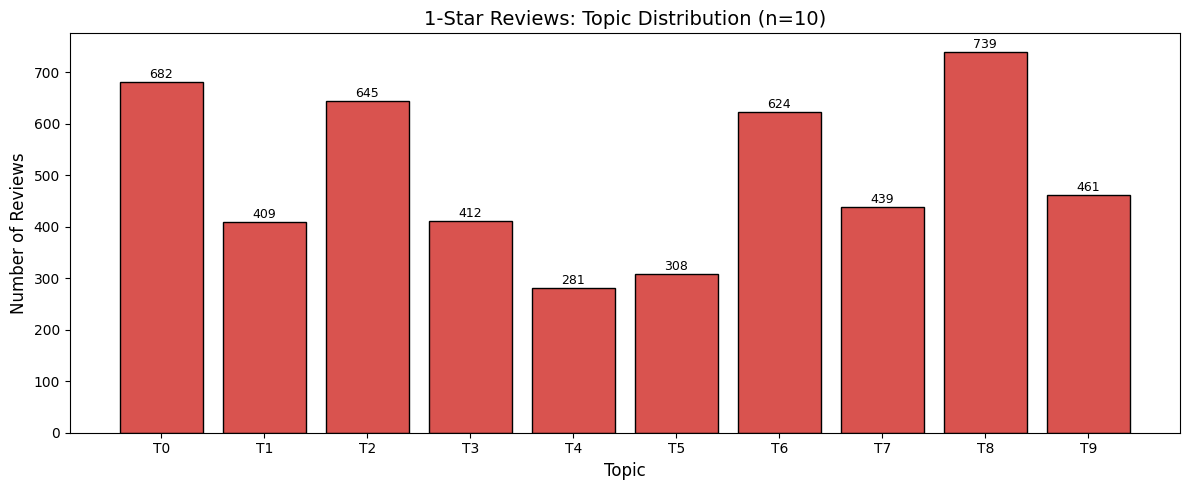

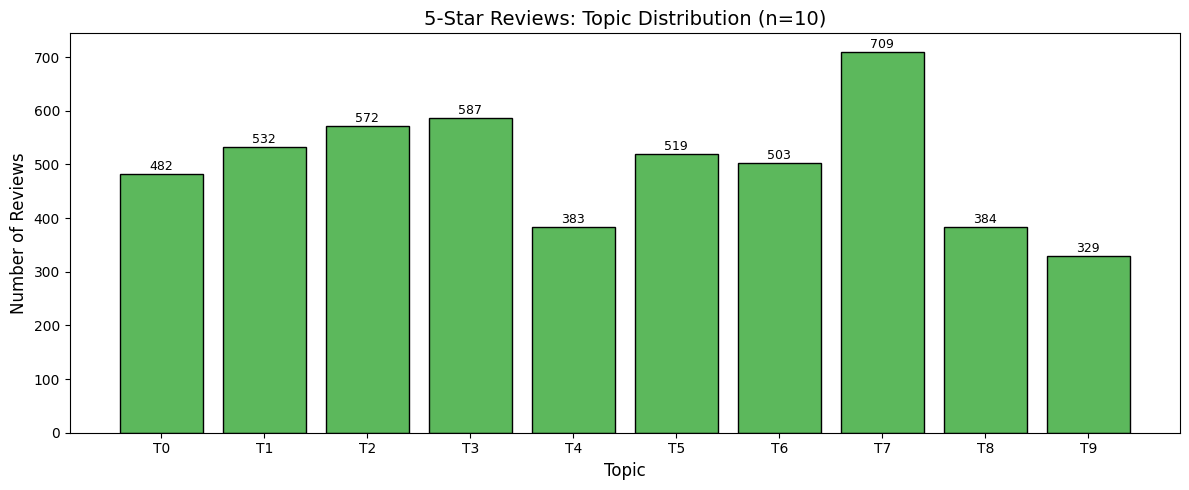

In [ ]:
# CELL 18: Topic distribution plots — final model

plot_topic_distribution(
    summary_1,
    f"1-Star Reviews: Topic Distribution (n={CHOSEN_N})",
    color='#d9534f'
)

plot_topic_distribution(
    summary_5,
    f"5-Star Reviews: Topic Distribution (n={CHOSEN_N})",
    color='#5cb85c'
)

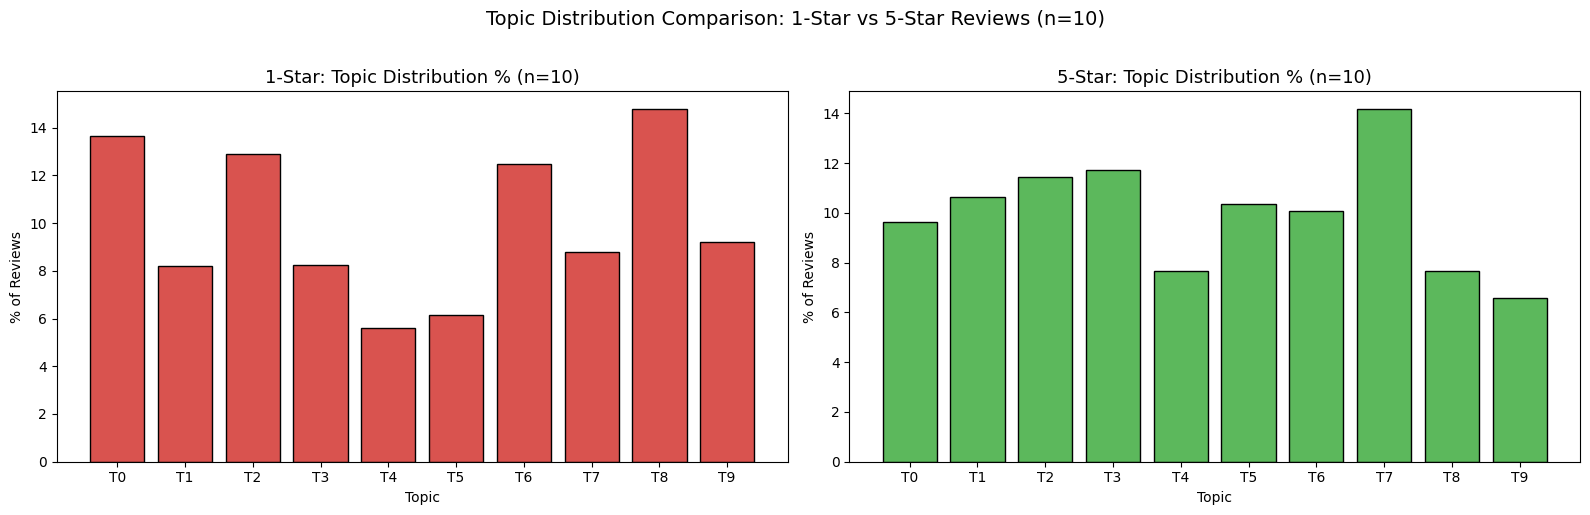

In [ ]:
# CELL 19: Side-by-side percentage comparison

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(
    [f"T{t}" for t in summary_1["Topic"]],
    summary_1["Percent"],
    color='#d9534f', edgecolor='black'
)
axes[0].set_title(f"1-Star: Topic Distribution % (n={CHOSEN_N})", fontsize=13)
axes[0].set_xlabel("Topic")
axes[0].set_ylabel("% of Reviews")

axes[1].bar(
    [f"T{t}" for t in summary_5["Topic"]],
    summary_5["Percent"],
    color='#5cb85c', edgecolor='black'
)
axes[1].set_title(f"5-Star: Topic Distribution % (n={CHOSEN_N})", fontsize=13)
axes[1].set_xlabel("Topic")
axes[1].set_ylabel("% of Reviews")

plt.suptitle(
    f"Topic Distribution Comparison: 1-Star vs 5-Star Reviews (n={CHOSEN_N})",
    fontsize=14, y=1.02
)
plt.tight_layout()
plt.show()

### Alternative Topic Modelling: NMF

To cross-check the LDA results, NMF is applied to both the 1-star and 5-star subsets.

LDA uses probability distributions which works well for grouping nouns and broad themes. NMF works on a TF-IDF matrix instead — because TF-IDF down-weights very common words, NMF tends to pull out more specific phrases, sentiment-driven terms and behavioral patterns.

Comparing the two helps look at not just where extreme experiences happen, but how customers actually describe them.

In [ ]:
# CELL 20: TF-IDF + NMF for 1-star & 5-star
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

# Define the reusable function to print top words
def display_topicsnmf(model, feature_names, no_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print(f"Topic {topic_idx}:")
        print(" ".join([feature_names[i] for i in topic.argsort()[:-no_top_words - 1:-1]]))
        print("-" * 50)

# NMF on 5 Star reviews
print("--- Running NMF on 5-Star Reviews ---")

# Initialize TF-IDF vectorizer for 5-star vocabulary
tfidf_vectorizer_5star = TfidfVectorizer(max_df=0.90, min_df=5, stop_words='english', ngram_range=(1, 2))


tfidf_5star = tfidf_vectorizer_5star.fit_transform(df_5['processed_text'])

# Initialize and fit NMF (using 10 topics)
nmf_model_5star = NMF(n_components=10, random_state=42, init='nndsvda')
nmf_model_5star.fit(tfidf_5star)

# Display the NMF topics for 5-star
print("\nTop words per topic for 5-Star Reviews (NMF):")
nmf_feature_names_5star = tfidf_vectorizer_5star.get_feature_names_out()
display_topicsnmf(nmf_model_5star, nmf_feature_names_5star, 10)


# NMF on 1 star reviews
print("\n\n--- Running NMF on 1-Star Reviews ---")

# Initialize a new TF-IDF vectorizer specifically for the 1-star vocabulary
tfidf_vectorizer_1star = TfidfVectorizer(max_df=0.90, min_df=5, stop_words='english', ngram_range=(1, 2))


tfidf_1star = tfidf_vectorizer_1star.fit_transform(df_1['processed_text'])

# Initialize and fit NMF for 1-star reviews (using 10 topics)
nmf_model_1star = NMF(n_components=10, random_state=42, init='nndsvda')
nmf_model_1star.fit(tfidf_1star)

# Display the NMF topics for 1-star
print("\nTop words per topic for 1-Star Reviews (NMF):")
nmf_feature_names_1star = tfidf_vectorizer_1star.get_feature_names_out()
display_topicsnmf(nmf_model_1star, nmf_feature_names_1star, 10)

--- Running NMF on 5-Star Reviews ---

Top words per topic for 5-Star Reviews (NMF):
Topic 0:
work time thank help make need come job look use
--------------------------------------------------
Topic 1:
service customer customer service excellent great customer excellent service great service excellent customer fast service great
--------------------------------------------------
Topic 2:
great great service great job great experience great people job great price people price experience
--------------------------------------------------
Topic 3:
place great place nice love place nice place best place place great recommend place people clean
--------------------------------------------------
Topic 4:
friendly staff helpful friendly staff staff friendly friendly helpful professional super clean knowledgeable
--------------------------------------------------
Topic 5:
best best place ve town best price shop best service price best best area
------------------------------------------------

In [ ]:
# CELL 21: pyLDAvis visualization code
!pip install pyLDAvis
import pyLDAvis
import pyLDAvis.lda_model
pyLDAvis.enable_notebook()

print("Generating Interactive LDA Visualization for 1-Star Reviews...")
vis_1star = pyLDAvis.lda_model.prepare(lda_1_final, X_1, vectorizer_1, mds='tsne')
display(vis_1star)

print("Generating Interactive LDA Visualization for 5-Star Reviews...")
vis_5star = pyLDAvis.lda_model.prepare(lda_5_final, X_5, vectorizer_5, mds='tsne')
display(vis_5star)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 49.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 76.2 MB/s eta 0:00:00
Generating Interactive LDA Visualization for 1-Star Reviews...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

PreparedData(topic_coordinates=               x          y  topics  cluster       Freq
topic                                                  
2     -24.768858  -6.511072       1        1  15.818982
6      -9.034197   9.368500       2        1  14.034471
0      11.777571  11.364815       3        1  13.916837
8      19.377159 -21.931068       4        1  10.556769
3       3.055777  -7.691221       5        1   9.376648
7      30.824284   0.189046       6        1   9.119400
1      -1.518300  32.036461       7        1   8.750894
9      24.708492  28.236570       8        1   8.437863
4      -8.849757 -25.730452       9        1   5.183318
5     -26.385880  21.596678      10        1   4.804818, topic_info=                  Term         Freq        Total Category  logprob  loglift
1704           service  1365.000000  1365.000000  Default  30.0000  30.0000
508           customer   721.000000   721.000000  Default  29.0000  29.0000
340                car   559.000000   559.000000  Default  28.0000  28.0000
509   customer service   526.000000   526.000000  Default  27.0000  27.0000
162        appointment   535.000000   535.000000  Default  26.0000  26.0000
...                ...          ...          ...      ...      ...      ...
564               didn    34.465775   230.708775  Topic10  -5.1593   1.1344
1814              star    37.585652   398.843099  Topic10  -5.0727   0.6736
2127              work    41.607411  1040.974946  Topic10  -4.9710  -0.1841
1738              shop    32.609141   212.452528  Topic10  -5.2147   1.1614
696         experience    35.136029   501.056232  Topic10  -5.1401   0.3781

[665 rows x 6 columns], token_table=      Topic      Freq        Term
term                             
0         1  0.335418          00
0         2  0.005590          00
0         3  0.145348          00
0         5  0.324238          00
0         6  0.078264          00
...     ...       ...         ...
2160      8  0.057795       years
2160      9  0.122012       years
2160     10  0.006422       years
2169      5  0.084226  young lady
2169     10  0.842259  young lady

[1933 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[3, 7, 1, 9, 4, 8, 2, 10, 5, 6])

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Generating Interactive LDA Visualization for 5-Star Reviews...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

PreparedData(topic_coordinates=                x           y  topics  cluster       Freq
topic                                                    
2       19.119364  -30.607447       1        1  14.950537
1       62.885197  -89.565071       2        1  11.003679
6       99.286758  -19.221895       3        1  10.866293
7       59.005527   39.777149       4        1  10.449693
3      -59.409161  -48.022240       5        1   9.706413
0      -15.009419 -104.090347       6        1   9.668301
5      -63.650818   80.795403       7        1   9.331952
4     -100.452866   10.524522       8        1   9.152178
8      -19.823635   22.017773       9        1   8.108383
9       14.227900   95.477219      10        1   6.762570, topic_info=                  Term         Freq        Total Category  logprob  loglift
1162           service  1184.000000  1184.000000  Default  30.0000  30.0000
934              place   654.000000   654.000000  Default  29.0000  29.0000
620             highly   652.000000   652.000000  Default  28.0000  28.0000
621   highly recommend   595.000000   595.000000  Default  27.0000  27.0000
347                 dr   618.000000   618.000000  Default  26.0000  26.0000
...                ...          ...          ...      ...      ...      ...
1065         recommend    41.137309  1129.803343  Topic10  -4.7366  -0.6191
229        comfortable    28.099704   156.118391  Topic10  -5.1178   0.9789
1384                ve    32.198737   379.114982  Topic10  -4.9816   0.2279
1283             super    27.762866   248.868915  Topic10  -5.1299   0.5005
731               like    28.156404   355.998113  Topic10  -5.1158   0.1566

[647 rows x 6 columns], token_table=      Topic      Freq         Term
term                              
0         2  0.028731           10
0         3  0.105348           10
0         4  0.105348           10
0         5  0.028731           10
0         6  0.181965           10
...     ...       ...          ...
1458      8  0.332910        years
1458      9  0.153845        years
1458     10  0.007566        years
1461      5  0.072071  years great
1461      8  0.864858  years great

[1488 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[3, 2, 7, 8, 4, 1, 6, 5, 9, 10])

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# CELL 22: Save outputs

topics_1_df.to_csv(f"topics_1star_n{CHOSEN_N}.csv", index=False)
topics_5_df.to_csv(f"topics_5star_n{CHOSEN_N}.csv", index=False)
df_1_final.to_csv(f"reviews_1star_with_topics_n{CHOSEN_N}.csv", index=False)
df_5_final.to_csv(f"reviews_5star_with_topics_n{CHOSEN_N}.csv", index=False)

print("Saved:")
print(f"  topics_1star_n{CHOSEN_N}.csv")
print(f"  topics_5star_n{CHOSEN_N}.csv")
print(f"  reviews_1star_with_topics_n{CHOSEN_N}.csv")
print(f"  reviews_5star_with_topics_n{CHOSEN_N}.csv")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Saved:
  topics_1star_n10.csv
  topics_5star_n10.csv
  reviews_1star_with_topics_n10.csv
  reviews_5star_with_topics_n10.csv


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag